# FluxTransformer Reservoir Experiments on E. coli iML1515

This notebook evaluates a pretrained FluxTransformer model on E. coli iML1515 metabolism and adapts it for MINN-style experimental omics-to-flux benchmarking.

The first sections load the pretrained FluxTransformer and inspect its behavior with loss curves, diagnostic flux plots, flux-distribution checks, and flux-level metrics. The later sections train a front MLP on experimental transcriptomics, proteomics, and glucose/oxygen uptake inputs, then use the frozen FluxTransformer as a reservoir for MINN-style flux prediction.

The current experimental comparison focuses on a Tazza et al. Table 4-style pFBA workflow adapted to iML1515. It reports baseline pFBA, FluxTransformer-to-pFBA variants with measured versus predicted glucose/O2 reservoir context, CO2/ethanol/acetate versus ethanol/acetate secretion-cap modes, and per-sample cap-binding diagnostics for difficult samples. The notebook no longer runs the former Table 2-style TabPFN or Goncalves/ML2Flux benchmark sections.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()
hf_token = os.getenv("HFTOKEN")

In [2]:
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from openTSNE import TSNEEmbedding, affinity, initialization

from train_flux_transformer import load_data, prepare_tensors, set_seed

%matplotlib inline
pd.set_option('display.max_rows', None)

In [3]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=128, n_heads=8, dropout=0.05):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [4]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.05):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [5]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=128, n_heads=8, d_ff=1024, dropout=0.05):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c
        
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        input_token_indices,          # list[int] or 1D tensor[int64]
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.05,
    ):
        super().__init__()
        if vocab_size is None:
            raise ValueError("vocab_size must be provided explicitly.")
        self.vocab_size = int(vocab_size)
        self.d_model = d_model

        idx = torch.as_tensor(input_token_indices, dtype=torch.long)
        if idx.ndim != 1:
            raise ValueError("input_token_indices must be 1D.")
        if (idx < 0).any() or (idx >= self.vocab_size).any():
            raise ValueError("input_token_indices contains out-of-range indices.")
        # Register as buffer so it moves with .to(device)
        self.register_buffer("input_token_indices", idx, persistent=True)

        self.input_embedding = nn.Embedding(self.vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        c: (batch, vocab_size, 1)
        output_subset: 1D tensor of token indices to train on (typically excludes injected tokens)
        """
        batch_size = c.size(0)

        always = self.input_token_indices  # (n_injected,)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            output_subset = output_subset.to(c.device).long()
            selected_indices = torch.unique(torch.cat([always, output_subset]), sorted=True)

        y = selected_indices.unsqueeze(0).expand(batch_size, -1)      # (B, S)
        x = self.input_embedding(y)                                    # (B, S, d_model)

        c_subset = c[:, selected_indices, :]                           # (B, S, 1)
        c_subset_all_layers = torch.zeros(batch_size, c_subset.size(1), len(self.layers), device=c.device)

        for e, layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices

        return c_subset_all_layers, selected_indices

In [6]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        input_token_indices=config['input_token_indices'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [7]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    import os
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    train_epochs = np.arange(1, len(train_losses) + 1)
    test_epochs = np.arange(1, len(test_losses) + 1)
    plt.plot(train_epochs, train_losses, label="Training Loss")
    plt.plot(test_epochs, test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path)
        plt.show()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [8]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    import os
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred
    display_label = str(label)
    if display_label.endswith('_flux'):
        display_label = display_label[:-5]
    if display_label.upper().startswith('BIOMASS'):
        display_label = 'Biomass iML1515'

    title_fs = 15
    label_fs = 13
    tick_fs = 11

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {display_label}', fontsize=title_fs)
    axs[0, 0].set_xlabel('True value', fontsize=label_fs)
    axs[0, 0].set_ylabel('Predicted', fontsize=label_fs)
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {display_label}', fontsize=title_fs)
    axs[0, 1].set_xlabel('True value', fontsize=label_fs)
    axs[0, 1].set_ylabel('Residuals', fontsize=label_fs)
    if str(label).upper().startswith('BIOMASS'):
        axs[0, 1].set_ylim(-0.05, 0.05)
    else:
        res_abs_max = float(np.nanmax(np.abs(residuals))) if residuals.size else 1.0
        if (not np.isfinite(res_abs_max)) or (res_abs_max == 0.0):
            res_abs_max = 1.0
        axs[0, 1].set_ylim(-res_abs_max, res_abs_max)
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {display_label}', fontsize=title_fs)
    axs[1, 0].set_xlabel('Prediction Error', fontsize=label_fs)
    axs[1, 0].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {display_label}', fontsize=title_fs)
    axs[1, 1].set_xlabel('True Value', fontsize=label_fs)
    axs[1, 1].set_ylabel('Frequency', fontsize=label_fs)
    axs[1, 1].grid(True)

    for ax in axs.ravel():
        ax.tick_params(labelsize=tick_fs)

    plt.tight_layout()
    if save_path:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.show()
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

In [9]:
def plot_flux(
    model,
    X_test,
    y_test,
    outputs,
    flux_name: str,
    save_path=None,
    batch_size: int = 16,
    device: str | torch.device | None = None,
):
    """
    Plot diagnostics for a token name in `outputs`.

    Assumptions:
      - outputs defines token order, len(outputs) == model.vocab_size
      - X_test is (N, vocab_size) and contains medium constraints only at injected token indices
      - y_test is (N, vocab_size) and contains realized fluxes for all tokens
      - model forward returns (preds_all_layers, selected_indices)
        where preds_all_layers is (B, S, n_layers) and selected_indices are token indices
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)

    model = model.to(device).eval()

    # Basic sanity checks
    if len(outputs) != getattr(model, "vocab_size", None):
        raise ValueError(f"len(outputs)={len(outputs)} does not match model.vocab_size={model.vocab_size}")

    if X_test.ndim != 2 or y_test.ndim != 2:
        raise ValueError(f"Expected X_test and y_test as 2D tensors (N, vocab_size). Got {X_test.shape=}, {y_test.shape=}")

    if X_test.shape[1] != model.vocab_size or y_test.shape[1] != model.vocab_size:
        raise ValueError(
            f"Feature dim mismatch. Expected vocab_size={model.vocab_size}. "
            f"Got X_test.shape[1]={X_test.shape[1]}, y_test.shape[1]={y_test.shape[1]}"
        )

    if flux_name not in outputs:
        raise ValueError(f"Flux '{flux_name}' not in outputs (len={len(outputs)}).")

    token_idx = outputs.index(flux_name)

    pred_vals = []
    true_vals = []
    pos = None
    use_amp = device.type == "cuda"

    # Diagnostics use full-context forward (output_subset=None), which can be memory-heavy on CUDA.
    # Use a conservative default batch size on GPU unless user explicitly asks for <=2.
    if device.type == "cuda" and batch_size > 2:
        batch_size = 2

    with torch.inference_mode():
        for i in range(0, X_test.shape[0], batch_size):
            xb = X_test[i:i + batch_size].to(device)          # [B, vocab_size]
            yb_true = y_test[i:i + batch_size]                # [B, vocab_size]
            c = xb.unsqueeze(-1)                              # [B, vocab_size, 1]

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    preds_all_layers, selected_indices = model(c, output_subset=None)
            else:
                preds_all_layers, selected_indices = model(c, output_subset=None)

            # Map token_idx -> its position inside selected_indices (once is enough)
            if pos is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                hit = np.where(selected_indices_np == token_idx)[0]
                if hit.size == 0:
                    raise RuntimeError(
                        f"Token index {token_idx} for '{flux_name}' was not produced by the model forward pass. "
                        "This should not happen when output_subset=None."
                    )
                pos = int(hit[0])

            yb_pred_flux = preds_all_layers[:, pos, -1].detach().cpu().numpy()
            yb_true_flux = yb_true[:, token_idx].detach().cpu().numpy()

            pred_vals.append(yb_pred_flux)
            true_vals.append(yb_true_flux)

            if device.type == "cuda":
                torch.cuda.empty_cache()

    y_pred = np.concatenate(pred_vals, axis=0)
    y_true = np.concatenate(true_vals, axis=0)

    # Is this an injected (medium constraint) token slot?
    injected = False
    if hasattr(model, "input_token_indices") and model.input_token_indices is not None:
        injected = bool((model.input_token_indices.detach().cpu() == token_idx).any().item())

    print(f"{flux_name} token index: {token_idx}")
    print(f"injected medium slot: {injected}")
    print("y_true range:", float(y_true.min()), "to", float(y_true.max()))
    print("y_pred range:", float(y_pred.min()), "to", float(y_pred.max()))

    # Per-flux metrics for the currently plotted token
    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = float("nan")
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    print(f"R2: {r2:.4f}")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")

    plot_diagnostics_2x2(
        y_true=y_true,
        y_pred=y_pred,
        label=flux_name,
        save_path=save_path
    )

### Load model

In [10]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [11]:
#model_name = "iML1515_MINN_uni_500k_d256_h8_l3_ff1024"
model_name = "iML1515_MINN_res_500k_d256_h8_l3_ff1024"
#model_name = "iML1515_MINN_log_500k_d256_h8_l3_ff1024"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/iML1515_MINN_res_500k_d256_h8_l3_ff1024/iML1515_MINN_res_500k_d256_h8_l3_ff1024_checkpoint.pth
Configuration: d_model=256, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 3,069,729

Data information:
Dataset: ./data/iML1515_MINN_res_training_data_500k_samples.csv
Training samples: 400000
Test samples: 100000


### Load data

In [12]:
# Load data using the same function as during training
#set_seed()

#DATA_PATH = f"./data/iML1515_MINN_test_data_uni_50000_samples.csv"
#DATA_PATH = f"./data/iML1515_MINN_test_data_log_50000_samples.csv"
DATA_PATH = f"./data/iML1515_MINN_res_test_data_50000_samples.csv"

#X, y, inputs, outputs, input_token_indices, out_indices = load_data(data_info['dataset'])
X, y, inputs, outputs, input_token_indices, out_indices = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)

model.eval()


Loaded data with 50000 samples from ./data/iML1515_MINN_res_test_data_50000_samples.csv
Extracted input columns count:  27
Extracted output columns count: 2712
Medium constraints are injected into these token indices (in outputs order):
[180, 1525, 106, 40, 45, 92, 104, 164, 304, 621, 700, 859, 913, 970, 1424, 1478, 1485, 1500, 1534, 1535, 1836, 1981, 86, 934, 2243, 2320, 633]
Training samples: 40000
Test samples: 10000


FluxTransformer(
  (input_embedding): Embedding(2712, 256)
  (layers): ModuleList(
    (0-2): 3 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((257,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=257, out_features=1024, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=1024, out_features=257, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

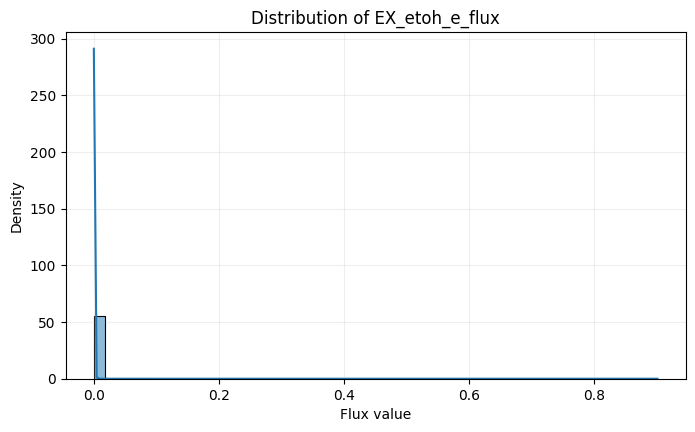

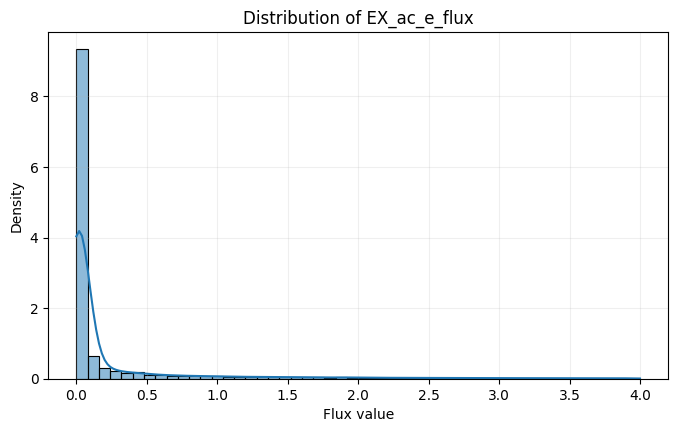

In [13]:
def plot_flux_distribution(y, outputs, flux_name, bins=50, figsize=(8, 4.5)):
    """Plot the distribution of a selected output flux from target tensor y."""
    if flux_name not in outputs:
        raise ValueError(f"{flux_name} not found in outputs.")
    flux_idx = outputs.index(flux_name)
    flux_values = y[:, flux_idx]
    if isinstance(flux_values, torch.Tensor):
        flux_values = flux_values.detach().cpu().numpy()
    else:
        flux_values = np.asarray(flux_values)

    plt.figure(figsize=figsize)
    sns.histplot(flux_values, bins=bins, kde=True, stat="density", color="tab:blue")
    plt.title(f"Distribution of {flux_name}")
    plt.xlabel("Flux value")
    plt.ylabel("Density")
    plt.grid(alpha=0.2)
    plt.show()

#plot_flux_distribution(y, outputs, "BIOMASS_Ec_iML1515_core_75p37M_flux")
plot_flux_distribution(y, outputs, "EX_etoh_e_flux")
plot_flux_distribution(y, outputs, "EX_ac_e_flux")

### Plot Results

In [14]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

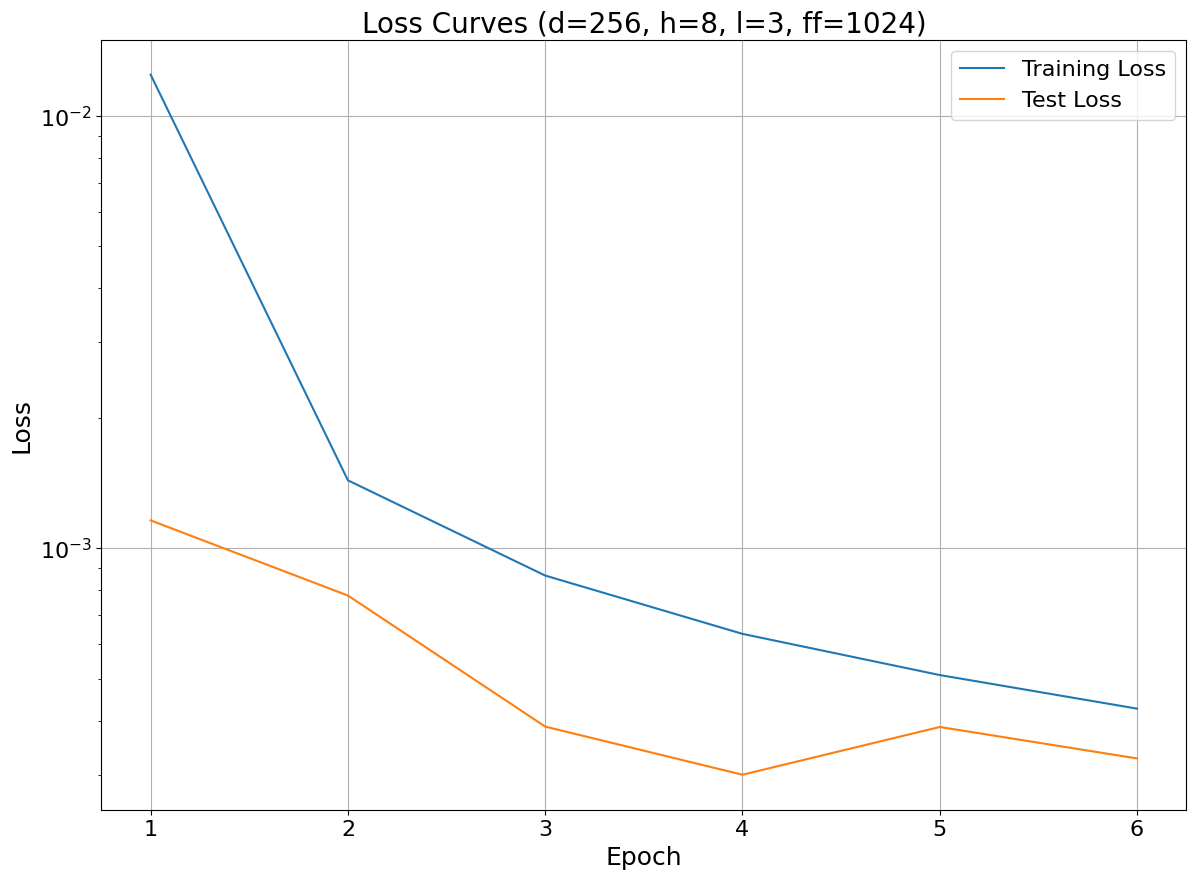

In [15]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

BIOMASS_Ec_iML1515_WT_75p37M_flux:
------------------------------------------------------------
BIOMASS_Ec_iML1515_WT_75p37M_flux token index: 2669
injected medium slot: False
y_true range: 0.0003747593145817518 to 1.2226386070251465
y_pred range: 0.01294785737991333 to 1.2110652923583984
R2: 0.9988
MAE: 0.007555
RMSE: 0.009081


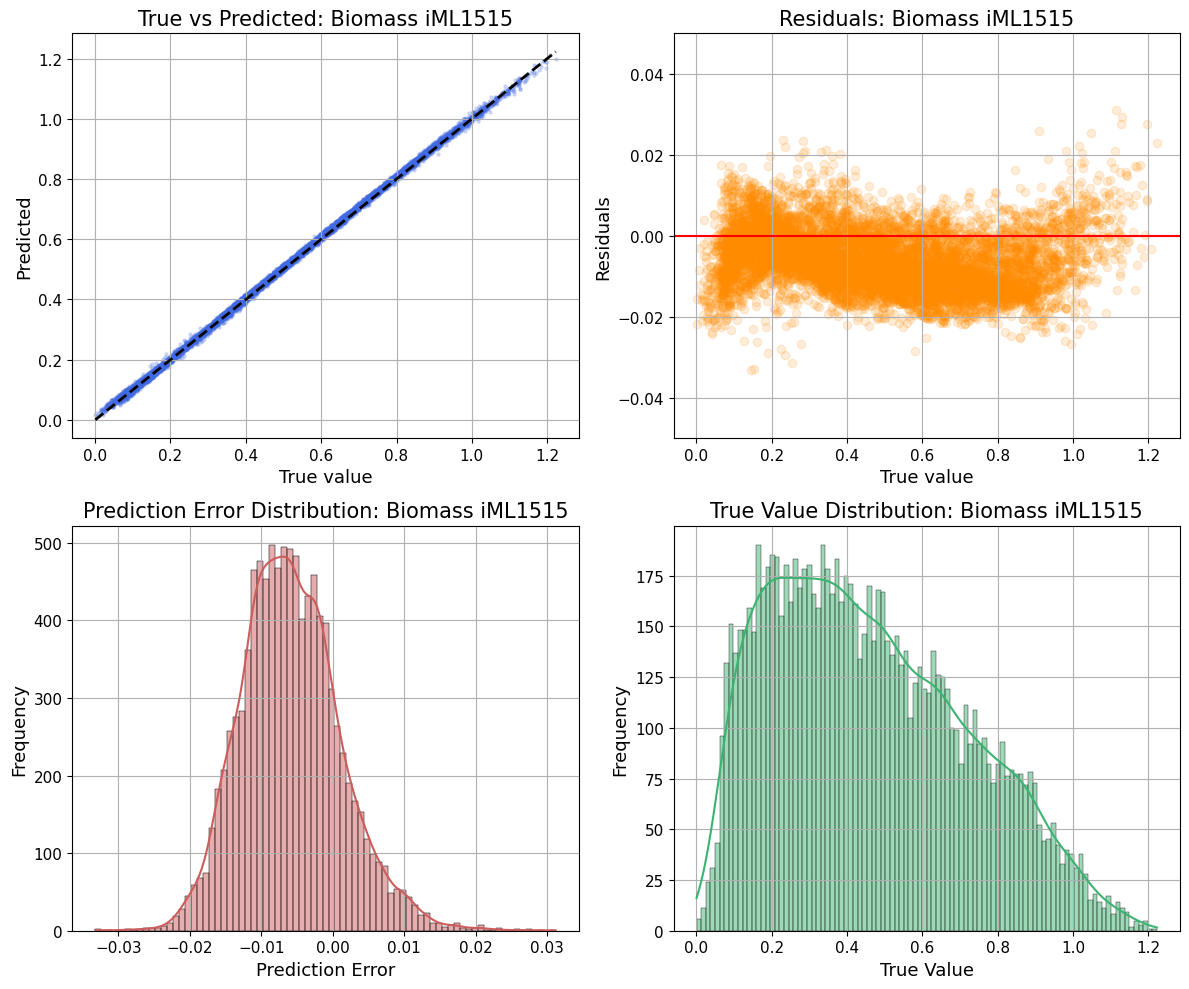

In [16]:
#diagnostics_to_plot = ['BIOMASS_Ec_iML1515_core_75p37M_flux']
diagnostics_to_plot = ["BIOMASS_Ec_iML1515_WT_75p37M_flux"]

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=save_path)

Plotting 5 diagnostic fluxes
EX_glc__D_e_flux:
------------------------------------------------------------
EX_glc__D_e_flux token index: 180
injected medium slot: True
y_true range: -15.0 to -1.0
y_pred range: -15.20392894744873 to -1.03523588180542
R2: 0.9999
MAE: 0.025364
RMSE: 0.041918


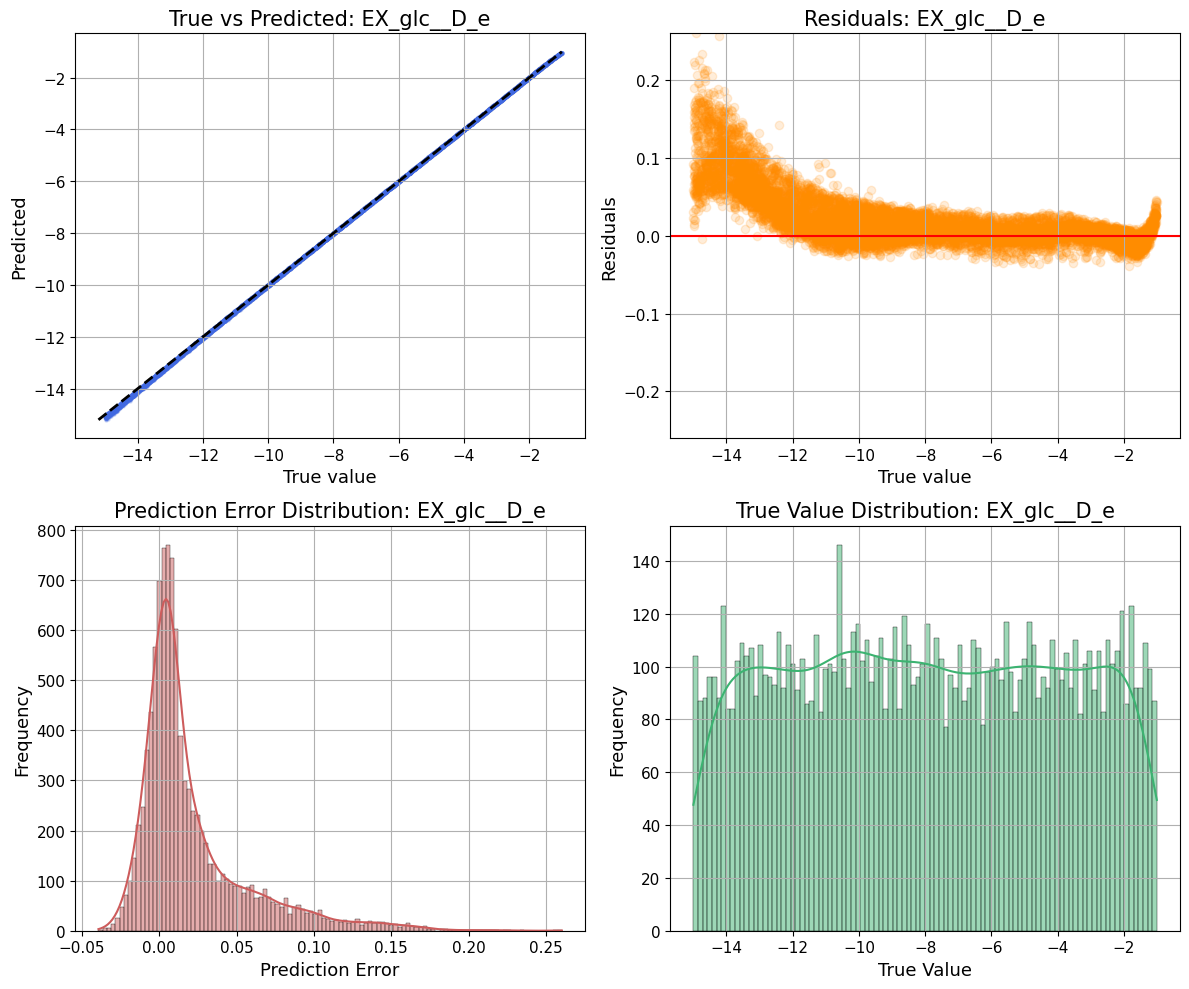

EX_o2_e_flux:
------------------------------------------------------------
EX_o2_e_flux token index: 1981
injected medium slot: True
y_true range: -29.798036575317383 to -1.0
y_pred range: -30.327390670776367 to -1.0192625522613525
R2: 0.9990
MAE: 0.159355
RMSE: 0.209882


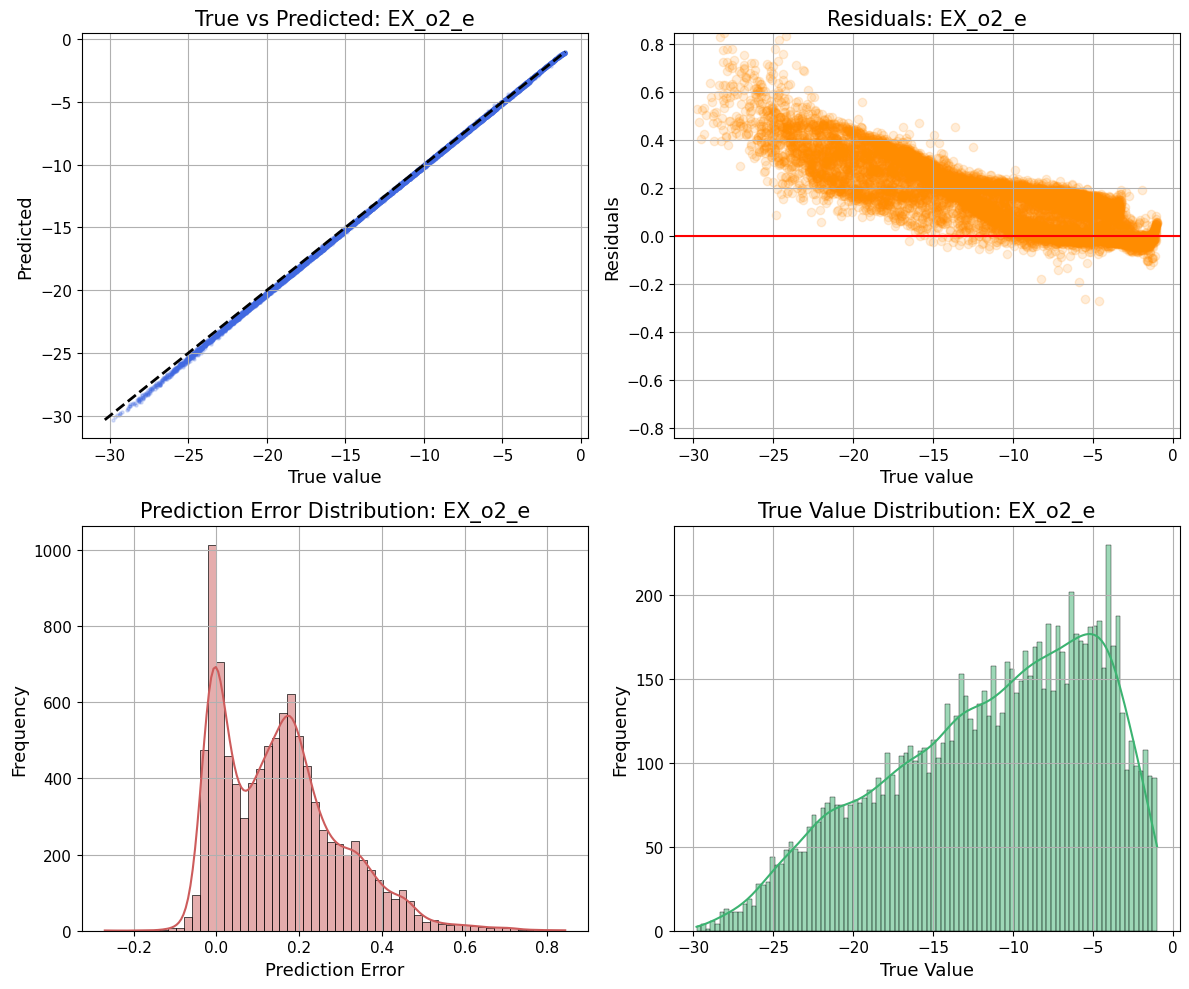

EX_co2_e_flux:
------------------------------------------------------------
EX_co2_e_flux token index: 45
injected medium slot: True
y_true range: 0.0 to 29.872682571411133
y_pred range: 0.002497434616088867 to 29.475160598754883
R2: 0.9998
MAE: 0.063243
RMSE: 0.084483


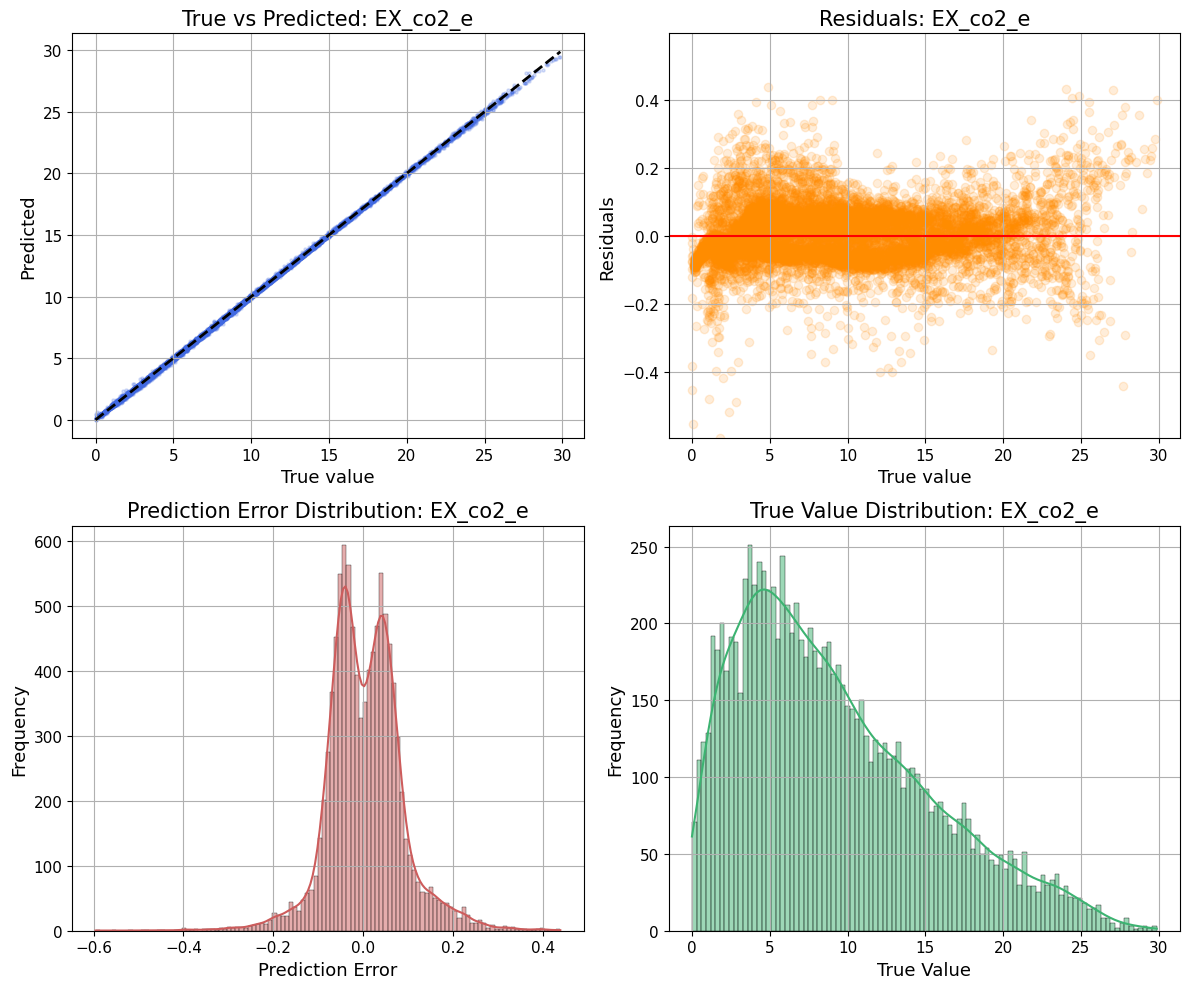

EX_etoh_e_flux:
------------------------------------------------------------
EX_etoh_e_flux token index: 1525
injected medium slot: True
y_true range: -1.6645101108366216e-18 to 0.8930307030677795
y_pred range: -0.0007284730672836304 to 0.010128691792488098
R2: -0.5444
MAE: 0.007376
RMSE: 0.012112


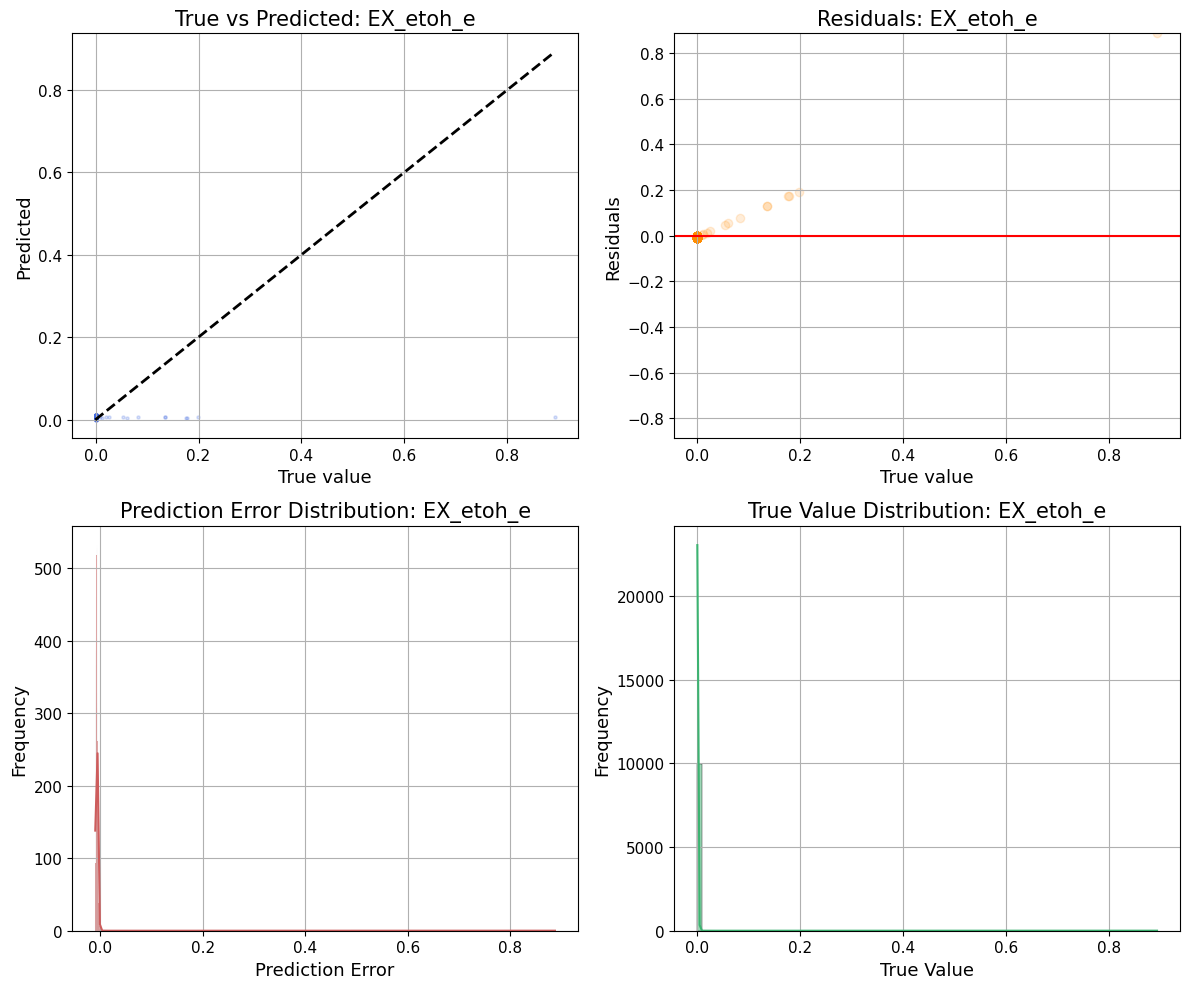

EX_ac_e_flux:
------------------------------------------------------------
EX_ac_e_flux token index: 106
injected medium slot: True
y_true range: 0.0 to 3.990000009536743
y_pred range: -0.039507508277893066 to 4.167404651641846
R2: 0.9947
MAE: 0.019807
RMSE: 0.043536


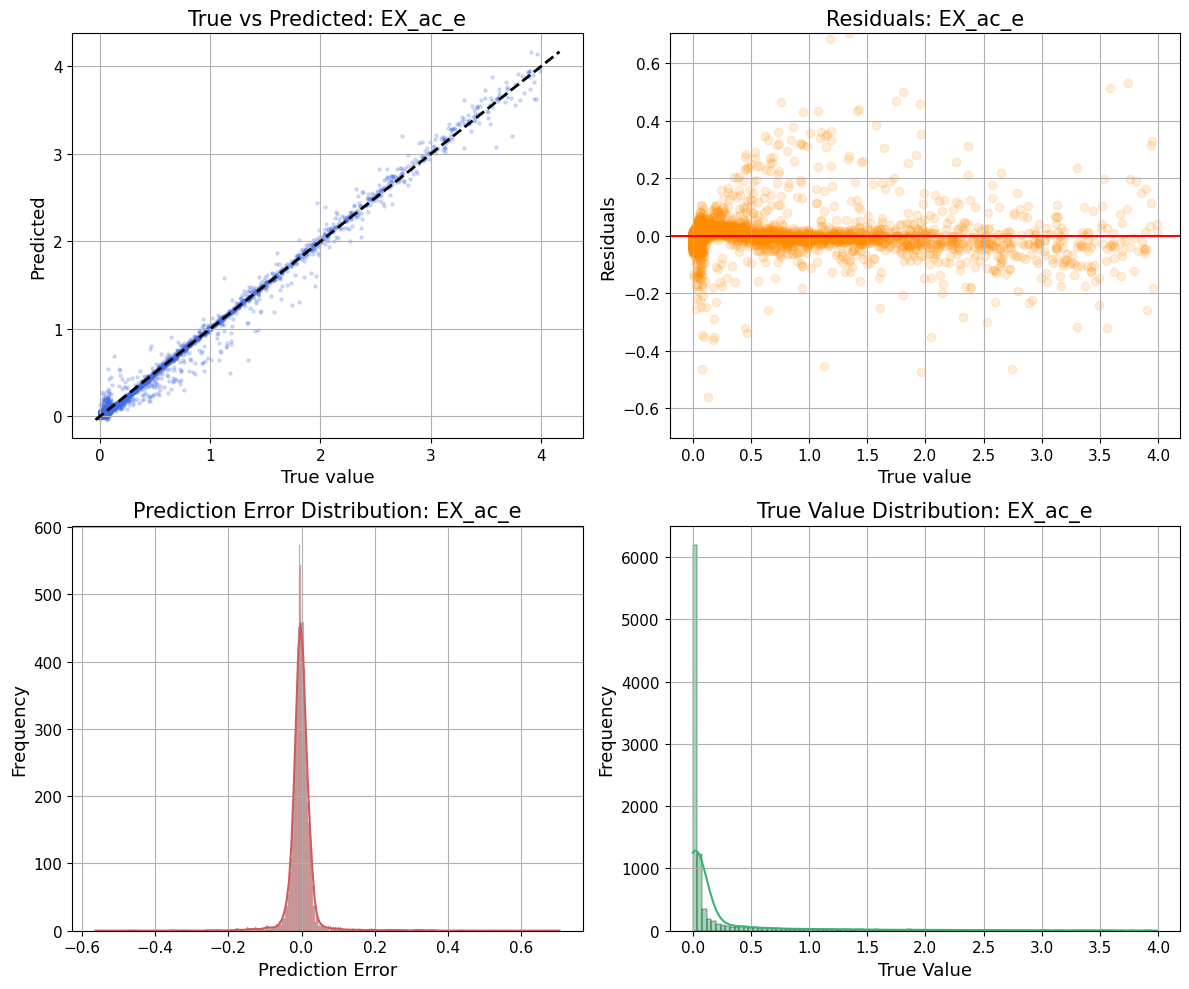

In [17]:
# Diagnostic plots for MINN/reference fluxes.
# False: plot only the 5 MINN reservoir-context fluxes.
# True: plot all 46 non-biomass reference fluxes.
PLOT_ALL_46_FLUX_DIAGNOSTICS = False

target_fluxes_5 = [
    'EX_glc__D_e_flux',
    'EX_o2_e_flux',
    'EX_co2_e_flux',
    'EX_etoh_e_flux',
    'EX_ac_e_flux',
]

target_fluxes_46 = [
    'GLCptspp_flux', 'PGI_flux', 'PFK_flux', 'FBA_flux', 'TPI_flux',
    'PGK_flux', 'GAPD_flux', 'ENO_flux', 'PGM_flux', 'PYK_flux',
    'PDH_flux', 'G6PDH2r_flux', 'PGL_flux', 'GND_flux', 'RPE_flux',
    'RPI_flux', 'TKT1_flux', 'TALA_flux', 'TKT2_flux', 'CS_flux',
    'ACONTb_flux', 'ACONTa_flux', 'ICDHyr_flux', 'SUCOAS_flux', 'AKGDH_flux',
    'SUCDi_flux', 'FUM_flux', 'MDH_flux', 'PPC_flux', 'ME2_flux',
    'ICL_flux', 'MALS_flux', 'ACKr_flux', 'PTAr_flux', 'LDH_D_flux',
    'ACALD_flux', 'ALCD2x_flux', 'EX_glc__D_e_flux', 'EX_o2_e_flux',
    'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_ac_e_flux', 'EX_lac__D_e_flux',
    'EX_succ_e_flux', 'EX_pyr_e_flux', 'EX_for_e_flux',
]

diagnostics_to_plot = target_fluxes_46 if PLOT_ALL_46_FLUX_DIAGNOSTICS else target_fluxes_5
missing_diagnostic_fluxes = [flux_name for flux_name in diagnostics_to_plot if flux_name not in outputs]
if missing_diagnostic_fluxes:
    raise ValueError('Missing diagnostic flux tokens in outputs: ' + ', '.join(missing_diagnostic_fluxes))

print(f"Plotting {len(diagnostics_to_plot)} diagnostic fluxes")
for flux_name in diagnostics_to_plot:
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=None)


In [18]:
# Overall model metrics across all output fluxes (flattened)
def _compute_overall_metrics(model_ref, X_ref, y_ref, outputs_ref, device_ref, batch_size_ref):
    model_eval = model_ref.to(device_ref).eval()
    V = len(outputs_ref)

    if X_ref.shape[1] != V or y_ref.shape[1] != V:
        raise ValueError(
            f"Expected X_test/y_test second dim == len(outputs)={V}, got {X_ref.shape[1]} and {y_ref.shape[1]}"
        )

    pred_batches = []
    true_batches = []
    perm = None
    use_amp = device_ref.type == "cuda"

    with torch.inference_mode():
        for i in range(0, X_ref.shape[0], batch_size_ref):
            xb = X_ref[i:i + batch_size_ref].to(device_ref)
            yb_true = y_ref[i:i + batch_size_ref]

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    preds_all_layers, selected_indices = model_eval(xb.unsqueeze(-1), output_subset=None)
            else:
                preds_all_layers, selected_indices = model_eval(xb.unsqueeze(-1), output_subset=None)

            preds_last = preds_all_layers[:, :, -1]  # (B, S)

            if perm is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                selected_indices_np = selected_indices_np.astype(int)

                if selected_indices_np.size != V:
                    raise RuntimeError(f"Model returned {selected_indices_np.size} outputs, expected {V}.")

                inv = np.full(V, -1, dtype=np.int64)
                inv[selected_indices_np] = np.arange(selected_indices_np.size, dtype=np.int64)
                if (inv < 0).any():
                    missing = np.where(inv < 0)[0].tolist()
                    raise RuntimeError(f"Missing output indices in model forward pass: {missing[:10]}")
                perm = torch.as_tensor(inv, device=preds_last.device, dtype=torch.long)

            yb_pred = preds_last.index_select(1, perm).detach().cpu().numpy().astype(np.float32, copy=False)
            pred_batches.append(yb_pred)
            true_batches.append(yb_true.detach().cpu().numpy().astype(np.float32, copy=False))

            del xb, preds_all_layers, preds_last, selected_indices
            if device_ref.type == "cuda":
                torch.cuda.empty_cache()

    y_pred_full = np.concatenate(pred_batches, axis=0)
    y_true_full = np.concatenate(true_batches, axis=0)

    overall_r2 = r2_score(y_true_full.ravel(), y_pred_full.ravel())
    overall_mae = mean_absolute_error(y_true_full.ravel(), y_pred_full.ravel())
    overall_rmse = root_mean_squared_error(y_true_full.ravel(), y_pred_full.ravel())
    return overall_r2, overall_mae, overall_rmse

original_device = next(model.parameters()).device
preferred_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if preferred_device.type == "cuda":
    batch_size_metrics = 2
else:
    batch_size_metrics = 32

used_device = preferred_device
try:
    overall_r2, overall_mae, overall_rmse = _compute_overall_metrics(
        model, X_test, y_test, outputs, preferred_device, batch_size_metrics
    )
except RuntimeError as e:
    if preferred_device.type == "cuda" and "out of memory" in str(e).lower():
        print("CUDA OOM during overall metrics; falling back to CPU...")
        torch.cuda.empty_cache()
        used_device = torch.device("cpu")
        overall_r2, overall_mae, overall_rmse = _compute_overall_metrics(
            model, X_test, y_test, outputs, used_device, 32
        )
    else:
        raise
finally:
    model.to(original_device)

print("Overall model metrics (all fluxes, flattened):")
print(f"Device used: {used_device}")
print(f"R2:   {overall_r2:.4f}")
print(f"MAE:  {overall_mae:.6f}")
print(f"RMSE: {overall_rmse:.6f}")

Overall model metrics (all fluxes, flattened):
Device used: cuda
R2:   0.9998
MAE:  0.006096
RMSE: 0.025891


### FluxTransformer Reservoir Training

This section trains the front MLP that feeds the frozen FluxTransformer reservoir.

The MINN-style input matrix still merges transcriptomics, proteomics, and measured glucose/oxygen uptake. The notebook now evaluates both FluxTransformer context options in separate cells: `MINN_GLC_O2_CONTEXT_MODE="measured"` copies measured glucose and oxygen directly into their context tokens while the front MLP predicts CO2, ethanol, and acetate; `MINN_GLC_O2_CONTEXT_MODE="predicted"` lets the front MLP predict all 5 context channels as an ablation.

FluxTransformer receives a full vocabulary-sized input vector: the configured reservoir-context positions are filled by measured copies and/or MLP predictions according to the flag, base-exchange positions are filled with fixed medium/background values, and all remaining positions are set to zero. The transformer-output training loss uses non-context flux targets by default, so the MLP cap outputs are not forced to equal the observed exchange fluxes.

The measured-mode and predicted-mode reservoir runs are summarized first. The downstream FluxTransformer-to-pFBA section then explicitly runs both context modes with measured glucose/oxygen pFBA bounds and the extra-cap switch selected by `MINN_PFBA_EXTRA_CONSTRAINT_MODE`: ethanol/acetate only, or CO2/ethanol/acetate.


In [19]:
from pathlib import Path


def _minn_to_flux_token(rxn_name: str, outputs_vocab):
    """Map MINN reaction naming to FluxTransformer token names (+ sign conversion for *_rev)."""
    if rxn_name.startswith("R_BIOMASS"):
        core_token = "BIOMASS_Ec_iML1515_core_75p37M_flux"
        return (core_token, 1.0) if core_token in outputs_vocab else (None, 1.0)

    base = rxn_name
    if base.startswith("R_"):
        base = base[2:]

    sign = 1.0
    if base.endswith("_fwd"):
        base = base[:-4]
    elif base.endswith("_rev"):
        base = base[:-4]
        sign = -1.0

    tok = f"{base}_flux"
    if tok in outputs_vocab:
        return tok, sign
    return None, None


# ----- FluxTransformer reservoir settings -----
MINN_DATA_DIR = "./MINN_data"
# Fluxomics-file switch:
# - fitted: Table 4-style MINN reproduction/comparability
# - non-fitted: robustness check against the split original measurements (active)
# MINN_FLUXOMICS_FILE = "fluxomics_iAF1260_reduced_split_fit.csv"
MINN_FLUXOMICS_FILE = "fluxomics_iAF1260_reduced_split.csv"

# 2 measured medium inputs (same as MINN dataset config)
MINN_INPUT_FLUX_COLS = ["R_EX_glc__D_e_rev", "R_EX_o2_e_rev"]
MINN_MEASURED_CONTEXT_SOURCE = list(MINN_INPUT_FLUX_COLS)

# CO2/ethanol/acetate are latent front-MLP control/cap channels by default.
MINN_LEARNED_CONSTRAINT_SOURCE = [
    "R_EX_co2_e_fwd",
    "R_EX_etoh_e",
    "R_EX_ac_e",
]

# Full 5-channel reservoir context passed into FluxTransformer.
MINN_RESERVOIR_CONTEXT_SOURCE = MINN_MEASURED_CONTEXT_SOURCE + MINN_LEARNED_CONSTRAINT_SOURCE

# Default: copy measured glucose/O2 into the FluxTransformer context. Set to
# "predicted" to reproduce the MINN-reservoir-style ablation where the front MLP predicts all 5 channels.
MINN_GLC_O2_CONTEXT_MODE = "measured"  # "measured" or "predicted"


def configure_minn_glc_o2_context_mode(mode="measured"):
    """Configure whether FluxTransformer receives measured or MLP-predicted glucose/O2 context values."""
    global MINN_GLC_O2_CONTEXT_MODE
    global MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE, MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE
    global minn_measured_context_positions, minn_measured_context_positions_t
    global minn_predicted_context_positions, minn_predicted_context_positions_t
    global minn_cap_context_positions, minn_cap_context_positions_t
    global minn_predicted_token_names, minn_measured_token_names, minn_measured_feature_indices
    global minn_learned_token_names, minn_learned_context_positions, minn_learned_context_positions_t

    mode = str(mode).lower().strip()
    if mode not in {"measured", "predicted"}:
        raise ValueError('MINN_GLC_O2_CONTEXT_MODE must be "measured" or "predicted"')

    MINN_GLC_O2_CONTEXT_MODE = mode
    if mode == "measured":
        MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE = list(MINN_MEASURED_CONTEXT_SOURCE)
        MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE = list(MINN_LEARNED_CONSTRAINT_SOURCE)
    else:
        MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE = []
        MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE = list(MINN_RESERVOIR_CONTEXT_SOURCE)

    minn_measured_context_positions = [
        minn_source_to_context_position[src] for src in MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE
    ]
    minn_measured_context_positions_t = torch.tensor(minn_measured_context_positions, dtype=torch.long, device=device)
    minn_predicted_context_positions = [
        minn_source_to_context_position[src] for src in MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE
    ]
    minn_predicted_context_positions_t = torch.tensor(minn_predicted_context_positions, dtype=torch.long, device=device)
    minn_cap_context_positions = [minn_source_to_context_position[src] for src in MINN_LEARNED_CONSTRAINT_SOURCE]
    minn_cap_context_positions_t = torch.tensor(minn_cap_context_positions, dtype=torch.long, device=device)
    minn_predicted_token_names = [minn_mapped_by_source[src][0] for src in MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE]
    minn_measured_token_names = [minn_mapped_by_source[src][0] for src in MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE]
    minn_measured_feature_indices = [minn_feature_names.index(src) for src in MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE]

    # Backward-compatible aliases for downstream exploratory cells.
    minn_learned_token_names = list(minn_predicted_token_names)
    minn_learned_context_positions = list(minn_predicted_context_positions)
    minn_learned_context_positions_t = minn_predicted_context_positions_t

    return {
        "mode": MINN_GLC_O2_CONTEXT_MODE,
        "measured_context_source": list(MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE),
        "predicted_context_source": list(MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE),
    }

# Keep the 5 context/cap channels out of the transformer-output loss by default.
# This makes the front-MLP outputs latent controls instead of exact exchange-flux regressions.
MINN_FLUX_TARGET_EXCLUDE_CONTEXT = True

# Downstream pFBA comparison mode. Reservoir training still keeps all 5 context channels available.
# Predicted extra exchanges are treated as nonnegative secretion upper caps, not exact fluxes.
MINN_PFBA_EXTRA_CONSTRAINT_MODE = "co2_etoh_ac_cap"  # "etoh_ac_cap" or "co2_etoh_ac_cap"
MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE = {
    "etoh_ac_cap": ["R_EX_etoh_e", "R_EX_ac_e"],
    "co2_etoh_ac_cap": ["R_EX_co2_e_fwd", "R_EX_etoh_e", "R_EX_ac_e"],
}
if MINN_PFBA_EXTRA_CONSTRAINT_MODE not in MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE:
    raise ValueError(
        f"MINN_PFBA_EXTRA_CONSTRAINT_MODE must be one of {sorted(MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE)}"
    )
MINN_PFBA_EXTRA_CONSTRAINT_SOURCE = list(MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE[MINN_PFBA_EXTRA_CONSTRAINT_MODE])
MINN_PFBA_PRED_COL_BY_SOURCE = {
    "R_EX_co2_e_fwd": "R_EX_co2_e_fwd_pred",
    "R_EX_etoh_e": "R_EX_etoh_e_pred",
    "R_EX_ac_e": "R_EX_ac_e_pred",
}
MINN_PFBA_RXN_BY_SOURCE = {
    "R_EX_co2_e_fwd": "EX_co2_e",
    "R_EX_etoh_e": "EX_etoh_e",
    "R_EX_ac_e": "EX_ac_e",
}

# base_exchanges from generate_ecoli_iML1515_MINN_data.py
BASE_EXCHANGES = [
    "EX_pi_e",
    "EX_co2_e",
    "EX_h_e",
    "EX_mn2_e",
    "EX_fe2_e",
    "EX_zn2_e",
    "EX_mg2_e",
    "EX_ca2_e",
    "EX_ni2_e",
    "EX_cu2_e",
    "EX_cobalt2_e",
    "EX_h2o_e",
    "EX_mobd_e",
    "EX_so4_e",
    "EX_nh4_e",
    "EX_k_e",
    "EX_na1_e",
    "EX_cl_e",
    "EX_o2_e",
    "EX_fe3_e",
    "EX_sel_e",
    "EX_tungs_e",
    "EX_slnt_e",
    "EX_cbl1_e",
]
DEFAULT_BASE_EXCHANGE_RATE = 50.0
PFBA_EXTRA_CONSTRAINT_TOL = 1e-6

# pFBA objective is fixed to iML1515 core biomass for this notebook.
PFBA_OBJECTIVE_VARIANT = "core"
PFBA_OBJECTIVE_RXN = "BIOMASS_Ec_iML1515_core_75p37M"
PFBA_BIOMASS_METRIC_TOKEN = f"{PFBA_OBJECTIVE_RXN}_flux"


def _build_mapped_sources(source_cols, outputs_vocab, label):
    mapped = []
    seen_tokens = set()
    for source_col in source_cols:
        tok, sign = _minn_to_flux_token(source_col, outputs_vocab)
        if tok is None:
            raise RuntimeError(f"Could not map {label} source {source_col} into FluxTransformer token vocabulary")
        if tok in seen_tokens:
            raise RuntimeError(f"Duplicate FluxTransformer token {tok} while mapping {label} sources")
        seen_tokens.add(tok)
        mapped.append((source_col, tok, outputs_vocab.index(tok), float(sign)))
    return mapped


def _signed_flux_rows(fl_idx, experiments, mapped):
    rows = []
    for exp in experiments:
        row = []
        for src, _tok, _idx, sign in mapped:
            row.append(float(fl_idx.at[exp, src]) * sign)
        rows.append(row)
    return np.asarray(rows, dtype=np.float32)


def load_minn_omics_for_reservoir(data_dir: str, outputs_vocab):
    """
    Load MINN-style input (omics + 2 measured fluxes), the 5-channel reservoir
    context, and the transformer-output flux targets used to train latent caps.
    """
    data_dir_p = Path(data_dir)
    transcript_path = data_dir_p / "transcriptomics.csv"
    proteomics_path = data_dir_p / "proteomics.csv"
    fluxomics_path = data_dir_p / MINN_FLUXOMICS_FILE

    if not transcript_path.exists() or not proteomics_path.exists() or not fluxomics_path.exists():
        raise FileNotFoundError(
            f"Expected MINN files in {data_dir}: transcriptomics.csv, proteomics.csv, {MINN_FLUXOMICS_FILE}"
        )

    tr = pd.read_csv(transcript_path)
    pr = pd.read_csv(proteomics_path)
    fl = pd.read_csv(fluxomics_path)

    # MINN-style merge
    x_df = tr.merge(pr, on="experiment", how="left")

    missing_input = [c for c in MINN_INPUT_FLUX_COLS if c not in fl.columns]
    if missing_input:
        raise ValueError(f"Missing MINN input flux columns: {missing_input}")

    x_df = x_df.merge(fl[["experiment"] + MINN_INPUT_FLUX_COLS], on="experiment", how="left")
    x_df = x_df[x_df["experiment"].isin(fl["experiment"])].reset_index(drop=True)

    missing_context = [c for c in MINN_RESERVOIR_CONTEXT_SOURCE if c not in fl.columns]
    if missing_context:
        raise ValueError(f"Missing reservoir-context columns in fluxomics file: {missing_context}")

    excluded_target_sources = set(MINN_RESERVOIR_CONTEXT_SOURCE) if MINN_FLUX_TARGET_EXCLUDE_CONTEXT else set()
    target_source_cols = [c for c in fl.columns if c != "experiment" and c not in excluded_target_sources]
    if not target_source_cols:
        raise ValueError("No transformer-output flux targets left after applying MINN_FLUX_TARGET_EXCLUDE_CONTEXT")

    fl_idx = fl.set_index("experiment")
    context_mapped = _build_mapped_sources(MINN_RESERVOIR_CONTEXT_SOURCE, outputs_vocab, "reservoir-context")
    target_mapped = _build_mapped_sources(target_source_cols, outputs_vocab, "training target")

    # Inputs
    x_features = [c for c in x_df.columns if c != "experiment"]
    X_np = x_df[x_features].to_numpy(dtype=np.float32)

    experiments = x_df["experiment"].tolist()
    y_context_np = _signed_flux_rows(fl_idx, experiments, context_mapped)
    y_target_np = _signed_flux_rows(fl_idx, experiments, target_mapped)

    context_token_names = [tok for _src, tok, _idx, _sign in context_mapped]
    context_token_indices = [idx for _src, _tok, idx, _sign in context_mapped]
    target_token_names = [tok for _src, tok, _idx, _sign in target_mapped]
    target_token_indices = [idx for _src, _tok, idx, _sign in target_mapped]

    return (
        X_np,
        y_target_np,
        y_context_np,
        x_features,
        context_token_names,
        context_token_indices,
        context_mapped,
        target_token_names,
        target_token_indices,
        target_mapped,
        experiments,
    )


(
    X_minn_np,
    y_minn_np,
    y_minn_context_np,
    minn_feature_names,
    minn_context_token_names,
    minn_context_indices,
    minn_mapped_sources,
    minn_target_token_names,
    minn_target_indices,
    minn_target_mapped_sources,
    minn_experiments,
) = load_minn_omics_for_reservoir(
    data_dir=MINN_DATA_DIR,
    outputs_vocab=outputs,
)
y_minn_target_np = y_minn_np

minn_target_indices_t = torch.tensor(minn_target_indices, dtype=torch.long, device=device)
minn_context_indices_t = torch.tensor(minn_context_indices, dtype=torch.long, device=device)
# Signs used in MINN source naming (*_rev -> -1). Needed to recover positive context magnitudes.
minn_target_signs = np.asarray([float(sign) for _src, _tok, _idx, sign in minn_target_mapped_sources], dtype=np.float32)
minn_context_signs = np.asarray([float(sign) for _src, _tok, _idx, sign in minn_mapped_sources], dtype=np.float32)
minn_target_signs_t = torch.tensor(minn_target_signs, dtype=torch.float32, device=device)
minn_context_signs_t = torch.tensor(minn_context_signs, dtype=torch.float32, device=device)

minn_source_to_context_position = {src: i for i, (src, _tok, _idx, _sign) in enumerate(minn_mapped_sources)}
minn_mapped_by_source = {src: (tok, idx, sign) for src, tok, idx, sign in minn_mapped_sources}
configure_minn_glc_o2_context_mode(MINN_GLC_O2_CONTEXT_MODE)

# Build fixed base exchange constraints in FluxTransformer token space.
# Rules for the full input vector assembled inside the wrapper:
# - measured-mode glucose/oxygen context tokens are copied from measured inputs
# - predicted context tokens are filled from front-MLP outputs
# - base_exchanges outside the 5 context tokens are fixed at DEFAULT_BASE_EXCHANGE_RATE
# - all other token positions are zero
context_token_set = set(minn_context_token_names)
fixed_base_token_values = {}
for ex in BASE_EXCHANGES:
    tok = f"{ex}_flux"
    if tok in outputs and tok not in context_token_set:
        fixed_base_token_values[tok] = float(DEFAULT_BASE_EXCHANGE_RATE)


class FrozenFluxTransformerWithMLP(nn.Module):
    """
    FluxTransformer reservoir wrapper:
    - By default, measured glucose/oxygen are copied directly into the reservoir context
    - The front MLP predicts latent context/control values for CO2/ethanol/acetate
    - Optional predicted glucose/O2 mode lets the front MLP predict all 5 context channels
    - Frozen pretrained FluxTransformer

    pFBA evaluation later always keeps glucose/oxygen measured and applies selected
    predicted secretion channels as upper-cap constraints.
    """
    def __init__(
        self,
        flux_transformer: nn.Module,
        input_dim: int,
        predicted_token_names,
        measured_token_names,
        measured_feature_indices,
        fixed_base_token_values,
        hidden_dim: int = 512,
        drop_rate: float = 0.25,
    ):
        super().__init__()
        self.frozen_flux_transformer = flux_transformer
        self.vocab_size = int(self.frozen_flux_transformer.vocab_size)

        self.predicted_token_names = list(predicted_token_names)
        self.measured_token_names = list(measured_token_names)
        self.measured_feature_indices_list = list(measured_feature_indices)
        self.fixed_base_token_values = dict(fixed_base_token_values)

        token_to_idx = {tok: i for i, tok in enumerate(outputs)}
        predicted_indices = []
        for tok in self.predicted_token_names:
            if tok not in token_to_idx:
                raise ValueError(f"Predicted context token not found in outputs vocab: {tok}")
            predicted_indices.append(token_to_idx[tok])

        measured_indices = []
        for tok in self.measured_token_names:
            if tok not in token_to_idx:
                raise ValueError(f"Measured context token not found in outputs vocab: {tok}")
            measured_indices.append(token_to_idx[tok])

        fixed_names = []
        fixed_vals = []
        for tok, val in self.fixed_base_token_values.items():
            if tok in token_to_idx:
                fixed_names.append(tok)
                fixed_vals.append(float(val))

        self.register_buffer("predicted_indices", torch.tensor(predicted_indices, dtype=torch.long), persistent=True)
        self.register_buffer("measured_indices", torch.tensor(measured_indices, dtype=torch.long), persistent=True)
        self.register_buffer("measured_feature_indices", torch.tensor(self.measured_feature_indices_list, dtype=torch.long), persistent=True)
        self.register_buffer("fixed_indices", torch.tensor([token_to_idx[t] for t in fixed_names], dtype=torch.long), persistent=True)
        self.register_buffer("fixed_values", torch.tensor(fixed_vals, dtype=torch.float32), persistent=True)

        for p in self.frozen_flux_transformer.parameters():
            p.requires_grad = False
        self.frozen_flux_transformer.eval()

        self.front_mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(drop_rate),
            nn.Linear(hidden_dim, len(self.predicted_token_names)),
        )

    def train(self, mode: bool = True):
        super().train(mode)
        self.frozen_flux_transformer.eval()
        return self

    def predict_context_values(self, x):
        return F.softplus(self.front_mlp(x))

    def predict_learned_constraints(self, x):
        # Backward-compatible name; these are latent predicted context values by default.
        return self.predict_context_values(x)

    def _measured_context_from_x(self, x):
        if self.measured_feature_indices.numel() == 0:
            return x.new_zeros((x.size(0), 0))
        return x.index_select(1, self.measured_feature_indices.to(device=x.device))

    def build_full_input_vector(self, x, measured_context_values=None):
        # x: [B, n_features]
        predicted_vals = self.predict_context_values(x)
        if measured_context_values is None:
            # Fallback is intended for raw, unscaled X where measured flux columns are present.
            measured_context_values = self._measured_context_from_x(x)
        measured_context_values = measured_context_values.to(dtype=x.dtype, device=x.device)
        if measured_context_values.shape[1] != self.measured_indices.numel():
            raise ValueError(
                f"Expected {self.measured_indices.numel()} measured context values, "
                f"got {measured_context_values.shape[1]}"
            )

        B = x.size(0)
        c0 = torch.zeros(B, self.vocab_size, dtype=x.dtype, device=x.device)

        if self.fixed_indices.numel() > 0:
            c0[:, self.fixed_indices] = self.fixed_values.to(dtype=x.dtype, device=x.device).unsqueeze(0)

        if self.measured_indices.numel() > 0:
            c0[:, self.measured_indices] = measured_context_values
        if self.predicted_indices.numel() > 0:
            c0[:, self.predicted_indices] = predicted_vals
        return c0

    def forward(self, x, measured_context_values=None, output_subset=None, return_embedding=False):
        if x.dim() == 3 and x.size(-1) == 1:
            x = x.squeeze(-1)
        c0 = self.build_full_input_vector(x, measured_context_values=measured_context_values).unsqueeze(-1)
        return self.frozen_flux_transformer(c0, output_subset=output_subset, return_embedding=return_embedding)


# Build model
minn_model = FrozenFluxTransformerWithMLP(
    flux_transformer=model,
    input_dim=X_minn_np.shape[1],
    predicted_token_names=minn_predicted_token_names,
    measured_token_names=minn_measured_token_names,
    measured_feature_indices=minn_measured_feature_indices,
    fixed_base_token_values=fixed_base_token_values,
    hidden_dim=512,
    drop_rate=0.25,
).to(device)

with torch.no_grad():
    _x2 = torch.tensor(X_minn_np[:2], dtype=torch.float32, device=device)
    _context2 = torch.tensor(y_minn_context_np[:2], dtype=torch.float32, device=device)
    _context_mag2 = torch.clamp(_context2 * minn_context_signs_t.unsqueeze(0), min=0.0)
    _measured2 = (
        _context_mag2.index_select(1, minn_measured_context_positions_t)
        if minn_measured_context_positions_t.numel() > 0
        else None
    )
    _c0_sanity = minn_model.build_full_input_vector(_x2, measured_context_values=_measured2)
    _pred_sanity, _sel_sanity = minn_model(_x2, measured_context_values=_measured2, output_subset=None)

trainable_params = sum(p.numel() for p in minn_model.parameters() if p.requires_grad)
frozen_flux_params = sum(p.numel() for p in minn_model.frozen_flux_transformer.parameters() if not p.requires_grad)

print("Loaded MINN-style omics dataset")
print(f"MINN data dir: {MINN_DATA_DIR}")
print(f"Samples: {X_minn_np.shape[0]}")
print(f"Input features (omics + 2 measured fluxes): {X_minn_np.shape[1]}")
print("Reservoir context source order:", MINN_RESERVOIR_CONTEXT_SOURCE)
print("Transformer glucose/O2 context mode:", MINN_GLC_O2_CONTEXT_MODE)
print("Context copied from measured inputs:", MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE)
print("Context predicted by front MLP:", MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE)
print("pFBA extra predicted constraint mode:", MINN_PFBA_EXTRA_CONSTRAINT_MODE)
print("pFBA extra predicted constraints:", MINN_PFBA_EXTRA_CONSTRAINT_SOURCE)
print(f"Transformer-output training targets: {len(minn_target_token_names)} (exclude context={MINN_FLUX_TARGET_EXCLUDE_CONTEXT})")
print("Mapped context token names:", minn_context_token_names)
print("First mapped training target token names:", minn_target_token_names[:10])
print("MINN context source -> FluxTransformer token mapping (with sign)")
for src, tok, idx, sign in minn_mapped_sources:
    print(f"  {src:>18} -> {tok:<30} idx={idx:4d} sign={sign:+.0f}")
print("Measured input feature positions:", dict(zip(MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE, minn_measured_feature_indices)))
print(f"Fixed base exchange token count: {len(fixed_base_token_values)} (value={DEFAULT_BASE_EXCHANGE_RATE})")
print(f"Trainable params (front MLP only): {trainable_params:,}")
print(f"Frozen FluxTransformer params:      {frozen_flux_params:,}")
print(f"Sanity c0 shape:                   {tuple(_c0_sanity.shape)}")
print(f"Sanity transformer output shape:   {tuple(_pred_sanity.shape)}")


Loaded MINN-style omics dataset
MINN data dir: ./MINN_data
Samples: 29
Input features (omics + 2 measured fluxes): 141
Reservoir context source order: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev', 'R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
Transformer glucose/O2 context mode: measured
Context copied from measured inputs: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev']
Context predicted by front MLP: ['R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
pFBA extra predicted constraint mode: co2_etoh_ac_cap
pFBA extra predicted constraints: ['R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
Transformer-output training targets: 42 (exclude context=True)
Mapped context token names: ['EX_glc__D_e_flux', 'EX_o2_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_ac_e_flux']
First mapped training target token names: ['GLCptspp_flux', 'PGI_flux', 'PFK_flux', 'FBA_flux', 'TPI_flux', 'PGK_flux', 'GAPD_flux', 'ENO_flux', 'PGM_flux', 'PYK_flux']
MINN context source -> FluxTransformer token mapping (with sign)
   R_EX_glc__D_

In [20]:
# Assertions: token/reaction mapping and sign conventions for MINN -> iML1515 integration

import xml.etree.ElementTree as ET
from pathlib import Path

# 1) Required reservoir-context tokens must exist in outputs vocab
required_pred_tokens = [
    "EX_glc__D_e_flux",
    "EX_o2_e_flux",
    "EX_co2_e_flux",
    "EX_etoh_e_flux",
    "EX_ac_e_flux",
]

missing_pred_tokens = [t for t in required_pred_tokens if t not in outputs]
assert not missing_pred_tokens, (
    "Missing required reservoir-context tokens in outputs vocab: "
    + ", ".join(missing_pred_tokens)
)

# 2) Base exchange tokens must exist in outputs vocab
base_tokens = [f"{ex}_flux" for ex in BASE_EXCHANGES]
missing_base_tokens = [t for t in base_tokens if t not in outputs]
assert not missing_base_tokens, (
    "Missing base exchange tokens in outputs vocab: "
    + ", ".join(missing_base_tokens)
)

# 3) pFBA-constrained reactions must exist in iML1515 model
model_path = Path("./models/iML1515.xml")
assert model_path.exists(), f"SBML model not found: {model_path}"

ns = {"sbml": "http://www.sbml.org/sbml/level3/version1/core"}
root = ET.parse(model_path).getroot()
rxn_ids = [r.attrib.get("id", "") for r in root.findall('.//sbml:listOfReactions/sbml:reaction', ns)]
rxn_ids_norm = {(rid[2:] if rid.startswith("R_") else rid) for rid in rxn_ids}

required_pfba_rxns = ["EX_glc__D_e", "EX_o2_e", "EX_co2_e", "EX_etoh_e", "EX_ac_e"]
missing_rxns = [r for r in required_pfba_rxns if r not in rxn_ids_norm]
assert not missing_rxns, "Missing required pFBA reactions in iML1515 model: " + ", ".join(missing_rxns)

# 4) MINN context columns used as FluxTransformer input constraints should be nonnegative magnitudes
fluxomics_path = Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE
assert fluxomics_path.exists(), f"Fluxomics file not found: {fluxomics_path}"

fl_check = pd.read_csv(fluxomics_path)
for col in MINN_RESERVOIR_CONTEXT_SOURCE:
    assert col in fl_check.columns, f"Expected sign-check column missing: {col}"
    cmin = float(fl_check[col].min())
    assert cmin >= -1e-9, f"Column {col} has negative values (min={cmin}), sign assumption broken."

# 5) Explicitly lock the reservoir-context source -> iML1515 token/sign mapping.
expected_context_mapping = {
    "R_EX_glc__D_e_rev": ("EX_glc__D_e_flux", -1.0),
    "R_EX_o2_e_rev": ("EX_o2_e_flux", -1.0),
    "R_EX_co2_e_fwd": ("EX_co2_e_flux", 1.0),
    "R_EX_etoh_e": ("EX_etoh_e_flux", 1.0),
    "R_EX_ac_e": ("EX_ac_e_flux", 1.0),
}
observed_context_mapping = {src: (tok, float(sign)) for src, tok, _idx, sign in minn_mapped_sources}
assert observed_context_mapping == expected_context_mapping, (
    "Unexpected reservoir-context mapping/signs: " + str(observed_context_mapping)
)

# 6) Mapping coverage sanity for measured flux columns used in metrics
metric_source_cols = [c for c in fl_check.columns if c != "experiment"]
unmapped = []
for src in metric_source_cols:
    tok, sign = _minn_to_flux_token(src, outputs)
    if tok is None:
        unmapped.append(src)
    else:
        assert sign in (-1.0, 1.0), f"Unexpected sign {sign} for {src}"

assert not unmapped, "Some measured flux columns could not map into iML1515 token space: " + ", ".join(unmapped[:20])
mapped_metric_tokens = [_minn_to_flux_token(src, outputs)[0] for src in metric_source_cols]
assert not any(tok and "WT_75p37M" in tok for tok in mapped_metric_tokens), "Metric target mapping unexpectedly uses WT biomass."
for src in [c for c in metric_source_cols if c.startswith("R_BIOMASS")]:
    tok, _sign = _minn_to_flux_token(src, outputs)
    assert tok == PFBA_BIOMASS_METRIC_TOKEN, f"Biomass target {src} maps to {tok}, expected {PFBA_BIOMASS_METRIC_TOKEN}"

print("Assertions passed: token existence, reaction existence, mapping coverage, and sign conventions are consistent.")


Assertions passed: token existence, reaction existence, mapping coverage, and sign conventions are consistent.


In [21]:
# Train MINN-style front MLP with frozen FluxTransformer reservoir
# Outer loop: Leave-One-Out CV
# Inner loop: 5-fold CV hyperparameter search on training split only
# Default behavior:
# - glucose/O2 are copied from measured flux columns into the FluxTransformer context
# - the front MLP predicts latent CO2/ethanol/acetate context controls/caps
# - transformer-output loss is computed on non-context flux targets
# - downstream pFBA keeps measured glucose/O2 and applies selected predicted secretion upper caps

from sklearn.model_selection import LeaveOneOut, KFold
from sklearn.preprocessing import MinMaxScaler

try:
    import optuna
    OPTUNA_AVAILABLE = True
except Exception:
    OPTUNA_AVAILABLE = False

set_seed(12345)

# MINN-style CV/HPO settings
minn_cv_seed = 12345
minn_cv_n_fold = 5
minn_cv_max_trials = 40
minn_cv_epochs = 150
minn_cv_batch_size = 5
minn_cv_early_stopping_patience = 25
minn_cv_early_stopping_min_delta = 1e-5

if device.type == "cuda" and minn_cv_batch_size > 2:
    print("CUDA detected: overriding batch_size 5 -> 2 to avoid OOM with full-output forward.")
    minn_cv_batch_size = 2

search_space = {
    "drop_rate": [0.0, 0.05, 0.1, 0.25, 0.3],
    "learning_rate": {"low": 5e-4, "high": 7e-3, "log": True},
    "weight_decay": {"low": 1e-8, "high": 1e-3, "log": True},
}

# Optuna objective = mean(inner-fold val loss) + lambda * std(inner-fold val loss)
# (stability-aware global tuning)
MINN_INNER_CV_STD_PENALTY = 0.25

# Training-stability settings
MINN_GRAD_CLIP_MAX_NORM = 1.0
MINN_LR_WARMUP_EPOCHS = max(3, min(10, minn_cv_epochs // 10))
MINN_LR_COSINE_MIN_FACTOR = 0.05

# Save the per-LOO R2/MAE/RMSE diagnostic plot by default while still showing it.
# Set to None to only show the plot in the notebook.
MINN_LOO_METRIC_PLOT_SAVE_PATH = globals().get(
    "MINN_LOO_METRIC_PLOT_SAVE_PATH",
    os.path.join("pics", "minn_loo_metric_panels.png"),
)


def plot_minn_loo_metric_panels(loo_metrics_df, save_path=MINN_LOO_METRIC_PLOT_SAVE_PATH):
    if not isinstance(loo_metrics_df, pd.DataFrame) or loo_metrics_df.empty:
        return None, None

    fold_x = loo_metrics_df["loo_run"].astype(int).values
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
    metric_specs = [
        ("R2", False),   # lower is worse
        ("MAE", True),   # higher is worse
        ("RMSE", True),  # higher is worse
    ]
    title_fs = 14
    label_fs = 12
    tick_fs = 12
    annotation_fs = 10
    legend_fs = 11

    for ax, (metric_name, higher_is_worse) in zip(axes, metric_specs):
        y = loo_metrics_df[metric_name].astype(float).values
        ax.plot(fold_x, y, marker="o", lw=1.5, color="#1f77b4", alpha=0.9)

        # Highlight the 3 worst folds for each metric.
        k = min(3, len(y))
        if higher_is_worse:
            worst_idx = np.argsort(-y)[:k]
        else:
            worst_idx = np.argsort(y)[:k]

        ax.scatter(fold_x[worst_idx], y[worst_idx], color="red", s=55, zorder=5, label="Worst folds")

        for wi in worst_idx:
            ax.annotate(
                str(int(fold_x[wi])),
                (fold_x[wi], y[wi]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=annotation_fs,
                color="red",
            )

        ax.set_title(f"Per-fold {metric_name}", fontsize=title_fs)
        ax.set_xlabel("LOO fold", fontsize=label_fs)
        ax.set_ylabel(metric_name, fontsize=label_fs)
        ax.tick_params(axis="both", labelsize=tick_fs)
        ax.grid(alpha=0.25)

    axes[0].legend(loc="best", fontsize=legend_fs)
    plt.tight_layout()

    if save_path is not None:
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Saved per-LOO metric panel plot to {save_path}")

    plt.show()
    return fig, axes


# IMPORTANT: run HPO once globally (not once per LOO split) to avoid extremely long runtimes.
MINN_HPO_ONCE = True

# Best-first change: make front-MLP context outputs latent controls/caps by default.
# Set to "exact" only as an ablation to add direct Huber supervision toward observed context magnitudes.
MINN_CAP_SUPERVISION_MODE = "latent"  # "latent" or "exact"
if MINN_CAP_SUPERVISION_MODE not in {"latent", "exact"}:
    raise ValueError('MINN_CAP_SUPERVISION_MODE must be "latent" or "exact"')
MINN_EXACT_CAP_SUPERVISION = MINN_CAP_SUPERVISION_MODE == "exact"

# Fixed run mode: use the latest selected aux weight and HPO parameters, skipping aux-grid and Optuna searches.
MINN_USE_FIXED_AUX_AND_HYPERPARAMS = False
MINN_FIXED_CONSTRAINT_AUX_WEIGHT = 0.0 if MINN_CAP_SUPERVISION_MODE == "latent" else 0.5
MINN_FIXED_BEST_PARAMS = {
    "drop_rate": 0.25,
    "learning_rate": 0.0009736777696601047,
    "weight_decay": 4.738391288843704e-05,
}
MINN_FIXED_INNER_CV_OBJECTIVE = 1.1122118454919798

# Aux-loss tuning grid used only when MINN_USE_FIXED_AUX_AND_HYPERPARAMS=False.
# In latent mode there is no exact cap loss, so the sweep collapses to aux_weight=0.0.
if MINN_CAP_SUPERVISION_MODE == "latent":
    MINN_CONSTRAINT_AUX_WEIGHT_GRID = [0.0]
    MINN_HPO_ANCHOR_AUX_WEIGHT = 0.0
else:
    MINN_CONSTRAINT_AUX_WEIGHT_GRID = [0.3, 0.35, 0.4, 0.45, 0.5]
    MINN_HPO_ANCHOR_AUX_WEIGHT = 0.4

# Per-channel auxiliary-loss mode. Used only when MINN_CAP_SUPERVISION_MODE="exact".
MINN_AUX_CHANNEL_WEIGHT_MODE = "equal"  # "equal", "etoh_ac_emphasized", or "etoh_ac_only"
MINN_AUX_CHANNEL_WEIGHTS_BY_MODE = {
    "equal": {
        "R_EX_glc__D_e_rev": 1.0,
        "R_EX_o2_e_rev": 1.0,
        "R_EX_co2_e_fwd": 1.0,
        "R_EX_etoh_e": 1.0,
        "R_EX_ac_e": 1.0,
    },
    "etoh_ac_emphasized": {
        "R_EX_glc__D_e_rev": 1.0,
        "R_EX_o2_e_rev": 1.0,
        "R_EX_co2_e_fwd": 1.0,
        "R_EX_etoh_e": 2.0,
        "R_EX_ac_e": 2.0,
    },
    "etoh_ac_only": {
        "R_EX_glc__D_e_rev": 0.0,
        "R_EX_o2_e_rev": 0.0,
        "R_EX_co2_e_fwd": 0.0,
        "R_EX_etoh_e": 1.0,
        "R_EX_ac_e": 1.0,
    },
}
if MINN_AUX_CHANNEL_WEIGHT_MODE not in MINN_AUX_CHANNEL_WEIGHTS_BY_MODE:
    raise ValueError(
        f"MINN_AUX_CHANNEL_WEIGHT_MODE must be one of {sorted(MINN_AUX_CHANNEL_WEIGHTS_BY_MODE)}"
    )
minn_aux_channel_weights = np.asarray(
    [MINN_AUX_CHANNEL_WEIGHTS_BY_MODE[MINN_AUX_CHANNEL_WEIGHT_MODE][src] for src in MINN_RESERVOIR_CONTEXT_SOURCE],
    dtype=np.float32,
)
minn_predicted_aux_channel_weights = np.asarray(
    [MINN_AUX_CHANNEL_WEIGHTS_BY_MODE[MINN_AUX_CHANNEL_WEIGHT_MODE][src] for src in MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE],
    dtype=np.float32,
)
if MINN_EXACT_CAP_SUPERVISION and float(minn_predicted_aux_channel_weights.sum()) <= 0.0:
    raise ValueError("At least one predicted-context auxiliary channel weight must be positive in exact supervision mode.")
minn_aux_channel_weights_t = torch.tensor(minn_aux_channel_weights, dtype=torch.float32, device=device)
minn_predicted_aux_channel_weights_t = torch.tensor(minn_predicted_aux_channel_weights, dtype=torch.float32, device=device)
minn_aux_channel_weight_modes_df = pd.DataFrame.from_dict(
    MINN_AUX_CHANNEL_WEIGHTS_BY_MODE,
    orient="index",
)[MINN_RESERVOIR_CONTEXT_SOURCE]

# Runtime guard used only when fixed run mode is disabled:
# False -> run HPO once on the anchor aux weight, then reuse those hyperparameters for all aux weights.
# True  -> rerun HPO separately for each aux weight.
MINN_REDO_HPO_PER_AUX_WEIGHT = False

# Aux-weight selection criterion for downstream pipeline:
# - "pfba": choose aux by final FluxTransformer->pFBA metrics.
# - "oof": choose aux by pooled OOF R2 on transformer-output training targets.
MINN_AUX_WEIGHT_SELECTION_MODE = "pfba"


def _make_model(drop_rate: float, device_obj):
    return FrozenFluxTransformerWithMLP(
        flux_transformer=model,
        input_dim=X_minn_np.shape[1],
        predicted_token_names=minn_predicted_token_names,
        measured_token_names=minn_measured_token_names,
        measured_feature_indices=minn_measured_feature_indices,
        fixed_base_token_values=fixed_base_token_values,
        hidden_dim=512,
        drop_rate=drop_rate,
    ).to(device_obj)


def _safe_r2(y_true_np, y_pred_np):
    y_true_np = np.asarray(y_true_np, dtype=np.float64)
    y_pred_np = np.asarray(y_pred_np, dtype=np.float64)
    if np.std(y_true_np) == 0 or np.std(y_pred_np) == 0:
        return 0.0
    return float(r2_score(y_true_np, y_pred_np))


def _weighted_constraint_huber_loss(pred_constraints, constraint_targets, channel_weights_t):
    per_channel_loss = F.huber_loss(pred_constraints, constraint_targets, reduction="none")
    channel_weights_t = channel_weights_t.to(device=per_channel_loss.device, dtype=per_channel_loss.dtype)
    return (
        (per_channel_loss * channel_weights_t.unsqueeze(0)).sum(dim=1)
        / channel_weights_t.sum()
    ).mean()


def _train_eval_split(
    X_tr_np, y_tr_np, y_context_tr_np,
    X_va_np, y_va_np, y_context_va_np,
    params, epochs, batch_size, device_obj,
    aux_weight,
    early_stopping_patience=minn_cv_early_stopping_patience,
    early_stopping_min_delta=minn_cv_early_stopping_min_delta,
):
    # MINN-repo-style preprocessing: fit scaler on train fold only, apply to train/val.
    x_scaler = MinMaxScaler()
    X_tr_np_scaled = x_scaler.fit_transform(X_tr_np)
    X_va_np_scaled = x_scaler.transform(X_va_np)

    model_local = _make_model(drop_rate=float(params["drop_rate"]), device_obj=device_obj)

    optimizer = torch.optim.AdamW(
        model_local.front_mlp.parameters(),
        lr=float(params["learning_rate"]),
        weight_decay=float(params["weight_decay"]),
    )
    criterion = nn.HuberLoss()

    use_amp = device_obj.type == "cuda"
    amp_device_type = "cuda" if use_amp else device_obj.type
    scaler = torch.amp.GradScaler(amp_device_type, enabled=use_amp)

    # Warmup + cosine decay LR schedule for stabler optimization on tiny folds.
    warmup_epochs = int(max(1, min(int(MINN_LR_WARMUP_EPOCHS), int(epochs))))

    def _lr_lambda(epoch_idx: int):
        if epoch_idx < warmup_epochs:
            return float(epoch_idx + 1) / float(warmup_epochs)

        progress_denom = max(1, int(epochs) - warmup_epochs)
        progress = float(epoch_idx - warmup_epochs) / float(progress_denom)
        progress = max(0.0, min(1.0, progress))

        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        min_factor = float(MINN_LR_COSINE_MIN_FACTOR)
        return min_factor + (1.0 - min_factor) * cosine

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=_lr_lambda)

    X_tr = torch.tensor(X_tr_np_scaled, dtype=torch.float32)
    y_tr = torch.tensor(y_tr_np, dtype=torch.float32)
    y_context_tr = torch.tensor(y_context_tr_np, dtype=torch.float32)
    X_va = torch.tensor(X_va_np_scaled, dtype=torch.float32)
    y_va = torch.tensor(y_va_np, dtype=torch.float32)
    y_context_va = torch.tensor(y_context_va_np, dtype=torch.float32)

    train_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_tr, y_tr, y_context_tr),
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=(device_obj.type == "cuda"),
    )
    val_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_va, y_va, y_context_va),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(device_obj.type == "cuda"),
    )

    target_idx_t = minn_target_indices_t.to(device_obj)
    context_signs_t = minn_context_signs_t.to(device_obj)
    measured_context_pos_t = minn_measured_context_positions_t.to(device_obj)
    predicted_context_pos_t = minn_predicted_context_positions_t.to(device_obj)
    aux_channel_weights_t = minn_predicted_aux_channel_weights_t.to(device_obj)

    def _positive_context_targets(yb_context):
        return torch.clamp(yb_context * context_signs_t.unsqueeze(0), min=0.0)

    def _measured_context_values(context_targets):
        if measured_context_pos_t.numel() == 0:
            return None
        return context_targets.index_select(1, measured_context_pos_t)

    def _forward_and_loss(xb, yb_target, yb_context):
        context_targets = _positive_context_targets(yb_context)
        measured_context = _measured_context_values(context_targets)

        preds_all_layers, _sel = model_local(xb, measured_context_values=measured_context, output_subset=None)
        preds_last = preds_all_layers[:, :, -1]
        preds_target = preds_last.index_select(1, target_idx_t)

        loss_flux = criterion(preds_target, yb_target)
        pred_context = model_local.predict_context_values(xb)
        if MINN_EXACT_CAP_SUPERVISION:
            exact_targets = context_targets.index_select(1, predicted_context_pos_t)
            loss_constraints = _weighted_constraint_huber_loss(pred_context, exact_targets, aux_channel_weights_t)
            loss = loss_flux + float(aux_weight) * loss_constraints
        else:
            loss_constraints = torch.zeros((), dtype=loss_flux.dtype, device=loss_flux.device)
            loss = loss_flux
        return loss, loss_flux, loss_constraints, preds_target, pred_context, context_targets

    best_val_loss = float("inf")
    best_front_state = None
    no_improve_epochs = 0

    trained_epochs = 0

    for _epoch in range(epochs):
        trained_epochs = int(_epoch) + 1
        model_local.train()
        for xb, yb, yb_context in train_loader:
            xb = xb.to(device_obj, non_blocking=True)
            yb = yb.to(device_obj, non_blocking=True)
            yb_context = yb_context.to(device_obj, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                loss, _loss_flux, _loss_constraints, _preds_target, _pred_context, _context_targets = _forward_and_loss(
                    xb,
                    yb,
                    yb_context,
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                model_local.front_mlp.parameters(),
                max_norm=float(MINN_GRAD_CLIP_MAX_NORM),
            )
            scaler.step(optimizer)
            scaler.update()

        # Epoch-level validation for early stopping
        model_local.eval()
        epoch_val_loss_sum = 0.0
        epoch_val_count = 0
        with torch.no_grad():
            for xb, yb, yb_context in val_loader:
                xb = xb.to(device_obj, non_blocking=True)
                yb = yb.to(device_obj, non_blocking=True)
                yb_context = yb_context.to(device_obj, non_blocking=True)

                with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                    val_loss, _val_flux_loss, _val_constraint_loss, _preds_target, _pred_context, _context_targets = _forward_and_loss(
                        xb,
                        yb,
                        yb_context,
                    )

                bs = xb.size(0)
                epoch_val_loss_sum += float(val_loss.item()) * bs
                epoch_val_count += bs

        epoch_val_loss = epoch_val_loss_sum / max(epoch_val_count, 1)
        scheduler.step()

        if epoch_val_loss + float(early_stopping_min_delta) < best_val_loss:
            best_val_loss = epoch_val_loss
            best_front_state = {k: v.detach().cpu().clone() for k, v in model_local.front_mlp.state_dict().items()}
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= int(early_stopping_patience):
                break

    if best_front_state is not None:
        model_local.front_mlp.load_state_dict(best_front_state)

    model_local.eval()
    val_loss_sum = 0.0
    val_count = 0
    preds_list = []
    true_list = []
    constraints_list = []
    context_true_list = []

    with torch.no_grad():
        for xb, yb, yb_context in val_loader:
            xb = xb.to(device_obj, non_blocking=True)
            yb = yb.to(device_obj, non_blocking=True)
            yb_context = yb_context.to(device_obj, non_blocking=True)

            with torch.amp.autocast(device_type=amp_device_type, enabled=use_amp):
                val_loss, _val_flux_loss, _val_constraint_loss, preds_target, pred_context, context_targets = _forward_and_loss(
                    xb,
                    yb,
                    yb_context,
                )

            bs = xb.size(0)
            val_loss_sum += float(val_loss.item()) * bs
            val_count += bs

            preds_list.append(preds_target.detach().cpu().numpy())
            true_list.append(yb.detach().cpu().numpy())

            # Full 5-column reservoir context in MINN_RESERVOIR_CONTEXT_SOURCE order.
            # In measured mode, glucose/O2 remain measured copies; in predicted mode all 5 are MLP outputs.
            full_context_constraints = context_targets.clone()
            full_context_constraints[:, predicted_context_pos_t] = pred_context
            constraints_list.append(full_context_constraints.detach().cpu().numpy())
            context_true_list.append(context_targets.detach().cpu().numpy())

    mean_val_loss = val_loss_sum / max(val_count, 1)
    y_pred = np.concatenate(preds_list, axis=0)
    y_true = np.concatenate(true_list, axis=0)
    y_constraints = np.concatenate(constraints_list, axis=0)
    y_context_true = np.concatenate(context_true_list, axis=0)

    if device_obj.type == "cuda":
        torch.cuda.empty_cache()

    return mean_val_loss, y_pred, y_true, y_constraints, y_context_true, trained_epochs


def _evaluate_params_inner_kfold(X_train_np, y_train_np, y_context_train_np, params, aux_weight, trial=None):
    kf = KFold(n_splits=minn_cv_n_fold, shuffle=True, random_state=minn_cv_seed)
    fold_losses = []

    for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(X_train_np)):
        X_tr, y_tr, y_context_tr = X_train_np[tr_idx], y_train_np[tr_idx], y_context_train_np[tr_idx]
        X_va, y_va, y_context_va = X_train_np[va_idx], y_train_np[va_idx], y_context_train_np[va_idx]

        try:
            val_loss, _pred, _true, _c, _ct, _trained_epochs = _train_eval_split(
                X_tr, y_tr, y_context_tr,
                X_va, y_va, y_context_va,
                params=params,
                epochs=minn_cv_epochs,
                batch_size=minn_cv_batch_size,
                device_obj=device,
                aux_weight=aux_weight,
            )
        except RuntimeError as e:
            if device.type == "cuda" and "out of memory" in str(e).lower():
                torch.cuda.empty_cache()
                val_loss, _pred, _true, _c, _ct, _trained_epochs = _train_eval_split(
                    X_tr, y_tr, y_context_tr,
                    X_va, y_va, y_context_va,
                    params=params,
                    epochs=minn_cv_epochs,
                    batch_size=1,
                    device_obj=torch.device("cpu"),
                    aux_weight=aux_weight,
                )
            else:
                raise

        fold_losses.append(float(val_loss))

        if trial is not None:
            running_mean = float(np.mean(fold_losses))
            running_std = float(np.std(fold_losses, ddof=1)) if len(fold_losses) > 1 else 0.0
            running_objective = running_mean + float(MINN_INNER_CV_STD_PENALTY) * running_std
            trial.report(float(running_objective), step=int(fold_idx))
            if trial.should_prune():
                raise optuna.TrialPruned()

    mean_loss = float(np.mean(fold_losses))
    std_loss = float(np.std(fold_losses, ddof=1)) if len(fold_losses) > 1 else 0.0
    objective = mean_loss + float(MINN_INNER_CV_STD_PENALTY) * std_loss
    return float(objective), mean_loss, std_loss, fold_losses


def _hpo_on_train_split(X_train_np, y_train_np, y_context_train_np, aux_weight):
    if OPTUNA_AVAILABLE:
        def objective(trial):
            params = {
                "drop_rate": trial.suggest_categorical("drop_rate", search_space["drop_rate"]),
                "learning_rate": trial.suggest_float(
                    "learning_rate",
                    float(search_space["learning_rate"]["low"]),
                    float(search_space["learning_rate"]["high"]),
                    log=bool(search_space["learning_rate"]["log"]),
                ),
                "weight_decay": trial.suggest_float(
                    "weight_decay",
                    float(search_space["weight_decay"]["low"]),
                    float(search_space["weight_decay"]["high"]),
                    log=bool(search_space["weight_decay"]["log"]),
                ),
            }
            objective_value, mean_loss, std_loss, _fold_losses = _evaluate_params_inner_kfold(
                X_train_np,
                y_train_np,
                y_context_train_np,
                params,
                aux_weight=aux_weight,
                trial=trial,
            )
            trial.set_user_attr("mean_val_loss", float(mean_loss))
            trial.set_user_attr("std_val_loss", float(std_loss))
            return float(objective_value)

        sampler = optuna.samplers.TPESampler(seed=minn_cv_seed, multivariate=True, group=True)
        pruner = optuna.pruners.MedianPruner(
            n_startup_trials=max(5, minn_cv_n_fold),
            n_warmup_steps=1,
            interval_steps=1,
        )
        study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)
        study.optimize(objective, n_trials=minn_cv_max_trials, n_jobs=1)

        trial_rows = []
        for t in study.trials:
            if t.value is None:
                continue
            trial_rows.append({
                "trial": int(t.number),
                "value": float(t.value),
                "mean_val_loss": float(t.user_attrs.get("mean_val_loss", np.nan)),
                "std_val_loss": float(t.user_attrs.get("std_val_loss", np.nan)),
                "aux_weight": float(aux_weight),
                "drop_rate": t.params.get("drop_rate", np.nan),
                "learning_rate": t.params.get("learning_rate", np.nan),
                "weight_decay": t.params.get("weight_decay", np.nan),
                "state": str(t.state),
            })
        trials_df = pd.DataFrame(trial_rows).sort_values("value", ascending=True).reset_index(drop=True)
        best_params = study.best_params
        best_value = float(study.best_value)
        attempted_trials = int(len(study.trials))
        completed_trials = int(len([t for t in study.trials if t.value is not None]))
        print(f"HPO completed for aux_weight={float(aux_weight)}: {attempted_trials}/{minn_cv_max_trials} trials attempted ({completed_trials} completed)")
        print(f"Best hyperparameters after trials: {best_params}")
        print(f"Best inner_cv_objective after trials: {best_value:.6f}")
        return best_params, best_value, trials_df

    best_params = None
    best_score = float("inf")
    grid_rows = []
    # Coarse deterministic fallback grid that samples log-space ranges used in Optuna mode.
    lr_grid = [5e-4, 1e-3, 2e-3, 3e-3, 5e-3, 7e-3]
    wd_grid = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3]
    for dr in search_space["drop_rate"]:
        for lr in lr_grid:
            for wd in wd_grid:
                params = {"drop_rate": dr, "learning_rate": float(lr), "weight_decay": float(wd)}
                score, mean_loss, std_loss, _fold_losses = _evaluate_params_inner_kfold(
                    X_train_np,
                    y_train_np,
                    y_context_train_np,
                    params,
                    aux_weight=aux_weight,
                    trial=None,
                )
                grid_rows.append({
                    "trial": len(grid_rows),
                    "value": float(score),
                    "mean_val_loss": float(mean_loss),
                    "std_val_loss": float(std_loss),
                    "aux_weight": float(aux_weight),
                    "drop_rate": dr,
                    "learning_rate": float(lr),
                    "weight_decay": float(wd),
                    "state": "COMPLETE",
                })
                if score < best_score:
                    best_score = score
                    best_params = params
    trials_df = pd.DataFrame(grid_rows).sort_values("value", ascending=True).reset_index(drop=True)
    print(f"Grid HPO completed for aux_weight={float(aux_weight)}: {len(grid_rows)} combinations")
    print(f"Best hyperparameters after trials: {best_params}")
    print(f"Best inner_cv_objective after trials: {float(best_score):.6f}")
    return best_params, float(best_score), trials_df


def _run_nested_loo_for_aux(aux_weight, best_params_global=None, best_inner_loss_global=None):
    loo = LeaveOneOut()

    R2_loo = []
    MAE_loo = []
    RMSE_loo = []
    NE_loo = []
    best_params_per_split = []
    loo_val_loss_rows = []
    epochs_trained_loo = []

    total_run = X_minn_np.shape[0]
    count = 1

    oof_true_local = np.zeros_like(y_minn_np, dtype=np.float32)
    oof_pred_local = np.zeros_like(y_minn_np, dtype=np.float32)
    oof_pred_constraints_local = np.zeros_like(y_minn_context_np, dtype=np.float32)
    oof_true_constraints_local = np.zeros_like(y_minn_context_np, dtype=np.float32)

    print("=" * 80)
    print(f"MINN-style nested CV training started | aux_weight={aux_weight}")
    print(f"Outer LOO runs: {total_run}")
    print(f"Inner KFold: {minn_cv_n_fold}, trials: {minn_cv_max_trials}, epochs: {minn_cv_epochs}, batch: {minn_cv_batch_size}")
    print(f"Stability objective: mean + {MINN_INNER_CV_STD_PENALTY} * std")
    print(f"Grad clip max norm: {MINN_GRAD_CLIP_MAX_NORM} | warmup epochs: {MINN_LR_WARMUP_EPOCHS} | cosine min factor: {MINN_LR_COSINE_MIN_FACTOR}")
    print(f"Early stopping: patience={minn_cv_early_stopping_patience}, min_delta={minn_cv_early_stopping_min_delta}")
    print(f"FluxTransformer training target count: {len(minn_target_token_names)}")
    print(f"Glucose/O2 transformer context mode: {MINN_GLC_O2_CONTEXT_MODE}")
    print(f"Reservoir context copied from measured inputs: {MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE}")
    print(f"Reservoir context predicted by front MLP: {MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE}")
    print(f"Cap supervision mode: {MINN_CAP_SUPERVISION_MODE}")
    print(f"Auxiliary channel-weight mode: {MINN_AUX_CHANNEL_WEIGHT_MODE}")
    print(f"Auxiliary channel weights: {dict(zip(MINN_RESERVOIR_CONTEXT_SOURCE, minn_aux_channel_weights.tolist()))}")
    print(f"pFBA extra constraint mode: {MINN_PFBA_EXTRA_CONSTRAINT_MODE}")
    print(f"pFBA extra constraints extracted from OOF predictions: {MINN_PFBA_EXTRA_CONSTRAINT_SOURCE}")
    print(f"Optuna available: {OPTUNA_AVAILABLE}")

    if MINN_HPO_ONCE and best_params_global is not None:
        print(f"Using provided global best_params: {best_params_global}")
        print(f"Provided global inner_cv_loss: {float(best_inner_loss_global):.6f}")

    for train_idx, val_idx in loo.split(X_minn_np):
        X_train_np = X_minn_np[train_idx]
        y_train_np = y_minn_np[train_idx]
        y_context_train_np = y_minn_context_np[train_idx]
        X_val_np = X_minn_np[val_idx]
        y_val_np = y_minn_np[val_idx]
        y_context_val_np = y_minn_context_np[val_idx]

        if MINN_HPO_ONCE:
            if best_params_global is None:
                best_params, best_inner_loss, _trials_df = _hpo_on_train_split(
                    X_train_np,
                    y_train_np,
                    y_context_train_np,
                    aux_weight=aux_weight,
                )
            else:
                best_params, best_inner_loss = best_params_global, best_inner_loss_global
        else:
            best_params, best_inner_loss, _trials_df = _hpo_on_train_split(
                X_train_np,
                y_train_np,
                y_context_train_np,
                aux_weight=aux_weight,
            )

        best_params_per_split.append(best_params)

        try:
            _val_loss, y_pred_val, y_true_val, y_pred_constraints_val, y_true_constraints_val, _epochs_trained = _train_eval_split(
                X_train_np, y_train_np, y_context_train_np,
                X_val_np, y_val_np, y_context_val_np,
                params=best_params,
                epochs=minn_cv_epochs,
                batch_size=minn_cv_batch_size,
                device_obj=device,
                aux_weight=aux_weight,
            )
        except RuntimeError as e:
            if device.type == "cuda" and "out of memory" in str(e).lower():
                torch.cuda.empty_cache()
                _val_loss, y_pred_val, y_true_val, y_pred_constraints_val, y_true_constraints_val, _epochs_trained = _train_eval_split(
                    X_train_np, y_train_np, y_context_train_np,
                    X_val_np, y_val_np, y_context_val_np,
                    params=best_params,
                    epochs=minn_cv_epochs,
                    batch_size=1,
                    device_obj=torch.device("cpu"),
                    aux_weight=aux_weight,
                )
            else:
                raise

        i = int(val_idx[0])
        left_out_experiment = minn_experiments[i] if i < len(minn_experiments) else f"idx_{i}"
        left_out_context_str = ", ".join(
            [f"{src}={float(y_context_val_np[0, j]):.6f}" for j, (src, _tok, _idx, _sign) in enumerate(minn_mapped_sources)]
        )
        oof_true_local[i] = y_true_val[0]
        oof_pred_local[i] = y_pred_val[0]
        oof_pred_constraints_local[i] = y_pred_constraints_val[0]
        oof_true_constraints_local[i] = y_true_constraints_val[0]

        R2_value = _safe_r2(y_true_val.flatten(), y_pred_val.flatten())
        mae_value = float(np.mean(np.abs(y_true_val - y_pred_val)))
        rmse_value = float(np.sqrt(np.mean((y_true_val - y_pred_val) ** 2)))
        ne_value = float(np.nan_to_num(np.linalg.norm(y_true_val - y_pred_val) / np.linalg.norm(y_true_val), posinf=0, neginf=0, nan=0))

        R2_loo.append(R2_value)
        MAE_loo.append(mae_value)
        RMSE_loo.append(rmse_value)
        NE_loo.append(ne_value)
        epochs_trained_loo.append(int(_epochs_trained))
        loo_val_loss_rows.append({
            "epochs_trained": int(_epochs_trained),
            "aux_weight": float(aux_weight),
            "loo_run": int(count),
            "sample_idx": int(i),
            "val_loss": float(_val_loss),
            "R2": float(R2_value),
            "MAE": float(mae_value),
            "RMSE": float(rmse_value),
            "NE": float(ne_value),
        })

        print(f"run {count}/{total_run}")
        print(f"  left_out_experiment: {left_out_experiment}")
        print(f"  left_out_context_fluxes(signed): {left_out_context_str}")
        print(f"  best_params: {best_params}")
        print(f"  inner_cv_objective: {float(best_inner_loss):.6f}")
        print(f"  epochs_trained: {_epochs_trained}/{minn_cv_epochs}")
        print(f"  R2: {R2_value:.6f} | MAE: {mae_value:.6f} | RMSE: {rmse_value:.6f} | NE: {ne_value:.6f}")

        count += 1

    r2_oof = _safe_r2(oof_true_local.ravel(), oof_pred_local.ravel())
    mae_oof = mean_absolute_error(oof_true_local.ravel(), oof_pred_local.ravel())
    rmse_oof = root_mean_squared_error(oof_true_local.ravel(), oof_pred_local.ravel())
    ne_oof = float(np.nan_to_num(np.linalg.norm(oof_true_local.ravel() - oof_pred_local.ravel()) / np.linalg.norm(oof_true_local.ravel()), posinf=0, neginf=0, nan=0))

    per_target_rows = []
    for j, (src, tok, idx, sign) in enumerate(minn_target_mapped_sources):
        yt = oof_true_local[:, j]
        yp = oof_pred_local[:, j]
        per_target_rows.append({
            "aux_weight": float(aux_weight),
            "source_flux": src,
            "mapped_token": tok,
            "target_index": int(idx),
            "sign": float(sign),
            "R2": _safe_r2(yt, yp),
            "MAE": float(np.mean(np.abs(yt - yp))),
            "RMSE": float(np.sqrt(np.mean((yt - yp) ** 2))),
            "NE": float(np.nan_to_num(np.linalg.norm(yt - yp) / np.linalg.norm(yt), posinf=0, neginf=0, nan=0)),
        })
    per_target_df = pd.DataFrame(per_target_rows)

    loo_val_loss_df_local = pd.DataFrame(loo_val_loss_rows)

    print(f"=== MINN-style nested CV summary | aux_weight={aux_weight} ===")
    print(f"LOO mean R2:   {np.mean(R2_loo):.6f} +/- {np.std(R2_loo, ddof=1):.6f}")
    print(f"LOO mean MAE:  {np.mean(MAE_loo):.6f} +/- {np.std(MAE_loo, ddof=1):.6f}")
    print(f"LOO mean RMSE: {np.mean(RMSE_loo):.6f} +/- {np.std(RMSE_loo, ddof=1):.6f}")
    print(f"LOO mean NE:   {np.mean(NE_loo):.6f} +/- {np.std(NE_loo, ddof=1):.6f}")
    print(f"Pooled OOF R2:   {r2_oof:.6f}")
    print(f"Pooled OOF MAE:  {mae_oof:.6f}")
    print(f"Pooled OOF RMSE: {rmse_oof:.6f}")
    print(f"Pooled OOF NE:   {ne_oof:.6f}")
    if len(epochs_trained_loo) > 0:
        print(f"Epochs trained per LOO: mean={float(np.mean(epochs_trained_loo)):.2f}, min={int(np.min(epochs_trained_loo))}, max={int(np.max(epochs_trained_loo))}")

    return {
        "aux_weight": float(aux_weight),
        "R2_loo": R2_loo,
        "MAE_loo": MAE_loo,
        "RMSE_loo": RMSE_loo,
        "NE_loo": NE_loo,
        "best_params_per_split": best_params_per_split,
        "loo_val_loss_df": loo_val_loss_df_local,
        "epochs_trained_loo": epochs_trained_loo,
        "oof_true": oof_true_local,
        "oof_pred": oof_pred_local,
        "oof_pred_constraints": oof_pred_constraints_local,
        "oof_true_constraints": oof_true_constraints_local,
        "pooled_R2": float(r2_oof),
        "pooled_MAE": float(mae_oof),
        "pooled_RMSE": float(rmse_oof),
        "pooled_NE": float(ne_oof),
        "loo_mean_R2": float(np.mean(R2_loo)),
        "loo_std_R2": float(np.std(R2_loo, ddof=1)),
        "loo_mean_MAE": float(np.mean(MAE_loo)),
        "loo_std_MAE": float(np.std(MAE_loo, ddof=1)),
        "loo_mean_RMSE": float(np.mean(RMSE_loo)),
        "loo_std_RMSE": float(np.std(RMSE_loo, ddof=1)),
        "loo_mean_NE": float(np.mean(NE_loo)),
        "loo_std_NE": float(np.std(NE_loo, ddof=1)),
        "per_target_df": per_target_df,
    }


print("Cap-supervision / aux-loss configuration")
print(f"  cap supervision mode: {MINN_CAP_SUPERVISION_MODE}")
print(f"  glucose/O2 transformer context mode: {MINN_GLC_O2_CONTEXT_MODE}")
print(f"  transformer-output training targets: {len(minn_target_token_names)}")
print(f"  channel-weight mode: {MINN_AUX_CHANNEL_WEIGHT_MODE}")
print(f"  channel weights: {dict(zip(MINN_RESERVOIR_CONTEXT_SOURCE, minn_aux_channel_weights.tolist()))}")
print("\nAvailable auxiliary channel-weight modes")
display(minn_aux_channel_weight_modes_df)
print(f"  fixed aux+hyperparams: {MINN_USE_FIXED_AUX_AND_HYPERPARAMS}")
if MINN_USE_FIXED_AUX_AND_HYPERPARAMS:
    print(f"  fixed aux_weight: {MINN_FIXED_CONSTRAINT_AUX_WEIGHT}")
    print(f"  fixed best_params: {MINN_FIXED_BEST_PARAMS}")
if MINN_USE_FIXED_AUX_AND_HYPERPARAMS:
    print(f"  aux grid: disabled ({MINN_CONSTRAINT_AUX_WEIGHT_GRID})")
else:
    print(f"  aux grid: {MINN_CONSTRAINT_AUX_WEIGHT_GRID}")
print(f"  HPO once: {MINN_HPO_ONCE}")
print(f"  redo HPO per aux weight: {MINN_REDO_HPO_PER_AUX_WEIGHT}")

def _apply_minn_context_mode_result(run_result):
    """Restore a stored context-mode result as the canonical downstream notebook state."""
    configure_minn_glc_o2_context_mode(run_result["mode"])
    globals().update(run_result["canonical"])
    return run_result


def run_minn_context_mode_experiment(context_mode, result_key=None, make_canonical=True):
    """Run the full MINN-style nested-CV + pFBA-selection evaluation for one glucose/O2 context mode."""
    configure_minn_glc_o2_context_mode(context_mode)
    print("#" * 80)
    print(f"Running FluxTransformer reservoir evaluation with MINN_GLC_O2_CONTEXT_MODE={MINN_GLC_O2_CONTEXT_MODE!r}")
    print("Context copied from measured inputs:", MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE)
    print("Context predicted by front MLP:", MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE)
    print("#" * 80)

    results_by_aux = {}
    optuna_trials_by_aux = {}

    if MINN_USE_FIXED_AUX_AND_HYPERPARAMS:
        fixed_aux_weight = float(MINN_FIXED_CONSTRAINT_AUX_WEIGHT)
        best_params_fixed = dict(MINN_FIXED_BEST_PARAMS)
        best_inner_loss_fixed = float(MINN_FIXED_INNER_CV_OBJECTIVE)
        print("Using fixed aux weight and hyperparameters; skipping Optuna and aux-grid search.")
        print(f"Fixed best_params (aux={fixed_aux_weight}): {best_params_fixed}")
        print(f"Fixed inner_cv_objective: {best_inner_loss_fixed:.6f}")
        results_by_aux[fixed_aux_weight] = _run_nested_loo_for_aux(
            aux_weight=fixed_aux_weight,
            best_params_global=best_params_fixed,
            best_inner_loss_global=best_inner_loss_fixed,
        )
    elif MINN_HPO_ONCE and not MINN_REDO_HPO_PER_AUX_WEIGHT:
        # Keep runtime bounded: one HPO on the anchor aux weight, reuse params for all weights.
        if float(MINN_HPO_ANCHOR_AUX_WEIGHT) not in [float(w) for w in MINN_CONSTRAINT_AUX_WEIGHT_GRID]:
            raise ValueError("MINN_HPO_ANCHOR_AUX_WEIGHT must be included in MINN_CONSTRAINT_AUX_WEIGHT_GRID")
        hpo_anchor_weight = float(MINN_HPO_ANCHOR_AUX_WEIGHT)
        print("Running one-time global HPO on full dataset...")
        best_params_global, best_inner_loss_global, trials_df_global = _hpo_on_train_split(
            X_minn_np,
            y_minn_np,
            y_minn_context_np,
            aux_weight=hpo_anchor_weight,
        )
        print(f"Global best_params (anchor aux={hpo_anchor_weight}): {best_params_global}")
        print(f"Global inner_cv_objective: {best_inner_loss_global:.6f}")
        optuna_trials_by_aux[float(hpo_anchor_weight)] = trials_df_global

        for aw in MINN_CONSTRAINT_AUX_WEIGHT_GRID:
            awf = float(aw)
            results_by_aux[awf] = _run_nested_loo_for_aux(
                aux_weight=awf,
                best_params_global=best_params_global,
                best_inner_loss_global=best_inner_loss_global,
            )
    else:
        # Full tuning path: each aux weight can have its own HPO.
        for aw in MINN_CONSTRAINT_AUX_WEIGHT_GRID:
            awf = float(aw)
            print("Running global HPO on full dataset for aux_weight=", awf)
            best_params_aw, best_inner_loss_aw, trials_df_aw = _hpo_on_train_split(
                X_minn_np,
                y_minn_np,
                y_minn_context_np,
                aux_weight=awf,
            )
            optuna_trials_by_aux[awf] = trials_df_aw
            print(f"Global best_params (aux={awf}): {best_params_aw}")
            print(f"Global inner_cv_objective: {best_inner_loss_aw:.6f}")

            results_by_aux[awf] = _run_nested_loo_for_aux(
                aux_weight=awf,
                best_params_global=best_params_aw if MINN_HPO_ONCE else None,
                best_inner_loss_global=best_inner_loss_aw if MINN_HPO_ONCE else None,
            )

    # Build pooled comparison table
    pooled_rows = []
    for awf, res in results_by_aux.items():
        pooled_rows.append({
            "aux_weight": float(awf),
            "pooled_R2": float(res["pooled_R2"]),
            "pooled_MAE": float(res["pooled_MAE"]),
            "pooled_RMSE": float(res["pooled_RMSE"]),
            "pooled_NE": float(res["pooled_NE"]),
            "loo_mean_R2": float(res["loo_mean_R2"]),
            "loo_std_R2": float(res["loo_std_R2"]),
            "loo_mean_MAE": float(res["loo_mean_MAE"]),
            "loo_std_MAE": float(res["loo_std_MAE"]),
            "loo_mean_RMSE": float(res["loo_mean_RMSE"]),
            "loo_std_RMSE": float(res["loo_std_RMSE"]),
            "loo_mean_NE": float(res["loo_mean_NE"]),
            "loo_std_NE": float(res["loo_std_NE"]),
        })
    minn_aux_weight_pooled_df = pd.DataFrame(pooled_rows).sort_values("pooled_R2", ascending=False).reset_index(drop=True)

    # Build per-target comparison table
    minn_aux_weight_per_target_df = pd.concat(
        [res["per_target_df"] for res in results_by_aux.values()],
        axis=0,
        ignore_index=True,
    )

    print("\n=== Aux-weight comparison: pooled OOF metrics ===")
    display(minn_aux_weight_pooled_df)

    print("\n=== Aux-weight comparison: per-target metrics ===")
    display(minn_aux_weight_per_target_df.sort_values(["source_flux", "aux_weight"]).reset_index(drop=True))


    def _evaluate_fluxtransformer_to_pfba_from_oof_constraints(oof_constraints_np):
        from pathlib import Path

        tr_df = pd.read_csv(Path(MINN_DATA_DIR) / "transcriptomics.csv")
        pr_df = pd.read_csv(Path(MINN_DATA_DIR) / "proteomics.csv")
        fl_df = pd.read_csv(Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE)

        x_df_tmp = tr_df.merge(pr_df, on="experiment", how="left")
        x_df_tmp = x_df_tmp.merge(fl_df[["experiment"] + MINN_INPUT_FLUX_COLS], on="experiment", how="left")
        x_df_tmp = x_df_tmp[x_df_tmp["experiment"].isin(fl_df["experiment"])].reset_index(drop=True)
        exp_order_oof = x_df_tmp["experiment"].tolist()

        if len(exp_order_oof) != oof_constraints_np.shape[0]:
            raise RuntimeError(
                f"Experiment/OOF length mismatch: {len(exp_order_oof)} vs {oof_constraints_np.shape[0]}."
            )
        if oof_constraints_np.shape[1] != len(MINN_RESERVOIR_CONTEXT_SOURCE):
            raise RuntimeError(
                f"Expected {len(MINN_RESERVOIR_CONTEXT_SOURCE)} reservoir-context predictions in oof_pred_constraints, "
                f"got {oof_constraints_np.shape[1]}. Re-run the MINN training cell after updating the reservoir setup."
            )

        src_to_idx = {s: i for i, s in enumerate(MINN_RESERVOIR_CONTEXT_SOURCE)}
        for s in MINN_PFBA_EXTRA_CONSTRAINT_SOURCE:
            if s not in src_to_idx:
                raise ValueError(f"Missing expected learned source in MINN_RESERVOIR_CONTEXT_SOURCE: {s}")

        pred_vin_local_data = {"experiment": exp_order_oof}
        for src in MINN_PFBA_EXTRA_CONSTRAINT_SOURCE:
            pred_vin_local_data[MINN_PFBA_PRED_COL_BY_SOURCE[src]] = np.maximum(0.0, oof_constraints_np[:, src_to_idx[src]])
        pred_vin_local_df = pd.DataFrame(pred_vin_local_data)

        flux_df_eval_local = fl_df.merge(pred_vin_local_df, on="experiment", how="inner")
        if flux_df_eval_local.empty:
            raise RuntimeError("Empty merged dataframe for FluxTransformer to pFBA evaluation.")

        if "mapped_metrics" in globals() and mapped_metrics:
            mapped_metrics_local = mapped_metrics
        else:
            if "_minn_to_flux_token" not in globals():
                raise RuntimeError("_minn_to_flux_token not found. Run the FluxTransformer reservoir settings cell before pFBA-based aux selection.")
            metric_source_cols_local = [c for c in fl_df.columns if c != "experiment"]
            mapped_metrics_local = []
            for src_m in metric_source_cols_local:
                tok, sign = _minn_to_flux_token(src_m, outputs)
                if src_m.startswith("R_BIOMASS") and "PFBA_BIOMASS_METRIC_TOKEN" in globals() and PFBA_BIOMASS_METRIC_TOKEN in outputs:
                    tok, sign = PFBA_BIOMASS_METRIC_TOKEN, 1.0
                if tok is not None:
                    mapped_metrics_local.append((src_m, tok, float(sign)))

        if not mapped_metrics_local:
            raise RuntimeError("No mapped metrics available for FluxTransformer to pFBA evaluation.")

        def _metric_row_local(y_true, y_pred):
            y_true = np.asarray(y_true, dtype=np.float64)
            y_pred = np.asarray(y_pred, dtype=np.float64)
            if np.std(y_true) == 0 or np.std(y_pred) == 0:
                R2 = 0.0
            else:
                r = np.corrcoef(y_true, y_pred)[0, 1]
                R2 = 0.0 if np.isnan(r) else float(r * r)
            mae = float(np.mean(np.abs(y_true - y_pred)))
            rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
            ne = float(np.nan_to_num(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true), posinf=0.0, neginf=0.0, nan=0.0))
            return R2, mae, rmse, ne

        def _set_nonnegative_exchange_upper_cap(rxn, value):
            cap = max(0.0, float(value))
            rxn.lower_bound = max(0.0, min(float(rxn.lower_bound), cap))
            rxn.upper_bound = cap

        pred_rows_local = []
        metric_rows_local = []
        failed_samples_local = []

        for _, row in flux_df_eval_local.iterrows():
            exp_name = row["experiment"]

            glc_uptake_meas = float(row["R_EX_glc__D_e_rev"])
            o2_uptake_meas = float(row["R_EX_o2_e_rev"])
            m = base_cobra_model.copy()
            try:
                # measured uptake magnitudes -> lower-bound uptake caps (negative), not exact fixed fluxes
                m.reactions.get_by_id("EX_glc__D_e").lower_bound = -glc_uptake_meas
                m.reactions.get_by_id("EX_o2_e").lower_bound = -o2_uptake_meas

                for src in MINN_PFBA_EXTRA_CONSTRAINT_SOURCE:
                    pred_value = float(row[MINN_PFBA_PRED_COL_BY_SOURCE[src]])
                    rxn = m.reactions.get_by_id(MINN_PFBA_RXN_BY_SOURCE[src])
                    _set_nonnegative_exchange_upper_cap(rxn, pred_value)
            except KeyError as e:
                raise KeyError("Expected measured-input and selected extra-constraint reactions in iML1515 model.") from e

            try:
                sol = cobra_pfba(m)
                sol_status = getattr(sol, "status", "optimal")
                if sol_status != "optimal":
                    raise RuntimeError(f"pFBA status={sol_status}")
            except Exception as e:
                failed_samples_local.append((exp_name, str(e)))
                continue

            y_true = []
            y_pred = []
            pred_row = {"experiment": exp_name}
            for src_m, tok_m, sign_m in mapped_metrics_local:
                rxn_id = tok_m[:-5] if tok_m.endswith("_flux") else tok_m
                pred_val = float(sol.fluxes.get(rxn_id, 0.0)) * sign_m
                true_val = float(row[src_m])
                y_true.append(true_val)
                y_pred.append(pred_val)
                pred_row[src_m] = pred_val

            R2, mae, rmse, ne = _metric_row_local(y_true, y_pred)
            metric_rows_local.append({
                "experiment": exp_name,
                "R2": R2,
                "MAE": mae,
                "RMSE": rmse,
                "NE": ne,
            })
            pred_rows_local.append(pred_row)

        metrics_df_local = pd.DataFrame(metric_rows_local)
        pred_df_local = pd.DataFrame(pred_rows_local)

        if metrics_df_local.empty:
            summary_df_local = pd.DataFrame(columns=["avg", "std"], index=["R2", "MAE", "RMSE", "NE"])
        else:
            summary_df_local = pd.DataFrame({
                "avg": [
                    float(metrics_df_local["R2"].mean()),
                    float(metrics_df_local["MAE"].mean()),
                    float(metrics_df_local["RMSE"].mean()),
                    float(metrics_df_local["NE"].mean()),
                ],
                "std": [
                    float(metrics_df_local["R2"].std(ddof=0)),
                    float(metrics_df_local["MAE"].std(ddof=0)),
                    float(metrics_df_local["RMSE"].std(ddof=0)),
                    float(metrics_df_local["NE"].std(ddof=0)),
                ],
            }, index=["R2", "MAE", "RMSE", "NE"])

        return {
            "summary_df": summary_df_local,
            "metrics_per_sample_df": metrics_df_local,
            "pred_df": pred_df_local,
            "pred_vin_df": pred_vin_local_df,
            "failed_samples": failed_samples_local,
            "n_total": int(len(flux_df_eval_local)),
            "n_eval": int(len(metrics_df_local)),
        }


    def _ensure_pfba_globals_for_aux_selection():
        global read_sbml_model, cobra_pfba, base_cobra_model
        from pathlib import Path

        try:
            from cobra.io import read_sbml_model as _read_sbml_model
            from cobra.flux_analysis import pfba as _cobra_pfba
        except Exception as e:
            return False, [f"cobra import failed: {e}"]

        read_sbml_model = _read_sbml_model
        cobra_pfba = _cobra_pfba

        model_path = Path("./models/iML1515.xml")
        if not model_path.exists():
            return False, [f"SBML model not found: {model_path}"]

        if "base_cobra_model" not in globals():
            base_cobra_model = read_sbml_model(str(model_path))

        try:
            base_cobra_model.objective = PFBA_OBJECTIVE_RXN
        except KeyError as e:
            return False, [f"expected pFBA objective reaction missing: {PFBA_OBJECTIVE_RXN}; {e}"]

        print(f"pFBA aux selection model ready: {PFBA_OBJECTIVE_RXN}")
        return True, []


    minn_aux_weight_selection_mode = str(MINN_AUX_WEIGHT_SELECTION_MODE).lower().strip()
    if MINN_USE_FIXED_AUX_AND_HYPERPARAMS:
        minn_aux_weight_selection_mode = "fixed"
    minn_aux_weight_pfba_df = pd.DataFrame()
    minn_aux_weight_pfba_by_aux = {}

    if minn_aux_weight_selection_mode == "pfba":
        pfba_ready, pfba_setup_errors = _ensure_pfba_globals_for_aux_selection()
        required_pfba_globals = [
            "base_cobra_model",
            "cobra_pfba",
            "outputs",
            "MINN_RESERVOIR_CONTEXT_SOURCE",
            "MINN_PFBA_EXTRA_CONSTRAINT_MODE",
            "MINN_PFBA_EXTRA_CONSTRAINT_SOURCE",
            "MINN_PFBA_PRED_COL_BY_SOURCE",
            "MINN_PFBA_RXN_BY_SOURCE",
        ]
        missing_pfba_globals = [g for g in required_pfba_globals if g not in globals()]

        if (not pfba_ready) or missing_pfba_globals:
            if pfba_setup_errors:
                print("Warning: pFBA setup failed for aux selection:", pfba_setup_errors)
            if missing_pfba_globals:
                print("Warning: missing globals for pFBA-based aux selection:", missing_pfba_globals)
            print("Falling back to OOF-based aux selection.")
            minn_aux_weight_selection_mode = "oof"
        else:
            pfba_rows = []
            for awf, res in results_by_aux.items():
                pfba_res = _evaluate_fluxtransformer_to_pfba_from_oof_constraints(res["oof_pred_constraints"])
                minn_aux_weight_pfba_by_aux[float(awf)] = pfba_res

                if pfba_res["summary_df"].empty:
                    pfba_rows.append({
                        "aux_weight": float(awf),
                        "n_eval": int(pfba_res["n_eval"]),
                        "n_total": int(pfba_res["n_total"]),
                        "pfba_R2_avg": np.nan,
                        "pfba_R2_std": np.nan,
                        "pfba_MAE_avg": np.nan,
                        "pfba_MAE_std": np.nan,
                        "pfba_RMSE_avg": np.nan,
                        "pfba_RMSE_std": np.nan,
                        "pfba_NE_avg": np.nan,
                        "pfba_NE_std": np.nan,
                    })
                else:
                    s = pfba_res["summary_df"]
                    pfba_rows.append({
                        "aux_weight": float(awf),
                        "n_eval": int(pfba_res["n_eval"]),
                        "n_total": int(pfba_res["n_total"]),
                        "pfba_R2_avg": float(s.loc["R2", "avg"]),
                        "pfba_R2_std": float(s.loc["R2", "std"]),
                        "pfba_MAE_avg": float(s.loc["MAE", "avg"]),
                        "pfba_MAE_std": float(s.loc["MAE", "std"]),
                        "pfba_RMSE_avg": float(s.loc["RMSE", "avg"]),
                        "pfba_RMSE_std": float(s.loc["RMSE", "std"]),
                        "pfba_NE_avg": float(s.loc["NE", "avg"]),
                        "pfba_NE_std": float(s.loc["NE", "std"]),
                    })

            minn_aux_weight_pfba_df = pd.DataFrame(pfba_rows)
            print("\n=== Aux-weight comparison: final FluxTransformer->pFBA metrics ===")
            display(minn_aux_weight_pfba_df.sort_values(["pfba_R2_avg", "pfba_MAE_avg", "pfba_RMSE_avg", "pfba_NE_avg"], ascending=[False, True, True, True]).reset_index(drop=True))

    # Select best aux and expose canonical variables for downstream cells.
    if minn_aux_weight_selection_mode == "fixed":
        best_aux_weight = float(MINN_FIXED_CONSTRAINT_AUX_WEIGHT)
        print(f"Selected fixed aux_weight={best_aux_weight}")
    elif minn_aux_weight_selection_mode == "pfba" and not minn_aux_weight_pfba_df.empty:
        feasible_pfba = minn_aux_weight_pfba_df.dropna(subset=["pfba_R2_avg"]).copy()
        if feasible_pfba.empty:
            print("Warning: no feasible pFBA rows across aux weights; falling back to OOF-based selection.")
            best_aux_weight = float(minn_aux_weight_pooled_df.iloc[0]["aux_weight"])
        else:
            feasible_pfba = feasible_pfba.sort_values(
                ["pfba_R2_avg", "pfba_MAE_avg", "pfba_RMSE_avg", "pfba_NE_avg"],
                ascending=[False, True, True, True],
            ).reset_index(drop=True)
            best_aux_weight = float(feasible_pfba.iloc[0]["aux_weight"])
            print(f"Selected by pFBA metrics -> aux_weight={best_aux_weight}")
    else:
        best_aux_weight = float(minn_aux_weight_pooled_df.iloc[0]["aux_weight"])
        print(f"Selected by OOF metrics -> aux_weight={best_aux_weight}")

    best_res = results_by_aux[best_aux_weight]
    MINN_CONSTRAINT_AUX_WEIGHT = best_aux_weight

    R2_loo = best_res["R2_loo"]
    MAE_loo = best_res["MAE_loo"]
    RMSE_loo = best_res["RMSE_loo"]
    NE_loo = best_res["NE_loo"]
    best_params_per_split = best_res["best_params_per_split"]
    loo_val_loss_df = best_res["loo_val_loss_df"]

    oof_true = best_res["oof_true"]
    oof_pred = best_res["oof_pred"]
    oof_pred_constraints = best_res["oof_pred_constraints"]
    oof_true_constraints = best_res.get("oof_true_constraints")

    r2_oof = float(best_res["pooled_R2"])
    mae_oof = float(best_res["pooled_MAE"])
    rmse_oof = float(best_res["pooled_RMSE"])

    # Optuna trials table for the selected aux-weight run.
    last_optuna_trials_df = optuna_trials_by_aux.get(best_aux_weight, pd.DataFrame())

    print("\nSelected aux weight for downstream cells:", MINN_CONSTRAINT_AUX_WEIGHT, "| mode=", minn_aux_weight_selection_mode)
    print("=== MINN-style nested CV summary (selected) ===")
    print(f"LOO mean R2:   {np.mean(R2_loo):.6f} +/- {np.std(R2_loo, ddof=1):.6f}")
    print(f"LOO mean MAE:  {np.mean(MAE_loo):.6f} +/- {np.std(MAE_loo, ddof=1):.6f}")
    print(f"LOO mean RMSE: {np.mean(RMSE_loo):.6f} +/- {np.std(RMSE_loo, ddof=1):.6f}")
    print(f"LOO mean NE:   {np.mean(NE_loo):.6f} +/- {np.std(NE_loo, ddof=1):.6f}")
    print(f"Pooled OOF R2:   {r2_oof:.6f}")
    print(f"Pooled OOF MAE:  {mae_oof:.6f}")
    print(f"Pooled OOF RMSE: {rmse_oof:.6f}")

    print("\nPer-LOO validation loss table (selected aux weight)")
    display(loo_val_loss_df)

    # Visual diagnostics: per-fold R2/MAE/RMSE (selected aux weight)
    plot_minn_loo_metric_panels(loo_val_loss_df, save_path=MINN_LOO_METRIC_PLOT_SAVE_PATH)

    if isinstance(last_optuna_trials_df, pd.DataFrame) and not last_optuna_trials_df.empty:
        print("\nCompact HPO trials (top 10 by inner-CV loss) for selected/anchor aux weight")
        display(last_optuna_trials_df.head(10))
        if "state" in last_optuna_trials_df.columns:
            print("Pruning/state counts:")
            print(last_optuna_trials_df["state"].value_counts(dropna=False))

    # Diagnostic prints for split->unsplit sign handling and latent front-MLP context quality.
    if oof_true_constraints is None:
        if oof_true.shape[1] == len(MINN_RESERVOIR_CONTEXT_SOURCE):
            # Backward-compatible fallback for notebooks run before the target/context split.
            oof_true_constraints = np.maximum(0.0, oof_true * minn_context_signs.reshape(1, -1))
        else:
            raise RuntimeError("oof_true_constraints is missing; re-run the MINN training cell after updating the notebook.")

    target_magnitudes = np.asarray(oof_true_constraints, dtype=np.float32)
    pred_magnitudes = np.maximum(0.0, np.asarray(oof_pred_constraints, dtype=np.float32))
    print("\nContext/cap diagnostics (true context magnitude vs c0 value handed to FluxTransformer/pFBA)")
    print(f"  cap supervision mode: {MINN_CAP_SUPERVISION_MODE}")
    print(f"  glucose/O2 transformer context mode: {MINN_GLC_O2_CONTEXT_MODE}")
    for j, (src, tok, idx, sign) in enumerate(minn_mapped_sources):
        t_med = float(np.median(target_magnitudes[:, j]))
        p_med = float(np.median(pred_magnitudes[:, j]))
        t_mean = float(np.mean(target_magnitudes[:, j]))
        p_mean = float(np.mean(pred_magnitudes[:, j]))
        print(
            f"  {src:>18} (sign={sign:+.0f}) | "
            f"true med/mean={t_med:.6f}/{t_mean:.6f} | "
            f"c0/cap med/mean={p_med:.6f}/{p_mean:.6f}"
        )

    plt.figure(figsize=(6.5, 6.0))
    plt.scatter(oof_true.ravel(), oof_pred.ravel(), alpha=0.75, s=30)
    xy_min = float(min(oof_true.min(), oof_pred.min()))
    xy_max = float(max(oof_true.max(), oof_pred.max()))
    plt.plot([xy_min, xy_max], [xy_min, xy_max], 'k--', lw=1)
    plt.xlabel("True flux (transformer-output training targets)")
    plt.ylabel("Predicted flux")
    plt.title(f"MINN-style LOO OOF ({len(minn_target_token_names)} targets) | R2={r2_oof:.4f} | aux={MINN_CONSTRAINT_AUX_WEIGHT}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    _canonical_vars = {
        "results_by_aux": results_by_aux,
        "optuna_trials_by_aux": optuna_trials_by_aux,
        "minn_aux_weight_pooled_df": minn_aux_weight_pooled_df,
        "minn_aux_weight_per_target_df": minn_aux_weight_per_target_df,
        "minn_aux_weight_pfba_df": minn_aux_weight_pfba_df,
        "minn_aux_weight_pfba_by_aux": minn_aux_weight_pfba_by_aux,
        "minn_aux_weight_selection_mode": minn_aux_weight_selection_mode,
        "best_aux_weight": best_aux_weight,
        "best_res": best_res,
        "MINN_CONSTRAINT_AUX_WEIGHT": MINN_CONSTRAINT_AUX_WEIGHT,
        "R2_loo": R2_loo,
        "MAE_loo": MAE_loo,
        "RMSE_loo": RMSE_loo,
        "NE_loo": NE_loo,
        "best_params_per_split": best_params_per_split,
        "loo_val_loss_df": loo_val_loss_df,
        "oof_true": oof_true,
        "oof_pred": oof_pred,
        "oof_pred_constraints": oof_pred_constraints,
        "oof_true_constraints": oof_true_constraints,
        "r2_oof": r2_oof,
        "mae_oof": mae_oof,
        "rmse_oof": rmse_oof,
        "last_optuna_trials_df": last_optuna_trials_df,
    }
    _mode_key = str(result_key or MINN_GLC_O2_CONTEXT_MODE).lower().strip()
    _run_result = {
        "mode": MINN_GLC_O2_CONTEXT_MODE,
        "result_key": _mode_key,
        "context_measured_sources": list(MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE),
        "context_predicted_sources": list(MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE),
        "canonical": _canonical_vars,
        "best_aux_weight": float(best_aux_weight),
        "best_res": best_res,
        "minn_aux_weight_pooled_df": minn_aux_weight_pooled_df.copy(),
        "minn_aux_weight_per_target_df": minn_aux_weight_per_target_df.copy(),
        "minn_aux_weight_pfba_df": minn_aux_weight_pfba_df.copy(),
        "minn_aux_weight_pfba_by_aux": dict(minn_aux_weight_pfba_by_aux),
    }
    globals().setdefault("MINN_CONTEXT_MODE_RESULTS", {})[_mode_key] = _run_result
    if make_canonical:
        _apply_minn_context_mode_result(_run_result)
    return _run_result


CUDA detected: overriding batch_size 5 -> 2 to avoid OOM with full-output forward.
Cap-supervision / aux-loss configuration
  cap supervision mode: latent
  glucose/O2 transformer context mode: measured
  transformer-output training targets: 42
  channel-weight mode: equal
  channel weights: {'R_EX_glc__D_e_rev': 1.0, 'R_EX_o2_e_rev': 1.0, 'R_EX_co2_e_fwd': 1.0, 'R_EX_etoh_e': 1.0, 'R_EX_ac_e': 1.0}

Available auxiliary channel-weight modes


,R_EX_glc__D_e_rev,R_EX_o2_e_rev,R_EX_co2_e_fwd,R_EX_etoh_e,R_EX_ac_e
equal,1.0,1.0,1.0,1.0,1.0
etoh_ac_emphasized,1.0,1.0,1.0,2.0,2.0
etoh_ac_only,0.0,0.0,0.0,1.0,1.0


  fixed aux+hyperparams: False
  aux grid: [0.0]
  HPO once: True
  redo HPO per aux weight: False


### FluxTransformer Reservoir Evaluation: Measured Glucose/O2 Context

Run the MINN-style nested CV and pFBA-selection workflow with measured glucose and oxygen copied into the FluxTransformer context. The front MLP predicts CO2, ethanol, and acetate.

c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-06-16 07:48:13,839] A new study created in memory with name: no-name-0cbca2f6-ffa7-44ec-90af-5dde85da4989


################################################################################
Running FluxTransformer reservoir evaluation with MINN_GLC_O2_CONTEXT_MODE='measured'
Context copied from measured inputs: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev']
Context predicted by front MLP: ['R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
################################################################################
Running one-time global HPO on full dataset...


[I 2026-06-16 07:53:17,705] Trial 0 finished with value: 0.3753855308921965 and parameters: {'drop_rate': 0.0, 'learning_rate': 0.00240735692233971, 'weight_decay': 0.0006646187643747232}. Best is trial 0 with value: 0.3753855308921965.
[I 2026-06-16 08:00:10,700] Trial 1 finished with value: 0.3801304959488575 and parameters: {'drop_rate': 0.3, 'learning_rate': 0.000511192022543181, 'weight_decay': 3.4058215059092e-08}. Best is trial 0 with value: 0.3753855308921965.
[I 2026-06-16 08:06:00,919] Trial 2 finished with value: 0.3756347436765118 and parameters: {'drop_rate': 0.3, 'learning_rate': 0.0033760282296581598, 'weight_decay': 1.63070964346632e-05}. Best is trial 0 with value: 0.3753855308921965.
[I 2026-06-16 08:13:00,930] Trial 3 finished with value: 0.3729610418669671 and parameters: {'drop_rate': 0.3, 'learning_rate': 0.006890297744542385, 'weight_decay': 2.4230844964083345e-05}. Best is trial 3 with value: 0.3729610418669671.
[I 2026-06-16 08:20:16,543] Trial 4 finished with 

HPO completed for aux_weight=0.0: 40/40 trials attempted (40 completed)
Best hyperparameters after trials: {'drop_rate': 0.0, 'learning_rate': 0.00601731118081642, 'weight_decay': 0.0008826488390406613}
Best inner_cv_objective after trials: 0.366726
Global best_params (anchor aux=0.0): {'drop_rate': 0.0, 'learning_rate': 0.00601731118081642, 'weight_decay': 0.0008826488390406613}
Global inner_cv_objective: 0.366726
MINN-style nested CV training started | aux_weight=0.0
Outer LOO runs: 29
Inner KFold: 5, trials: 40, epochs: 150, batch: 2
Stability objective: mean + 0.25 * std
Grad clip max norm: 1.0 | warmup epochs: 10 | cosine min factor: 0.05
Early stopping: patience=25, min_delta=1e-05
FluxTransformer training target count: 42
Glucose/O2 transformer context mode: measured
Reservoir context copied from measured inputs: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev']
Reservoir context predicted by front MLP: ['R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
Cap supervision mode: latent
Auxiliary c

C:\Users\truok\AppData\Local\Temp\ipykernel_101036\2342949573.py:752: RuntimeWarning: divide by zero encountered in scalar divide
  "NE": float(np.nan_to_num(np.linalg.norm(yt - yp) / np.linalg.norm(yt), posinf=0, neginf=0, nan=0)),
C:\Users\truok\AppData\Local\Temp\ipykernel_101036\2342949573.py:752: RuntimeWarning: divide by zero encountered in scalar divide
  "NE": float(np.nan_to_num(np.linalg.norm(yt - yp) / np.linalg.norm(yt), posinf=0, neginf=0, nan=0)),


...

pFBA aux selection model ready: BIOMASS_Ec_iML1515_core_75p37M

=== Aux-weight comparison: final FluxTransformer->pFBA metrics ===


,aux_weight,n_eval,n_total,pfba_R2_avg,pfba_R2_std,pfba_MAE_avg,pfba_MAE_std,pfba_RMSE_avg,pfba_RMSE_std,pfba_NE_avg,pfba_NE_std
0,0.0,29,29,0.82912,0.116689,0.569896,0.551575,0.956793,0.770025,0.317502,0.107336


Selected by pFBA metrics -> aux_weight=0.0

Selected aux weight for downstream cells: 0.0 | mode= pfba
=== MINN-style nested CV summary (selected) ===
LOO mean R2:   0.880725 +/- 0.131590
LOO mean MAE:  0.534582 +/- 0.619535
LOO mean RMSE: 0.770175 +/- 0.860941
LOO mean NE:   0.275686 +/- 0.145862
Pooled OOF R2:   0.839869
Pooled OOF MAE:  0.534582
Pooled OOF RMSE: 1.144041

Per-LOO validation loss table (selected aux weight)


,epochs_trained,aux_weight,loo_run,sample_idx,val_loss,R2,MAE,RMSE,NE
0,32,0.0,1,0,0.122573,0.933930,0.359206,0.499727,0.232789
1,26,0.0,2,1,0.085965,0.764951,0.343049,0.414645,0.433691
2,36,0.0,3,2,0.189375,0.959673,0.510677,0.618228,0.183028
3,40,0.0,4,3,0.205128,0.974004,0.462217,0.693421,0.148688
4,31,0.0,5,4,3.131044,0.701135,3.536413,4.905008,0.492509
5,29,0.0,6,5,0.111350,0.940669,0.337506,0.483230,0.217574
6,33,0.0,7,6,0.304830,0.866243,0.534582,0.817621,0.332436
7,58,0.0,8,7,0.196669,0.907208,0.461502,0.638159,0.275535
8,30,0.0,9,8,0.397812,0.471786,0.715600,0.984632,0.641444
9,30,0.0,10,9,0.030729,0.980846,0.141107,0.249335,0.126538


Saved per-LOO metric panel plot to pics\minn_loo_metric_panels.png


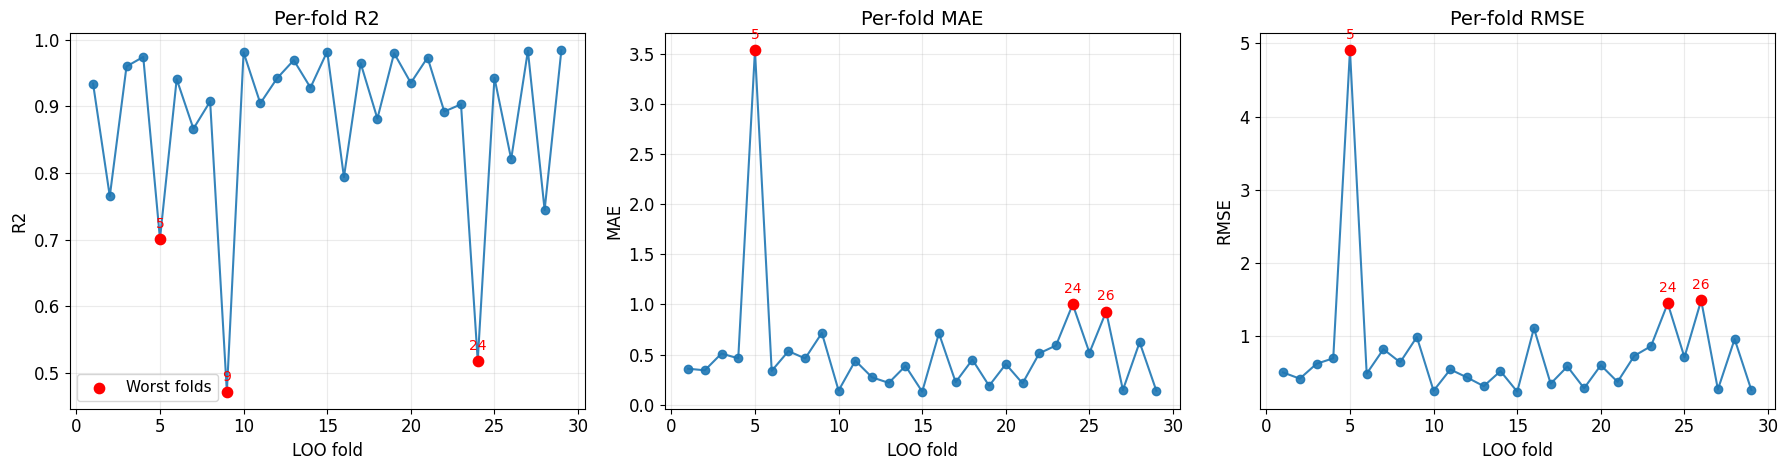


Compact HPO trials (top 10 by inner-CV loss) for selected/anchor aux weight


,trial,value,mean_val_loss,std_val_loss,aux_weight,drop_rate,learning_rate,weight_decay,state
0,29,0.243413,NaN,NaN,0.0,0.10,0.005004,6.888094e-04,TrialState.PRUNED
1,17,0.243768,NaN,NaN,0.0,0.30,0.005972,3.707317e-04,TrialState.PRUNED
2,39,0.265840,NaN,NaN,0.0,0.30,0.005713,1.138108e-05,TrialState.PRUNED
3,34,0.265974,NaN,NaN,0.0,0.00,0.005422,9.317528e-05,TrialState.PRUNED
4,38,0.266088,NaN,NaN,0.0,0.05,0.004043,9.121905e-04,TrialState.PRUNED
5,32,0.271241,NaN,NaN,0.0,0.25,0.002617,1.211071e-05,TrialState.PRUNED
6,18,0.271369,NaN,NaN,0.0,0.10,0.002874,1.071631e-04,TrialState.PRUNED
7,12,0.271575,NaN,NaN,0.0,0.10,0.003214,1.298056e-06,TrialState.PRUNED
8,14,0.271679,NaN,NaN,0.0,0.25,0.002624,5.812574e-07,TrialState.PRUNED
9,31,0.271734,NaN,NaN,0.0,0.30,0.004988,1.180543e-04,TrialState.PRUNED


Pruning/state counts:
state
TrialState.PRUNED      21
TrialState.COMPLETE    19
Name: count, dtype: int64

Context/cap diagnostics (true context magnitude vs c0 value handed to FluxTransformer/pFBA)
  cap supervision mode: latent
  glucose/O2 transformer context mode: measured
   R_EX_glc__D_e_rev (sign=-1) | true med/mean=2.990000/3.570345 | c0/cap med/mean=2.990000/3.570345
       R_EX_o2_e_rev (sign=-1) | true med/mean=7.170000/8.162414 | c0/cap med/mean=7.170000/8.162414
      R_EX_co2_e_fwd (sign=+1) | true med/mean=5.760000/5.546552 | c0/cap med/mean=20.859375/20.814491
         R_EX_etoh_e (sign=+1) | true med/mean=0.000000/0.012759 | c0/cap med/mean=5.418506/18.376926
           R_EX_ac_e (sign=+1) | true med/mean=0.000000/0.083793 | c0/cap med/mean=0.204282/0.229601


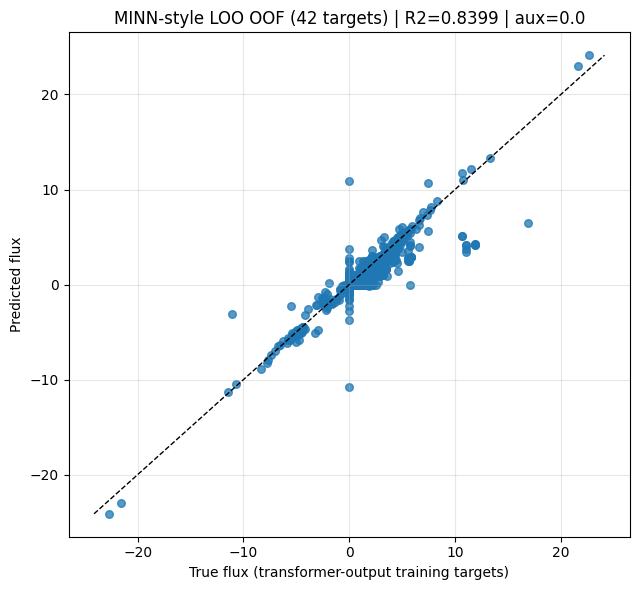

In [22]:
minn_measured_glc_o2_result = run_minn_context_mode_experiment(
    "measured",
    result_key="measured",
    make_canonical=True,
)


### FluxTransformer Reservoir Evaluation: Predicted Glucose/O2 Context

Run the same workflow with the MINN-reservoir-style internal setup where the front MLP predicts all 5 context channels, including glucose and oxygen. Downstream pFBA still uses measured glucose/O2.

c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-06-16 11:40:55,526] A new study created in memory with name: no-name-4c9ad31c-c9e2-4277-b42e-a609f6b1c8a7


################################################################################
Running FluxTransformer reservoir evaluation with MINN_GLC_O2_CONTEXT_MODE='predicted'
Context copied from measured inputs: []
Context predicted by front MLP: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev', 'R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
################################################################################
Running one-time global HPO on full dataset...


[I 2026-06-16 11:45:29,898] Trial 0 finished with value: 0.3166512562271382 and parameters: {'drop_rate': 0.0, 'learning_rate': 0.00240735692233971, 'weight_decay': 0.0006646187643747232}. Best is trial 0 with value: 0.3166512562271382.
[I 2026-06-16 11:52:24,151] Trial 1 finished with value: 0.3336015213719695 and parameters: {'drop_rate': 0.3, 'learning_rate': 0.000511192022543181, 'weight_decay': 3.4058215059092e-08}. Best is trial 0 with value: 0.3166512562271382.
[I 2026-06-16 11:57:39,853] Trial 2 finished with value: 0.30058643865206663 and parameters: {'drop_rate': 0.3, 'learning_rate': 0.0033760282296581598, 'weight_decay': 1.63070964346632e-05}. Best is trial 2 with value: 0.30058643865206663.
[I 2026-06-16 12:03:51,642] Trial 3 finished with value: 0.3105876294637943 and parameters: {'drop_rate': 0.3, 'learning_rate': 0.006890297744542385, 'weight_decay': 2.4230844964083345e-05}. Best is trial 2 with value: 0.30058643865206663.
[I 2026-06-16 12:09:50,629] Trial 4 finished wi

HPO completed for aux_weight=0.0: 40/40 trials attempted (40 completed)
Best hyperparameters after trials: {'drop_rate': 0.3, 'learning_rate': 0.0069108050791978435, 'weight_decay': 1.6071871844970563e-05}
Best inner_cv_objective after trials: 0.286214
Global best_params (anchor aux=0.0): {'drop_rate': 0.3, 'learning_rate': 0.0069108050791978435, 'weight_decay': 1.6071871844970563e-05}
Global inner_cv_objective: 0.286214
MINN-style nested CV training started | aux_weight=0.0
Outer LOO runs: 29
Inner KFold: 5, trials: 40, epochs: 150, batch: 2
Stability objective: mean + 0.25 * std
Grad clip max norm: 1.0 | warmup epochs: 10 | cosine min factor: 0.05
Early stopping: patience=25, min_delta=1e-05
FluxTransformer training target count: 42
Glucose/O2 transformer context mode: predicted
Reservoir context copied from measured inputs: []
Reservoir context predicted by front MLP: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev', 'R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
Cap supervision mode: latent
Au

C:\Users\truok\AppData\Local\Temp\ipykernel_101036\2342949573.py:752: RuntimeWarning: divide by zero encountered in scalar divide
  "NE": float(np.nan_to_num(np.linalg.norm(yt - yp) / np.linalg.norm(yt), posinf=0, neginf=0, nan=0)),
C:\Users\truok\AppData\Local\Temp\ipykernel_101036\2342949573.py:752: RuntimeWarning: divide by zero encountered in scalar divide
  "NE": float(np.nan_to_num(np.linalg.norm(yt - yp) / np.linalg.norm(yt), posinf=0, neginf=0, nan=0)),


...

pFBA aux selection model ready: BIOMASS_Ec_iML1515_core_75p37M

=== Aux-weight comparison: final FluxTransformer->pFBA metrics ===


,aux_weight,n_eval,n_total,pfba_R2_avg,pfba_R2_std,pfba_MAE_avg,pfba_MAE_std,pfba_RMSE_avg,pfba_RMSE_std,pfba_NE_avg,pfba_NE_std
0,0.0,29,29,0.820169,0.127675,0.581289,0.548852,0.974831,0.771906,0.324841,0.116234


Selected by pFBA metrics -> aux_weight=0.0

Selected aux weight for downstream cells: 0.0 | mode= pfba
=== MINN-style nested CV summary (selected) ===
LOO mean R2:   0.931094 +/- 0.098811
LOO mean MAE:  0.353618 +/- 0.280885
LOO mean RMSE: 0.519598 +/- 0.363732
LOO mean NE:   0.206337 +/- 0.115015
Pooled OOF R2:   0.951340
Pooled OOF MAE:  0.353618
Pooled OOF RMSE: 0.630651

Per-LOO validation loss table (selected aux weight)


,epochs_trained,aux_weight,loo_run,sample_idx,val_loss,R2,MAE,RMSE,NE
0,59,0.0,1,0,0.047208,0.974076,0.197149,0.313025,0.145817
1,32,0.0,2,1,0.165799,0.541583,0.433188,0.579065,0.605664
2,30,0.0,3,2,0.102861,0.978121,0.310997,0.455372,0.134814
3,29,0.0,4,3,0.130833,0.983654,0.336462,0.549856,0.117904
4,71,0.0,5,4,1.191785,0.948220,1.573553,2.041654,0.205001
5,64,0.0,6,5,0.110185,0.941264,0.340193,0.480801,0.216480
6,28,0.0,7,6,0.054870,0.976317,0.219628,0.344044,0.139885
7,47,0.0,8,7,0.050304,0.975548,0.209718,0.327590,0.141442
8,45,0.0,9,8,0.279133,0.646277,0.585318,0.805751,0.524911
9,41,0.0,10,9,0.031096,0.980624,0.143449,0.250778,0.127270


Saved per-LOO metric panel plot to pics\minn_loo_metric_panels.png


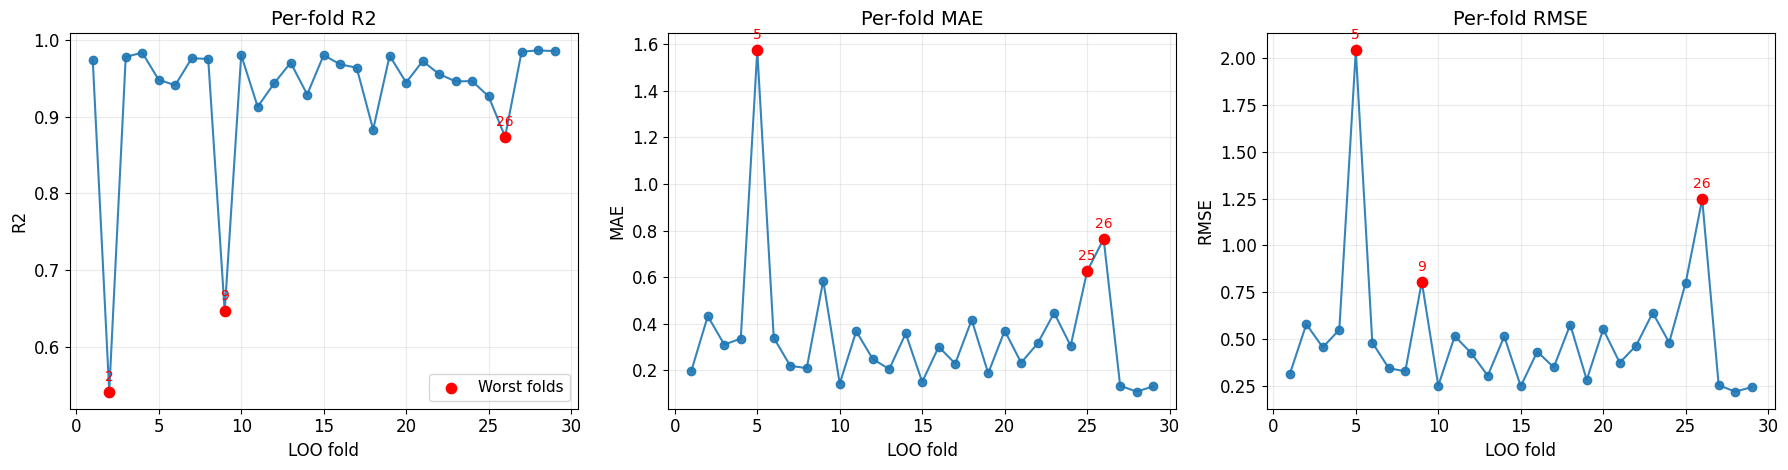


Compact HPO trials (top 10 by inner-CV loss) for selected/anchor aux weight


,trial,value,mean_val_loss,std_val_loss,aux_weight,drop_rate,learning_rate,weight_decay,state
0,25,0.233463,NaN,NaN,0.0,0.30,0.003733,6.295982e-04,TrialState.PRUNED
1,18,0.233692,NaN,NaN,0.0,0.25,0.003424,9.271899e-05,TrialState.PRUNED
2,39,0.234974,NaN,NaN,0.0,0.30,0.004750,3.252420e-08,TrialState.PRUNED
3,10,0.235096,NaN,NaN,0.0,0.25,0.005790,6.944695e-08,TrialState.PRUNED
4,11,0.235604,NaN,NaN,0.0,0.10,0.004076,2.562482e-06,TrialState.PRUNED
5,35,0.235649,NaN,NaN,0.0,0.25,0.004017,1.218023e-06,TrialState.PRUNED
6,30,0.236843,NaN,NaN,0.0,0.00,0.004529,1.069328e-04,TrialState.PRUNED
7,24,0.237511,NaN,NaN,0.0,0.05,0.006363,4.305093e-04,TrialState.PRUNED
8,37,0.238474,NaN,NaN,0.0,0.05,0.000511,1.627852e-07,TrialState.PRUNED
9,29,0.238605,NaN,NaN,0.0,0.10,0.002941,3.027569e-04,TrialState.PRUNED


Pruning/state counts:
state
TrialState.PRUNED      27
TrialState.COMPLETE    13
Name: count, dtype: int64

Context/cap diagnostics (true context magnitude vs c0 value handed to FluxTransformer/pFBA)
  cap supervision mode: latent
  glucose/O2 transformer context mode: predicted
   R_EX_glc__D_e_rev (sign=-1) | true med/mean=2.990000/3.570345 | c0/cap med/mean=3.070926/3.657011
       R_EX_o2_e_rev (sign=-1) | true med/mean=7.170000/8.162414 | c0/cap med/mean=10.968767/12.609775
      R_EX_co2_e_fwd (sign=+1) | true med/mean=5.760000/5.546552 | c0/cap med/mean=13.031252/15.152225
         R_EX_etoh_e (sign=+1) | true med/mean=0.000000/0.012759 | c0/cap med/mean=4.198722/4.640281
           R_EX_ac_e (sign=+1) | true med/mean=0.000000/0.083793 | c0/cap med/mean=0.459688/0.663745


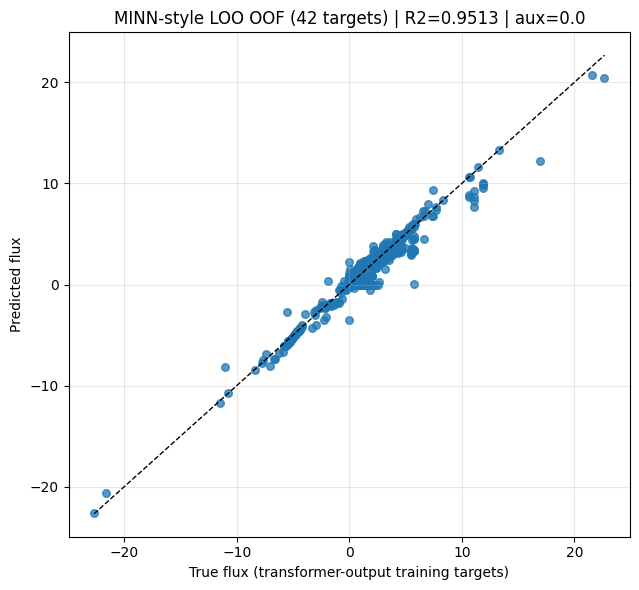

In [23]:
minn_predicted_glc_o2_result = run_minn_context_mode_experiment(
    "predicted",
    result_key="predicted",
    make_canonical=True,
)


### Glucose/O2 Reservoir Context Summary

Summarize the measured-vs-predicted reservoir training runs. The actual Table 4-style FluxTransformer-to-pFBA evaluation below explicitly runs both context modes with the extra-cap mode selected by `MINN_PFBA_EXTRA_CONSTRAINT_MODE`.

In [24]:
if "MINN_CONTEXT_MODE_RESULTS" not in globals() or len(MINN_CONTEXT_MODE_RESULTS) < 2:
    raise RuntimeError("Run both measured and predicted context-mode evaluation cells before comparing.")

comparison_rows = []
for mode_key, res in MINN_CONTEXT_MODE_RESULTS.items():
    best_res_mode = res["best_res"]
    best_aux = float(res["best_aux_weight"])
    pfba_df = res.get("minn_aux_weight_pfba_df", pd.DataFrame())
    pfba_row = pd.DataFrame()
    if isinstance(pfba_df, pd.DataFrame) and not pfba_df.empty and "aux_weight" in pfba_df.columns:
        pfba_row = pfba_df[np.isclose(pfba_df["aux_weight"].astype(float), best_aux)]
        if pfba_row.empty:
            pfba_row = pfba_df.sort_values(
                ["pfba_R2_avg", "pfba_MAE_avg", "pfba_RMSE_avg", "pfba_NE_avg"],
                ascending=[False, True, True, True],
            ).head(1)

    row = {
        "mode": res["mode"],
        "best_aux_weight": best_aux,
        "context_measured_sources": ", ".join(res["context_measured_sources"]),
        "context_predicted_sources": ", ".join(res["context_predicted_sources"]),
        "pooled_R2": float(best_res_mode["pooled_R2"]),
        "pooled_MAE": float(best_res_mode["pooled_MAE"]),
        "pooled_RMSE": float(best_res_mode["pooled_RMSE"]),
        "pooled_NE": float(best_res_mode["pooled_NE"]),
        "loo_mean_R2": float(best_res_mode["loo_mean_R2"]),
        "loo_mean_MAE": float(best_res_mode["loo_mean_MAE"]),
        "loo_mean_RMSE": float(best_res_mode["loo_mean_RMSE"]),
        "loo_mean_NE": float(best_res_mode["loo_mean_NE"]),
        "pfba_R2_avg": np.nan,
        "pfba_MAE_avg": np.nan,
        "pfba_RMSE_avg": np.nan,
        "pfba_NE_avg": np.nan,
        "pfba_n_eval": np.nan,
    }
    if not pfba_row.empty:
        pfba_row0 = pfba_row.iloc[0]
        for col in ["pfba_R2_avg", "pfba_MAE_avg", "pfba_RMSE_avg", "pfba_NE_avg", "n_eval"]:
            if col in pfba_row0.index:
                out_col = "pfba_n_eval" if col == "n_eval" else col
                row[out_col] = float(pfba_row0[col])
    comparison_rows.append(row)

MINN_CONTEXT_MODE_COMPARISON_DF = pd.DataFrame(comparison_rows)
_sort_primary = "pfba_R2_avg" if MINN_CONTEXT_MODE_COMPARISON_DF["pfba_R2_avg"].notna().any() else "pooled_R2"
MINN_CONTEXT_MODE_COMPARISON_DF = MINN_CONTEXT_MODE_COMPARISON_DF.sort_values(
    [_sort_primary, "pooled_R2", "pooled_MAE", "pooled_RMSE"],
    ascending=[False, False, True, True],
).reset_index(drop=True)

print("=== Glucose/O2 FluxTransformer context-mode comparison ===")
print(f"Primary selection metric: {_sort_primary}")
display(MINN_CONTEXT_MODE_COMPARISON_DF)

MINN_SELECTED_GLC_O2_CONTEXT_MODE = str(MINN_CONTEXT_MODE_COMPARISON_DF.iloc[0]["mode"])
_apply_minn_context_mode_result(MINN_CONTEXT_MODE_RESULTS[MINN_SELECTED_GLC_O2_CONTEXT_MODE])
print(f"Reservoir summary selected context mode: {MINN_SELECTED_GLC_O2_CONTEXT_MODE} (FluxTransformer-to-pFBA cells below override this explicitly)")


=== Glucose/O2 FluxTransformer context-mode comparison ===
Primary selection metric: pfba_R2_avg


,mode,best_aux_weight,context_measured_sources,context_predicted_sources,pooled_R2,pooled_MAE,pooled_RMSE,pooled_NE,loo_mean_R2,loo_mean_MAE,loo_mean_RMSE,loo_mean_NE,pfba_R2_avg,pfba_MAE_avg,pfba_RMSE_avg,pfba_NE_avg,pfba_n_eval
0,measured,0.0,"R_EX_glc__D_e_rev, R_EX_o2_e_rev","R_EX_co2_e_fwd, R_EX_etoh_e, R_EX_ac_e",0.839869,0.534582,1.144041,0.372086,0.880725,0.534582,0.770175,0.275686,0.829120,0.569896,0.956793,0.317502,29.0
1,predicted,0.0,,"R_EX_glc__D_e_rev, R_EX_o2_e_rev, R_EX_co2_e_f...",0.951340,0.353618,0.630651,0.205112,0.931094,0.353618,0.519598,0.206337,0.820169,0.581289,0.974831,0.324841,29.0


Reservoir summary selected context mode: measured (FluxTransformer-to-pFBA cells below override this explicitly)


### Baseline pFBA

This cell computes the baseline row for the MINN article Table 4-style comparison adapted to FluxTransformer. It runs pFBA on the unsplit, unpruned iML1515 model using only the measured medium inputs available for every sample: glucose uptake (`R_EX_glc__D_e_rev`) and oxygen uptake (`R_EX_o2_e_rev`).

No reservoir-predicted constraints are added here. The resulting metrics are the reference point for the next FluxTransformer + pFBA cell, where the current comparison variant adds predicted secretion upper caps.

Metrics are computed per sample across the mapped measured fluxes, then summarized as mean and standard deviation across samples: R2, MAE, RMSE, and NE.


In [25]:
# Baseline pFBA (paper-style metrics), without FluxTransformer to pFBA
# Uses ONLY measured glucose and oxygen uptake as inputs.

from pathlib import Path

try:
    from cobra.io import read_sbml_model
    from cobra.flux_analysis import pfba as cobra_pfba
except Exception as e:
    raise ImportError(
        "cobra is required for pFBA baseline evaluation. Install cobra in the notebook environment."
    ) from e

fluxomics_path = Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE
if not fluxomics_path.exists():
    raise FileNotFoundError(f"Fluxomics file not found: {fluxomics_path}")

flux_df = pd.read_csv(fluxomics_path)

# pFBA objective is fixed to iML1515 core biomass for this notebook.
PFBA_OBJECTIVE_VARIANT = "core"
PFBA_OBJECTIVE_RXN = "BIOMASS_Ec_iML1515_core_75p37M"
PFBA_BIOMASS_METRIC_TOKEN = f"{PFBA_OBJECTIVE_RXN}_flux"

# Paper-style evaluation flux set: all measured fluxomics columns (exclude experiment id).
metric_source_cols = [c for c in flux_df.columns if c != "experiment"]

# Map MINN split-naming columns into iML1515 FluxTransformer token naming (+ sign conversion).
mapped_metrics = []  # (source_col, token_name, sign)
for src in metric_source_cols:
    tok, sign = _minn_to_flux_token(src, outputs)
    if src.startswith("R_BIOMASS") and PFBA_BIOMASS_METRIC_TOKEN in outputs:
        tok, sign = PFBA_BIOMASS_METRIC_TOKEN, 1.0
    if tok is not None:
        mapped_metrics.append((src, tok, float(sign)))

if not mapped_metrics:
    raise RuntimeError("No metric flux columns could be mapped to iML1515 token space.")
assert not any("WT_75p37M" in tok for _src, tok, _sign in mapped_metrics), "pFBA metric targets unexpectedly use WT biomass."

metric_map_df = pd.DataFrame(mapped_metrics, columns=["source_flux", "mapped_token", "sign_to_iML1515"])

BASELINE_PFBA_INPUT_COLS = ["R_EX_glc__D_e_rev", "R_EX_o2_e_rev"]
FLUXTRANSFORMER_PFBA_PRED_COLS = list(MINN_PFBA_PRED_COL_BY_SOURCE.values())

# Baseline pFBA uses only these two measured uptake columns as pFBA inputs.
for c in BASELINE_PFBA_INPUT_COLS:
    if c not in flux_df.columns:
        raise ValueError(f"Required pFBA input column missing in fluxomics file: {c}")
leaked_pred_cols = [c for c in FLUXTRANSFORMER_PFBA_PRED_COLS if c in flux_df.columns]
assert not leaked_pred_cols, "Baseline pFBA input table unexpectedly contains FluxTransformer prediction columns: " + ", ".join(leaked_pred_cols)

pfba_baseline_input_df = flux_df[["experiment"] + BASELINE_PFBA_INPUT_COLS].copy()
print("Baseline pFBA input columns:", BASELINE_PFBA_INPUT_COLS)
print("FluxTransformer predictions used in baseline pFBA: False")

model_path = Path("./models/iML1515.xml")
if not model_path.exists():
    raise FileNotFoundError(f"SBML model not found: {model_path}")

base_cobra_model = read_sbml_model(str(model_path))
try:
    base_cobra_model.objective = PFBA_OBJECTIVE_RXN
except KeyError as e:
    raise KeyError(f"Expected pFBA objective reaction in iML1515 model: {PFBA_OBJECTIVE_RXN}") from e
print(f"iML1515 pFBA objective: {PFBA_OBJECTIVE_RXN}")

def _metric_row(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    # Same spirit as MINN paper implementation: per-sample r^2 across fluxes.
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        R2 = 0.0
    else:
        r = np.corrcoef(y_true, y_pred)[0, 1]
        R2 = 0.0 if np.isnan(r) else float(r * r)

    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    ne = float(np.nan_to_num(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true), posinf=0.0, neginf=0.0, nan=0.0))
    return R2, mae, rmse, ne

pred_rows = []
metric_rows = []
failed_samples = []

for _, row in flux_df.iterrows():
    exp_name = row["experiment"]

    # Baseline pFBA: only measured glucose and oxygen uptake are injected.
    glc_uptake = float(row["R_EX_glc__D_e_rev"])  # positive uptake magnitude in MINN split data
    o2_uptake = float(row["R_EX_o2_e_rev"])

    m = base_cobra_model.copy()
    try:
        m.reactions.get_by_id("EX_glc__D_e").lower_bound = -glc_uptake
        m.reactions.get_by_id("EX_o2_e").lower_bound = -o2_uptake
    except KeyError as e:
        raise KeyError("Expected EX_glc__D_e and EX_o2_e reactions in iML1515 model.") from e

    try:
        sol = cobra_pfba(m)
        sol_status = getattr(sol, "status", "optimal")
        if sol_status != "optimal":
            raise RuntimeError(f"pFBA status={sol_status}")
    except Exception as e:
        failed_samples.append((exp_name, str(e)))
        continue

    y_true = []
    y_pred = []
    pred_row = {"experiment": exp_name}

    for src, tok, sign in mapped_metrics:
        rxn_id = tok[:-5] if tok.endswith("_flux") else tok
        pred_val = float(sol.fluxes.get(rxn_id, 0.0)) * sign
        true_val = float(row[src])

        y_true.append(true_val)
        y_pred.append(pred_val)
        pred_row[src] = pred_val

    R2, mae, rmse, ne = _metric_row(y_true, y_pred)
    metric_rows.append({
        "experiment": exp_name,
        "R2": R2,
        "MAE": mae,
        "RMSE": rmse,
        "NE": ne,
    })
    pred_rows.append(pred_row)

pfba_baseline_pred_df = pd.DataFrame(pred_rows)
pfba_baseline_metrics_per_sample_df = pd.DataFrame(metric_rows)

if pfba_baseline_metrics_per_sample_df.empty:
    raise RuntimeError("No successful pFBA samples. Check model feasibility and constraints.")

# Paper-style summary: mean +/- std across samples (population std, like np.std default).
pfba_baseline_summary_df = pd.DataFrame({
    "avg": [
        float(pfba_baseline_metrics_per_sample_df["R2"].mean()),
        float(pfba_baseline_metrics_per_sample_df["MAE"].mean()),
        float(pfba_baseline_metrics_per_sample_df["RMSE"].mean()),
        float(pfba_baseline_metrics_per_sample_df["NE"].mean()),
    ],
    "std": [
        float(pfba_baseline_metrics_per_sample_df["R2"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["MAE"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["RMSE"].std(ddof=0)),
        float(pfba_baseline_metrics_per_sample_df["NE"].std(ddof=0)),
    ],
}, index=["R2", "MAE", "RMSE", "NE"])

print("=== Baseline pFBA summary (without FluxTransformer to pFBA) ===")
print(f"Samples evaluated: {len(pfba_baseline_metrics_per_sample_df)}/{len(flux_df)}")
print(f"Metric fluxes mapped: {len(mapped_metrics)} / {len(metric_source_cols)}")
if failed_samples:
    print(f"Failed samples: {len(failed_samples)}")
    for exp_name, msg in failed_samples[:5]:
        print(f"  - {exp_name}: {msg}")

display(pfba_baseline_summary_df)
display(metric_map_df.head(10))



Baseline pFBA input columns: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev']
FluxTransformer predictions used in baseline pFBA: False
iML1515 pFBA objective: BIOMASS_Ec_iML1515_core_75p37M
=== Baseline pFBA summary (without FluxTransformer to pFBA) ===
Samples evaluated: 29/29
Metric fluxes mapped: 47 / 47


,avg,std
R2,0.758239,0.199449
MAE,0.672460,0.652862
RMSE,1.130943,1.012816
NE,0.374178,0.166116


,source_flux,mapped_token,sign_to_iML1515
0,R_GLCptspp,GLCptspp_flux,1.0
1,R_PGI_fwd,PGI_flux,1.0
2,R_PFK,PFK_flux,1.0
3,R_FBA_fwd,FBA_flux,1.0
4,R_TPI_fwd,TPI_flux,1.0
5,R_PGK_rev,PGK_flux,-1.0
6,R_GAPD_fwd,GAPD_flux,1.0
7,R_ENO_fwd,ENO_flux,1.0
8,R_PGM_rev,PGM_flux,-1.0
9,R_PYK,PYK_flux,1.0


### FluxTransformer to pFBA: Measured vs Predicted Context

This section adapts the MINN article Table 4 comparison to the FluxTransformer reservoir setup. The actual FluxTransformer-to-pFBA evaluation is split into two run cells:

- measured glucose/O2 FluxTransformer context
- predicted glucose/O2 FluxTransformer context

Both pFBA run cells use the extra predicted secretion caps selected by `MINN_PFBA_EXTRA_CONSTRAINT_MODE`: `etoh_ac_cap` uses ethanol and acetate only, leaving CO2 uncapped downstream; `co2_etoh_ac_cap` uses CO2, ethanol, and acetate. Glucose and oxygen pFBA constraints remain measured uptake lower-bound caps in both runs.

The first comparison cell reports pFBA baseline metrics beside the measured-context and predicted-context FluxTransformer-to-pFBA variants for the selected cap mode. A follow-up cell can then retrain the better glucose/O2 context mode with `etoh_ac_cap`, keeping CO2 in the FluxTransformer input but leaving it uncapped in downstream pFBA.


In [26]:
# FluxTransformer to pFBA reusable evaluator.
# The run cells below evaluate measured and predicted glucose/O2 context separately.

from pathlib import Path

def _get_minn_pfba_extra_constraint_sources(extra_constraint_mode):
    if extra_constraint_mode not in MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE:
        raise ValueError(
            f"Unknown pFBA extra-constraint mode {extra_constraint_mode!r}. "
            f"Expected one of {sorted(MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE)}."
        )
    return list(MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE[extra_constraint_mode])


def _apply_minn_fluxtransformer_pfba_result(run_result):
    """Restore one FluxTransformer-to-pFBA run as the canonical downstream state."""
    context_mode = str(run_result["context_mode"]).lower().strip()
    context_result_key = str(run_result.get("context_result_key", context_mode)).lower().strip()
    if "MINN_CONTEXT_MODE_RESULTS" in globals():
        if context_result_key in MINN_CONTEXT_MODE_RESULTS:
            _apply_minn_context_mode_result(MINN_CONTEXT_MODE_RESULTS[context_result_key])
        elif context_mode in MINN_CONTEXT_MODE_RESULTS:
            _apply_minn_context_mode_result(MINN_CONTEXT_MODE_RESULTS[context_mode])

    globals().update({
        "MINN_PFBA_EXTRA_CONSTRAINT_MODE": run_result["extra_constraint_mode"],
        "MINN_PFBA_EXTRA_CONSTRAINT_SOURCE": list(run_result["extra_constraint_sources"]),
        "pred_vin_df": run_result["pred_vin_df"],
        "flux_df_eval": run_result["flux_df_eval"],
        "pfba_extra_constraint_diagnostics_df": run_result["pfba_extra_constraint_diagnostics_df"],
        "pfba_cap_binding_diagnostics_df": run_result.get("pfba_cap_binding_diagnostics_df"),
        "pfba_cap_binding_sample_summary_df": run_result.get("pfba_cap_binding_sample_summary_df"),
        "pfba_cap_binding_result_summary_df": run_result.get("pfba_cap_binding_result_summary_df"),
        "minn_pfba_pred_df": run_result["minn_pfba_pred_df"],
        "minn_pfba_metrics_per_sample_df": run_result["minn_pfba_metrics_per_sample_df"],
        "minn_pfba_summary_df": run_result["minn_pfba_summary_df"],
        "failed_samples_minn_pfba": run_result["failed_samples_minn_pfba"],
        "pfba_prediction_diff_df": run_result["pfba_prediction_diff_df"],
        "max_abs_pfba_prediction_diff": run_result["max_abs_pfba_prediction_diff"],
        "comparison_df": run_result["comparison_df"],
        "MINN_SELECTED_FLUXTRANSFORMER_PFBA_CONTEXT_MODE": context_mode,
        "MINN_SELECTED_FLUXTRANSFORMER_PFBA_RESULT_KEY": run_result["result_key"],
    })
    return run_result


def _build_pfba_cap_binding_diagnostics(
    result_key,
    context_mode,
    extra_constraint_mode,
    extra_sources,
    pred_vin_df,
    flux_df_eval,
    minn_pfba_pred_df,
    minn_pfba_metrics_per_sample_df,
    baseline_pred_df=None,
    tol=None,
):
    """Build cap-level and sample-level diagnostics for FluxTransformer-to-pFBA runs."""
    tol = float(PFBA_EXTRA_CONSTRAINT_TOL if tol is None else tol)
    label_by_source = {
        "R_EX_co2_e_fwd": "CO2",
        "R_EX_etoh_e": "ethanol",
        "R_EX_ac_e": "acetate",
    }
    extra_sources = list(extra_sources)
    if not extra_sources:
        empty = pd.DataFrame()
        return empty, empty, empty

    required_pred_cols = [MINN_PFBA_PRED_COL_BY_SOURCE[src] for src in extra_sources]
    missing_pred_cols = [c for c in required_pred_cols if c not in pred_vin_df.columns]
    missing_target_cols = [src for src in extra_sources if src not in flux_df_eval.columns]
    missing_pfba_cols = [src for src in extra_sources if src not in minn_pfba_pred_df.columns]
    if missing_pred_cols or missing_target_cols or missing_pfba_cols:
        raise KeyError(
            "Cannot build cap-binding diagnostics. Missing columns: "
            f"pred={missing_pred_cols}, target={missing_target_cols}, pfba={missing_pfba_cols}"
        )

    target_df = flux_df_eval[["experiment"] + extra_sources].rename(
        columns={src: f"{src}__target" for src in extra_sources}
    )
    solved_df = minn_pfba_pred_df[["experiment"] + extra_sources].rename(
        columns={src: f"{src}__pfba" for src in extra_sources}
    )
    merged = pred_vin_df[["experiment"] + required_pred_cols].merge(target_df, on="experiment", how="inner")
    merged = merged.merge(solved_df, on="experiment", how="inner")

    baseline_available = (
        baseline_pred_df is not None
        and all(src in baseline_pred_df.columns for src in extra_sources)
        and "experiment" in baseline_pred_df.columns
    )
    if baseline_available:
        baseline_df = baseline_pred_df[["experiment"] + extra_sources].rename(
            columns={src: f"{src}__baseline" for src in extra_sources}
        )
        merged = merged.merge(baseline_df, on="experiment", how="left")

    cap_rows = []
    for src in extra_sources:
        pred_col = MINN_PFBA_PRED_COL_BY_SOURCE[src]
        for _, row in merged.iterrows():
            cap_pred = float(row[pred_col])
            target_flux = float(row[f"{src}__target"])
            pfba_flux = float(row[f"{src}__pfba"])
            baseline_flux = (
                float(row[f"{src}__baseline"])
                if baseline_available and pd.notna(row.get(f"{src}__baseline", np.nan))
                else np.nan
            )
            cap_error = cap_pred - target_flux
            final_error = pfba_flux - target_flux
            baseline_error = baseline_flux - target_flux if np.isfinite(baseline_flux) else np.nan
            cap_slack = cap_pred - pfba_flux
            cap_binding = bool(abs(cap_slack) <= tol)
            cap_too_low = bool(cap_pred < target_flux - tol)
            cap_too_high = bool(cap_pred > target_flux + tol)
            binding_low_cap = bool(cap_binding and cap_too_low)
            binding_high_cap = bool(cap_binding and cap_too_high)
            nonbinding_bad_final = bool((not cap_binding) and abs(final_error) > tol)
            cap_improvement_abs_delta = (
                abs(baseline_error) - abs(final_error)
                if np.isfinite(baseline_error)
                else np.nan
            )
            cap_helped_vs_baseline = bool(np.isfinite(cap_improvement_abs_delta) and cap_improvement_abs_delta > tol)
            cap_worsened_vs_baseline = bool(np.isfinite(cap_improvement_abs_delta) and cap_improvement_abs_delta < -tol)

            if binding_low_cap:
                diagnosis = "binding low cap: possible overconstraint"
            elif binding_high_cap and abs(final_error) > tol:
                diagnosis = "binding high cap: cap permits high secretion"
            elif nonbinding_bad_final:
                diagnosis = "nonbinding: pFBA/objective or other constraints"
            elif abs(cap_error) > tol and not cap_binding:
                diagnosis = "cap prediction off but nonbinding"
            elif abs(final_error) <= tol:
                diagnosis = "cap target matched"
            else:
                diagnosis = "mixed"

            cap_rows.append({
                "result_key": result_key,
                "context_mode": context_mode,
                "extra_constraint_mode": extra_constraint_mode,
                "experiment": row["experiment"],
                "source": src,
                "source_label": label_by_source.get(src, src),
                "cap_pred": cap_pred,
                "target_flux": target_flux,
                "pfba_flux": pfba_flux,
                "baseline_flux": baseline_flux,
                "cap_error": cap_error,
                "abs_cap_error": abs(cap_error),
                "final_error": final_error,
                "abs_final_error": abs(final_error),
                "baseline_error": baseline_error,
                "abs_baseline_error": abs(baseline_error) if np.isfinite(baseline_error) else np.nan,
                "cap_slack": cap_slack,
                "abs_cap_slack": abs(cap_slack),
                "cap_binding": cap_binding,
                "cap_too_low": cap_too_low,
                "cap_too_high": cap_too_high,
                "binding_low_cap": binding_low_cap,
                "binding_high_cap": binding_high_cap,
                "nonbinding_bad_final": nonbinding_bad_final,
                "cap_improvement_abs_delta": cap_improvement_abs_delta,
                "cap_worsening_abs_delta": -cap_improvement_abs_delta if np.isfinite(cap_improvement_abs_delta) else np.nan,
                "cap_helped_vs_baseline": cap_helped_vs_baseline,
                "cap_worsened_vs_baseline": cap_worsened_vs_baseline,
                "diagnosis": diagnosis,
            })

    cap_df = pd.DataFrame(cap_rows)
    if cap_df.empty:
        empty = pd.DataFrame()
        return cap_df, empty, empty

    grouped = cap_df.groupby(["result_key", "context_mode", "extra_constraint_mode", "experiment"], as_index=False)
    sample_summary = grouped.agg(
        n_caps=("source", "size"),
        cap_binding_count=("cap_binding", "sum"),
        binding_low_cap_count=("binding_low_cap", "sum"),
        binding_high_cap_count=("binding_high_cap", "sum"),
        nonbinding_bad_final_count=("nonbinding_bad_final", "sum"),
        cap_helped_count=("cap_helped_vs_baseline", "sum"),
        cap_worsened_count=("cap_worsened_vs_baseline", "sum"),
        mean_abs_cap_error=("abs_cap_error", "mean"),
        max_abs_cap_error=("abs_cap_error", "max"),
        mean_abs_final_cap_error=("abs_final_error", "mean"),
        max_abs_final_cap_error=("abs_final_error", "max"),
        mean_abs_baseline_cap_error=("abs_baseline_error", "mean"),
        max_abs_baseline_cap_error=("abs_baseline_error", "max"),
        mean_abs_cap_slack=("abs_cap_slack", "mean"),
    )

    if minn_pfba_metrics_per_sample_df is not None and not minn_pfba_metrics_per_sample_df.empty:
        metric_cols = [c for c in ["experiment", "R2", "MAE", "RMSE", "NE"] if c in minn_pfba_metrics_per_sample_df.columns]
        sample_summary = sample_summary.merge(
            minn_pfba_metrics_per_sample_df[metric_cols],
            on="experiment",
            how="left",
        )

    def _sample_diagnosis(row):
        if int(row.get("binding_low_cap_count", 0)) > 0:
            return "cap overconstraint possible"
        if int(row.get("cap_worsened_count", 0)) > int(row.get("cap_helped_count", 0)):
            return "caps worsened versus baseline"
        if int(row.get("nonbinding_bad_final_count", 0)) > 0:
            return "bad cap-target error is nonbinding"
        if float(row.get("max_abs_cap_error", 0.0)) > tol:
            return "reservoir cap prediction differs"
        return "no obvious cap issue"

    sample_summary["cap_binding_diagnosis"] = sample_summary.apply(_sample_diagnosis, axis=1)

    result_summary = cap_df.groupby(["result_key", "context_mode", "extra_constraint_mode"], as_index=False).agg(
        cap_rows=("source", "size"),
        binding_rows=("cap_binding", "sum"),
        binding_low_cap_rows=("binding_low_cap", "sum"),
        binding_high_cap_rows=("binding_high_cap", "sum"),
        nonbinding_bad_final_rows=("nonbinding_bad_final", "sum"),
        cap_helped_rows=("cap_helped_vs_baseline", "sum"),
        cap_worsened_rows=("cap_worsened_vs_baseline", "sum"),
        mean_abs_cap_error=("abs_cap_error", "mean"),
        mean_abs_final_cap_error=("abs_final_error", "mean"),
        mean_abs_baseline_cap_error=("abs_baseline_error", "mean"),
    )

    return cap_df, sample_summary, result_summary


def run_fluxtransformer_to_pfba_context_mode(
    context_mode,
    extra_constraint_mode=None,
    result_key=None,
    make_canonical=True,
    context_result_key=None,
):
    """Run Table 4-style FluxTransformer-to-pFBA for one glucose/O2 context mode."""
    context_mode = str(context_mode).lower().strip()
    if extra_constraint_mode is None:
        extra_constraint_mode = MINN_PFBA_EXTRA_CONSTRAINT_MODE
    extra_constraint_mode = str(extra_constraint_mode).lower().strip()
    extra_sources = _get_minn_pfba_extra_constraint_sources(extra_constraint_mode)
    result_key = str(result_key or f"{context_mode}_{extra_constraint_mode}")
    context_result_key = str(context_result_key or context_mode).lower().strip()

    if "MINN_CONTEXT_MODE_RESULTS" not in globals() or context_result_key not in MINN_CONTEXT_MODE_RESULTS:
        raise RuntimeError(
            f"Run the stored reservoir evaluation {context_result_key!r} before FluxTransformer-to-pFBA."
        )
    if "_apply_minn_context_mode_result" not in globals():
        raise RuntimeError("Missing _apply_minn_context_mode_result. Re-run the reservoir training setup cells.")
    if "base_cobra_model" not in globals() or "cobra_pfba" not in globals():
        raise RuntimeError("Run the baseline pFBA cell before FluxTransformer-to-pFBA.")
    if "oof_pred_constraints" not in MINN_CONTEXT_MODE_RESULTS[context_result_key].get("canonical", {}):
        raise RuntimeError(f"Stored context-mode result {context_result_key!r} has no OOF constraints.")

    _apply_minn_context_mode_result(MINN_CONTEXT_MODE_RESULTS[context_result_key])

    print(
        f"Running FluxTransformer-to-pFBA with glucose/O2 context mode={context_mode!r} "
        f"and extra_constraint_mode={extra_constraint_mode!r}"
    )
    print("pFBA glucose/O2 source: measured uptake columns")
    print("pFBA extra predicted constraints:", extra_sources)

    tr_df = pd.read_csv(Path(MINN_DATA_DIR) / "transcriptomics.csv")
    pr_df = pd.read_csv(Path(MINN_DATA_DIR) / "proteomics.csv")
    fl_df = pd.read_csv(Path(MINN_DATA_DIR) / MINN_FLUXOMICS_FILE)

    if "PFBA_EXTRA_CONSTRAINT_TOL" not in globals():
        globals()["PFBA_EXTRA_CONSTRAINT_TOL"] = 1e-6

    x_df_tmp = tr_df.merge(pr_df, on="experiment", how="left")
    x_df_tmp = x_df_tmp.merge(fl_df[["experiment"] + MINN_INPUT_FLUX_COLS], on="experiment", how="left")
    x_df_tmp = x_df_tmp[x_df_tmp["experiment"].isin(fl_df["experiment"])].reset_index(drop=True)
    exp_order_oof = x_df_tmp["experiment"].tolist()

    if len(exp_order_oof) != oof_pred_constraints.shape[0]:
        raise RuntimeError(
            f"Experiment/OOF length mismatch: {len(exp_order_oof)} vs {oof_pred_constraints.shape[0]}."
        )
    if oof_pred_constraints.shape[1] != len(MINN_RESERVOIR_CONTEXT_SOURCE):
        raise RuntimeError(
            f"Expected {len(MINN_RESERVOIR_CONTEXT_SOURCE)} reservoir-context predictions in oof_pred_constraints, "
            f"got {oof_pred_constraints.shape[1]}. Re-run the MINN training cell after updating the reservoir setup."
        )

    src_to_idx = {s: i for i, s in enumerate(MINN_RESERVOIR_CONTEXT_SOURCE)}
    for s in extra_sources:
        if s not in src_to_idx:
            raise ValueError(f"Missing expected learned source in MINN_RESERVOIR_CONTEXT_SOURCE: {s}")

    pred_vin_data = {"experiment": exp_order_oof}
    for src in extra_sources:
        pred_col = MINN_PFBA_PRED_COL_BY_SOURCE[src]
        pred_vin_data[pred_col] = np.maximum(0.0, oof_pred_constraints[:, src_to_idx[src]])
    pred_vin_df = pd.DataFrame(pred_vin_data)

    pfba_extra_constraint_diagnostics_df = None
    if "pfba_baseline_pred_df" in globals():
        baseline_extra_cols = list(extra_sources)
        baseline_extra_available = [c for c in baseline_extra_cols if c in pfba_baseline_pred_df.columns]
        if len(baseline_extra_available) == len(baseline_extra_cols):
            pfba_extra_constraint_diagnostics_df = pred_vin_df.merge(
                pfba_baseline_pred_df[["experiment"] + baseline_extra_cols],
                on="experiment",
                how="left",
            )
            print(f"FluxTransformer pFBA extra-constraint mode: {extra_constraint_mode}")
            print("Predicted pFBA extra constraints vs baseline pFBA solution:")
            label_by_source = {
                "R_EX_co2_e_fwd": "CO2",
                "R_EX_etoh_e": "ethanol",
                "R_EX_ac_e": "acetate",
            }
            for src in baseline_extra_cols:
                pred_col = MINN_PFBA_PRED_COL_BY_SOURCE[src]
                diff_col = f"{src}_pred_minus_baseline"
                pfba_extra_constraint_diagnostics_df[diff_col] = (
                    pfba_extra_constraint_diagnostics_df[pred_col] - pfba_extra_constraint_diagnostics_df[src]
                )
                abs_delta = pfba_extra_constraint_diagnostics_df[diff_col].abs()
                n_changed = int((abs_delta > PFBA_EXTRA_CONSTRAINT_TOL).sum())
                print(
                    f"  {label_by_source[src]}: {n_changed}/{len(pfba_extra_constraint_diagnostics_df)} "
                    f"predicted values differ from baseline pFBA flux; max abs delta={float(abs_delta.max()):.6g}"
                )

    flux_df_eval = fl_df.merge(pred_vin_df, on="experiment", how="inner")
    if flux_df_eval.empty:
        raise RuntimeError("Empty merged dataframe for FluxTransformer to pFBA evaluation.")

    if "mapped_metrics" not in globals() or not mapped_metrics:
        metric_source_cols = [c for c in fl_df.columns if c != "experiment"]
        mapped_metrics_local = []
        for src in metric_source_cols:
            tok, sign = _minn_to_flux_token(src, outputs)
            if src.startswith("R_BIOMASS") and "PFBA_BIOMASS_METRIC_TOKEN" in globals() and PFBA_BIOMASS_METRIC_TOKEN in outputs:
                tok, sign = PFBA_BIOMASS_METRIC_TOKEN, 1.0
            if tok is not None:
                mapped_metrics_local.append((src, tok, float(sign)))
        globals()["mapped_metrics"] = mapped_metrics_local

    if not mapped_metrics:
        raise RuntimeError("No mapped metrics available for FluxTransformer to pFBA evaluation.")

    metric_row_fn = globals().get("_metric_row")
    if metric_row_fn is None:
        def metric_row_fn(y_true, y_pred):
            y_true = np.asarray(y_true, dtype=np.float64)
            y_pred = np.asarray(y_pred, dtype=np.float64)
            if np.std(y_true) == 0 or np.std(y_pred) == 0:
                R2 = 0.0
            else:
                r = np.corrcoef(y_true, y_pred)[0, 1]
                R2 = 0.0 if np.isnan(r) else float(r * r)
            mae = float(np.mean(np.abs(y_true - y_pred)))
            rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
            ne = float(np.nan_to_num(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true), posinf=0.0, neginf=0.0, nan=0.0))
            return R2, mae, rmse, ne
        globals()["_metric_row"] = metric_row_fn

    def _set_nonnegative_exchange_upper_cap(rxn, value):
        cap = max(0.0, float(value))
        rxn.lower_bound = max(0.0, min(float(rxn.lower_bound), cap))
        rxn.upper_bound = cap

    pred_rows_minn_pfba = []
    metric_rows_minn_pfba = []
    failed_samples_minn_pfba = []

    for _, row in flux_df_eval.iterrows():
        exp_name = row["experiment"]

        glc_uptake_meas = float(row["R_EX_glc__D_e_rev"])
        o2_uptake_meas = float(row["R_EX_o2_e_rev"])

        m = base_cobra_model.copy()
        try:
            m.reactions.get_by_id("EX_glc__D_e").lower_bound = -glc_uptake_meas
            m.reactions.get_by_id("EX_o2_e").lower_bound = -o2_uptake_meas

            for src in extra_sources:
                pred_value = float(row[MINN_PFBA_PRED_COL_BY_SOURCE[src]])
                rxn = m.reactions.get_by_id(MINN_PFBA_RXN_BY_SOURCE[src])
                _set_nonnegative_exchange_upper_cap(rxn, pred_value)
        except KeyError as e:
            raise KeyError("Expected measured-input and selected extra-constraint reactions in iML1515 model.") from e

        try:
            sol = cobra_pfba(m)
            sol_status = getattr(sol, "status", "optimal")
            if sol_status != "optimal":
                raise RuntimeError(f"pFBA status={sol_status}")
        except Exception as e:
            failed_samples_minn_pfba.append((exp_name, str(e)))
            continue

        y_true = []
        y_pred = []
        pred_row = {"experiment": exp_name}
        for src, tok, sign in mapped_metrics:
            rxn_id = tok[:-5] if tok.endswith("_flux") else tok
            pred_val = float(sol.fluxes.get(rxn_id, 0.0)) * sign
            true_val = float(row[src])
            y_true.append(true_val)
            y_pred.append(pred_val)
            pred_row[src] = pred_val

        R2, mae, rmse, ne = metric_row_fn(y_true, y_pred)
        metric_rows_minn_pfba.append({
            "experiment": exp_name,
            "R2": R2,
            "MAE": mae,
            "RMSE": rmse,
            "NE": ne,
        })
        pred_rows_minn_pfba.append(pred_row)

    minn_pfba_pred_df = pd.DataFrame(pred_rows_minn_pfba)
    minn_pfba_metrics_per_sample_df = pd.DataFrame(metric_rows_minn_pfba)

    if minn_pfba_metrics_per_sample_df.empty:
        raise RuntimeError("No successful FluxTransformer to pFBA samples. Check constraint feasibility.")

    minn_pfba_summary_df = pd.DataFrame({
        "avg": [
            float(minn_pfba_metrics_per_sample_df["R2"].mean()),
            float(minn_pfba_metrics_per_sample_df["MAE"].mean()),
            float(minn_pfba_metrics_per_sample_df["RMSE"].mean()),
            float(minn_pfba_metrics_per_sample_df["NE"].mean()),
        ],
        "std": [
            float(minn_pfba_metrics_per_sample_df["R2"].std(ddof=0)),
            float(minn_pfba_metrics_per_sample_df["MAE"].std(ddof=0)),
            float(minn_pfba_metrics_per_sample_df["RMSE"].std(ddof=0)),
            float(minn_pfba_metrics_per_sample_df["NE"].std(ddof=0)),
        ],
    }, index=["R2", "MAE", "RMSE", "NE"])

    pfba_prediction_diff_df = None
    max_abs_pfba_prediction_diff = None
    if "pfba_baseline_pred_df" in globals():
        common_experiments = sorted(set(pfba_baseline_pred_df["experiment"]).intersection(minn_pfba_pred_df["experiment"]))
        common_pred_cols = [
            c for c in minn_pfba_pred_df.columns
            if c != "experiment" and c in pfba_baseline_pred_df.columns
        ]
        if common_experiments and common_pred_cols:
            base_cmp_pred = pfba_baseline_pred_df.set_index("experiment").loc[common_experiments, common_pred_cols]
            ft_cmp_pred = minn_pfba_pred_df.set_index("experiment").loc[common_experiments, common_pred_cols]
            pfba_prediction_diff_df = (ft_cmp_pred - base_cmp_pred).reset_index()
            max_abs_pfba_prediction_diff = float((ft_cmp_pred - base_cmp_pred).abs().to_numpy().max())
            print(f"Max abs prediction difference vs baseline pFBA: {max_abs_pfba_prediction_diff:.6g}")

    pfba_cap_binding_diagnostics_df, pfba_cap_binding_sample_summary_df, pfba_cap_binding_result_summary_df = (
        _build_pfba_cap_binding_diagnostics(
            result_key=result_key,
            context_mode=context_mode,
            extra_constraint_mode=extra_constraint_mode,
            extra_sources=extra_sources,
            pred_vin_df=pred_vin_df,
            flux_df_eval=flux_df_eval,
            minn_pfba_pred_df=minn_pfba_pred_df,
            minn_pfba_metrics_per_sample_df=minn_pfba_metrics_per_sample_df,
            baseline_pred_df=globals().get("pfba_baseline_pred_df"),
            tol=PFBA_EXTRA_CONSTRAINT_TOL,
        )
    )
    if not pfba_cap_binding_result_summary_df.empty:
        print("=== Cap-binding diagnostics summary ===")
        display(pfba_cap_binding_result_summary_df)

    print(f"=== FluxTransformer to pFBA summary ({context_mode}, {extra_constraint_mode}) ===")
    print(f"Samples evaluated: {len(minn_pfba_metrics_per_sample_df)}/{len(flux_df_eval)}")
    if failed_samples_minn_pfba:
        print(f"Failed samples: {len(failed_samples_minn_pfba)}")
        for exp_name, msg in failed_samples_minn_pfba[:5]:
            print(f"  - {exp_name}: {msg}")

    display(minn_pfba_summary_df)
    display(pred_vin_df.head(10))

    comparison_df = None
    if "pfba_baseline_summary_df" in globals():
        metric_order = ["R2", "MAE", "RMSE", "NE"]
        comparison_df = pd.DataFrame(
            {
                "pFBA": [
                    f"{float(pfba_baseline_summary_df.loc[m, 'avg']):.6f} +/- {float(pfba_baseline_summary_df.loc[m, 'std']):.6f}"
                    for m in metric_order
                ],
                f"FluxTransformer to pFBA ({context_mode}, {extra_constraint_mode})": [
                    f"{float(minn_pfba_summary_df.loc[m, 'avg']):.6f} +/- {float(minn_pfba_summary_df.loc[m, 'std']):.6f}"
                    for m in metric_order
                ],
            },
            index=metric_order,
        )
        print("=== Average metric comparison ===")
        display(comparison_df)

    run_result = {
        "result_key": result_key,
        "context_mode": context_mode,
        "context_result_key": context_result_key,
        "extra_constraint_mode": extra_constraint_mode,
        "extra_constraint_sources": list(extra_sources),
        "pred_vin_df": pred_vin_df,
        "flux_df_eval": flux_df_eval,
        "pfba_extra_constraint_diagnostics_df": pfba_extra_constraint_diagnostics_df,
        "pfba_cap_binding_diagnostics_df": pfba_cap_binding_diagnostics_df,
        "pfba_cap_binding_sample_summary_df": pfba_cap_binding_sample_summary_df,
        "pfba_cap_binding_result_summary_df": pfba_cap_binding_result_summary_df,
        "minn_pfba_pred_df": minn_pfba_pred_df,
        "minn_pfba_metrics_per_sample_df": minn_pfba_metrics_per_sample_df,
        "minn_pfba_summary_df": minn_pfba_summary_df,
        "failed_samples_minn_pfba": failed_samples_minn_pfba,
        "pfba_prediction_diff_df": pfba_prediction_diff_df,
        "max_abs_pfba_prediction_diff": max_abs_pfba_prediction_diff,
        "comparison_df": comparison_df,
    }

    if "MINN_FLUXTRANSFORMER_PFBA_RESULTS" not in globals():
        globals()["MINN_FLUXTRANSFORMER_PFBA_RESULTS"] = {}
    MINN_FLUXTRANSFORMER_PFBA_RESULTS[result_key] = run_result

    if make_canonical:
        _apply_minn_fluxtransformer_pfba_result(run_result)

    return run_result


### FluxTransformer to pFBA: Measured Context + Selected Extra Caps

Run the Table 4-style FluxTransformer-to-pFBA evaluation using the measured glucose/O2 context-mode reservoir result. pFBA still uses measured glucose/O2 uptake bounds and adds the secretion upper caps selected by `MINN_PFBA_EXTRA_CONSTRAINT_MODE`.


In [27]:
minn_pfba_measured_result_key = f"measured_{MINN_PFBA_EXTRA_CONSTRAINT_MODE}"
minn_pfba_measured_capmode_result = run_fluxtransformer_to_pfba_context_mode(
    "measured",
    extra_constraint_mode=MINN_PFBA_EXTRA_CONSTRAINT_MODE,
    result_key=minn_pfba_measured_result_key,
    make_canonical=True,
)


Running FluxTransformer-to-pFBA with glucose/O2 context mode='measured' and extra_constraint_mode='co2_etoh_ac_cap'
pFBA glucose/O2 source: measured uptake columns
pFBA extra predicted constraints: ['R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
FluxTransformer pFBA extra-constraint mode: co2_etoh_ac_cap
Predicted pFBA extra constraints vs baseline pFBA solution:
  CO2: 29/29 predicted values differ from baseline pFBA flux; max abs delta=33.8749
  ethanol: 29/29 predicted values differ from baseline pFBA flux; max abs delta=165
  acetate: 28/29 predicted values differ from baseline pFBA flux; max abs delta=13.0425
Max abs prediction difference vs baseline pFBA: 13.0425
=== Cap-binding diagnostics summary ===


,result_key,context_mode,extra_constraint_mode,cap_rows,binding_rows,binding_low_cap_rows,binding_high_cap_rows,nonbinding_bad_final_rows,cap_helped_rows,cap_worsened_rows,mean_abs_cap_error,mean_abs_final_cap_error,mean_abs_baseline_cap_error
0,measured_co2_etoh_ac_cap,measured,co2_etoh_ac_cap,87,20,2,15,34,33,3,11.300779,0.867854,1.293856


=== FluxTransformer to pFBA summary (measured, co2_etoh_ac_cap) ===
Samples evaluated: 29/29


,avg,std
R2,0.829120,0.116689
MAE,0.569896,0.551575
RMSE,0.956793,0.770025
NE,0.317502,0.107336


,experiment,R_EX_co2_e_fwd_pred,R_EX_etoh_e_pred,R_EX_ac_e_pred
0,REF,25.750000,7.227289,1.097372e-01
1,WT_0.1h-1,2.264034,0.587135,6.154300e-01
2,WT_0.4h-1,23.484375,4.294981,6.770737e-01
3,WT_0.5h-1,42.437500,138.875000,3.039276e-01
4,WT_0.7h-1,45.625000,10.531277,3.119509e-01
5,galM,17.859375,7.953476,3.303208e-01
6,glk,26.406250,7.531786,5.496068e-07
7,pgm,26.156250,6.322110,2.046314e-05
8,pgi,21.781250,4.271866,3.920688e-01
9,pfkA,25.093750,10.054730,3.570070e-01


=== Average metric comparison ===


,pFBA,"FluxTransformer to pFBA (measured, co2_etoh_ac_cap)"
R2,0.758239 +/- 0.199449,0.829120 +/- 0.116689
MAE,0.672460 +/- 0.652862,0.569896 +/- 0.551575
RMSE,1.130943 +/- 1.012816,0.956793 +/- 0.770025
NE,0.374178 +/- 0.166116,0.317502 +/- 0.107336


### FluxTransformer to pFBA: Predicted Context + Selected Extra Caps

Run the same Table 4-style FluxTransformer-to-pFBA evaluation using the predicted glucose/O2 context-mode reservoir result. pFBA glucose/O2 bounds remain measured; the added secretion caps are selected by `MINN_PFBA_EXTRA_CONSTRAINT_MODE`.


In [28]:
minn_pfba_predicted_result_key = f"predicted_{MINN_PFBA_EXTRA_CONSTRAINT_MODE}"
minn_pfba_predicted_capmode_result = run_fluxtransformer_to_pfba_context_mode(
    "predicted",
    extra_constraint_mode=MINN_PFBA_EXTRA_CONSTRAINT_MODE,
    result_key=minn_pfba_predicted_result_key,
    make_canonical=True,
)


Running FluxTransformer-to-pFBA with glucose/O2 context mode='predicted' and extra_constraint_mode='co2_etoh_ac_cap'
pFBA glucose/O2 source: measured uptake columns
pFBA extra predicted constraints: ['R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
FluxTransformer pFBA extra-constraint mode: co2_etoh_ac_cap
Predicted pFBA extra constraints vs baseline pFBA solution:
  CO2: 29/29 predicted values differ from baseline pFBA flux; max abs delta=40.0936
  ethanol: 29/29 predicted values differ from baseline pFBA flux; max abs delta=12.9531
  acetate: 29/29 predicted values differ from baseline pFBA flux; max abs delta=12.4649
Max abs prediction difference vs baseline pFBA: 12.4649
=== Cap-binding diagnostics summary ===


,result_key,context_mode,extra_constraint_mode,cap_rows,binding_rows,binding_low_cap_rows,binding_high_cap_rows,nonbinding_bad_final_rows,cap_helped_rows,cap_worsened_rows,mean_abs_cap_error,mean_abs_final_cap_error,mean_abs_baseline_cap_error
0,predicted_co2_etoh_ac_cap,predicted,co2_etoh_ac_cap,87,17,3,14,36,31,3,4.973126,0.911104,1.293856


=== FluxTransformer to pFBA summary (predicted, co2_etoh_ac_cap) ===
Samples evaluated: 29/29


,avg,std
R2,0.820169,0.127675
MAE,0.581289,0.548852
RMSE,0.974831,0.771906
NE,0.324841,0.116234


,experiment,R_EX_co2_e_fwd_pred,R_EX_etoh_e_pred,R_EX_ac_e_pred
0,REF,13.031252,0.070068,0.423955
1,WT_0.1h-1,13.242189,4.298834,0.002505
2,WT_0.4h-1,21.593750,7.719194,0.000015
3,WT_0.5h-1,24.750000,4.117974,0.000078
4,WT_0.7h-1,51.843750,12.953128,0.889611
5,galM,11.554697,4.692797,0.772414
6,glk,12.023443,7.313167,0.001207
7,pgm,10.484403,1.227584,0.587027
8,pgi,14.703125,1.668007,0.001663
9,pfkA,12.109381,0.183966,0.326086


=== Average metric comparison ===


,pFBA,"FluxTransformer to pFBA (predicted, co2_etoh_ac_cap)"
R2,0.758239 +/- 0.199449,0.820169 +/- 0.127675
MAE,0.672460 +/- 0.652862,0.581289 +/- 0.548852
RMSE,1.130943 +/- 1.012816,0.974831 +/- 0.771906
NE,0.374178 +/- 0.166116,0.324841 +/- 0.116234


### FluxTransformer to pFBA Context-Mode Comparison

Compare baseline pFBA against the measured-context and predicted-context FluxTransformer-to-pFBA runs for the currently selected extra-cap mode.


In [29]:
required_pfba_result_keys = [
    f"measured_{MINN_PFBA_EXTRA_CONSTRAINT_MODE}",
    f"predicted_{MINN_PFBA_EXTRA_CONSTRAINT_MODE}",
]

if "MINN_FLUXTRANSFORMER_PFBA_RESULTS" not in globals():
    raise RuntimeError("Run both FluxTransformer-to-pFBA context-mode cells before comparing.")

missing = [k for k in required_pfba_result_keys if k not in MINN_FLUXTRANSFORMER_PFBA_RESULTS]
if missing:
    raise RuntimeError(f"Missing FluxTransformer-to-pFBA result(s): {missing}. Run those cells first.")

metric_order = ["R2", "MAE", "RMSE", "NE"]
rows = []
for key in required_pfba_result_keys:
    res = MINN_FLUXTRANSFORMER_PFBA_RESULTS[key]
    summary = res["minn_pfba_summary_df"]
    metrics_df = res["minn_pfba_metrics_per_sample_df"]
    flux_df_eval = res["flux_df_eval"]
    row = {
        "result_key": key,
        "context_mode": res["context_mode"],
        "extra_constraint_mode": res["extra_constraint_mode"],
        "extra_constraints": ", ".join(res["extra_constraint_sources"]),
        "samples": f"{len(metrics_df)}/{len(flux_df_eval)}",
        "failed_samples": len(res["failed_samples_minn_pfba"]),
    }
    for metric in metric_order:
        row[f"{metric}_avg"] = float(summary.loc[metric, "avg"])
        row[f"{metric}_std"] = float(summary.loc[metric, "std"])
    rows.append(row)

MINN_FLUXTRANSFORMER_PFBA_COMPARISON_DF = pd.DataFrame(rows)
MINN_FLUXTRANSFORMER_PFBA_COMPARISON_DF = MINN_FLUXTRANSFORMER_PFBA_COMPARISON_DF.sort_values(
    ["R2_avg", "MAE_avg"],
    ascending=[False, True],
).reset_index(drop=True)

print(f"=== FluxTransformer to pFBA context-mode comparison ({MINN_PFBA_EXTRA_CONSTRAINT_MODE}) ===")
display(MINN_FLUXTRANSFORMER_PFBA_COMPARISON_DF)

if "pfba_baseline_summary_df" in globals():
    avg_comparison_cols = {
        "pFBA": [
            f"{float(pfba_baseline_summary_df.loc[m, 'avg']):.6f} +/- {float(pfba_baseline_summary_df.loc[m, 'std']):.6f}"
            for m in metric_order
        ],
    }
    for key in required_pfba_result_keys:
        res = MINN_FLUXTRANSFORMER_PFBA_RESULTS[key]
        summary = res["minn_pfba_summary_df"]
        label = f"FluxTransformer to pFBA ({res['context_mode']}, {res['extra_constraint_mode']})"
        avg_comparison_cols[label] = [
            f"{float(summary.loc[m, 'avg']):.6f} +/- {float(summary.loc[m, 'std']):.6f}"
            for m in metric_order
        ]

    fluxtransformer_pfba_average_comparison_df = pd.DataFrame(avg_comparison_cols, index=metric_order)
    print("=== Average metric comparison ===")
    display(fluxtransformer_pfba_average_comparison_df)

MINN_SELECTED_FLUXTRANSFORMER_PFBA_RESULT_KEY = str(MINN_FLUXTRANSFORMER_PFBA_COMPARISON_DF.iloc[0]["result_key"])
_apply_minn_fluxtransformer_pfba_result(
    MINN_FLUXTRANSFORMER_PFBA_RESULTS[MINN_SELECTED_FLUXTRANSFORMER_PFBA_RESULT_KEY]
)
print(
    "Selected FluxTransformer-to-pFBA context mode for downstream cells: "
    f"{MINN_SELECTED_FLUXTRANSFORMER_PFBA_CONTEXT_MODE}"
)


=== FluxTransformer to pFBA context-mode comparison (co2_etoh_ac_cap) ===


,result_key,context_mode,extra_constraint_mode,extra_constraints,samples,failed_samples,R2_avg,R2_std,MAE_avg,MAE_std,RMSE_avg,RMSE_std,NE_avg,NE_std
0,measured_co2_etoh_ac_cap,measured,co2_etoh_ac_cap,"R_EX_co2_e_fwd, R_EX_etoh_e, R_EX_ac_e",29/29,0,0.829120,0.116689,0.569896,0.551575,0.956793,0.770025,0.317502,0.107336
1,predicted_co2_etoh_ac_cap,predicted,co2_etoh_ac_cap,"R_EX_co2_e_fwd, R_EX_etoh_e, R_EX_ac_e",29/29,0,0.820169,0.127675,0.581289,0.548852,0.974831,0.771906,0.324841,0.116234


=== Average metric comparison ===


,pFBA,"FluxTransformer to pFBA (measured, co2_etoh_ac_cap)","FluxTransformer to pFBA (predicted, co2_etoh_ac_cap)"
R2,0.758239 +/- 0.199449,0.829120 +/- 0.116689,0.820169 +/- 0.127675
MAE,0.672460 +/- 0.652862,0.569896 +/- 0.551575,0.581289 +/- 0.548852
RMSE,1.130943 +/- 1.012816,0.956793 +/- 0.770025,0.974831 +/- 0.771906
NE,0.374178 +/- 0.166116,0.317502 +/- 0.107336,0.324841 +/- 0.116234


Selected FluxTransformer-to-pFBA context mode for downstream cells: measured


### FluxTransformer to pFBA: Better Context + Ethanol/Acetate Caps

Train a new front-MLP using the glucose/O2 FluxTransformer context mode that performed better in the CO2/ethanol/acetate-cap comparison. CO2 remains part of the FluxTransformer input context, matching the simulated-data convention where secretion products are filled from realized pFBA fluxes. The downstream pFBA run uses only ethanol and acetate as predicted secretion upper caps, leaving CO2 uncapped.


=== CO2/ethanol/acetate-cap context-mode selection ===


,context_mode,result_key,R2_avg,MAE_avg,RMSE_avg,NE_avg
0,measured,measured_co2_etoh_ac_cap,0.829120,0.569896,0.956793,0.317502
1,predicted,predicted_co2_etoh_ac_cap,0.820169,0.581289,0.974831,0.324841


c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
c:\Users\truok\Documents\metabolic-NN\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``group`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-06-16 14:39:42,316] A new study created in memory with name: no-name-1b86006d-0d3a-4b46-b882-5432e5d44fb1


Best glucose/O2 context mode: measured
Retraining result key: measured_etoh_ac_cap_training
EtOH/Ac-cap retraining configuration
  FluxTransformer glucose/O2 context mode: measured
  Reservoir context source order: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev', 'R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
  Context predicted by front MLP: ['R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
  Downstream pFBA cap sources: ['R_EX_etoh_e', 'R_EX_ac_e']
  CO2 stays in FluxTransformer input: True
  CO2 used as downstream pFBA cap: False
################################################################################
Running FluxTransformer reservoir evaluation with MINN_GLC_O2_CONTEXT_MODE='measured'
Context copied from measured inputs: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev']
Context predicted by front MLP: ['R_EX_co2_e_fwd', 'R_EX_etoh_e', 'R_EX_ac_e']
################################################################################
Running one-time global HPO on full dataset...


[I 2026-06-16 14:43:21,919] Trial 0 finished with value: 0.3822177627167337 and parameters: {'drop_rate': 0.0, 'learning_rate': 0.00240735692233971, 'weight_decay': 0.0006646187643747232}. Best is trial 0 with value: 0.3822177627167337.
[I 2026-06-16 14:49:47,467] Trial 1 finished with value: 0.38128764533502973 and parameters: {'drop_rate': 0.3, 'learning_rate': 0.000511192022543181, 'weight_decay': 3.4058215059092e-08}. Best is trial 1 with value: 0.38128764533502973.
[I 2026-06-16 14:54:36,979] Trial 2 finished with value: 0.38306619767544203 and parameters: {'drop_rate': 0.3, 'learning_rate': 0.0033760282296581598, 'weight_decay': 1.63070964346632e-05}. Best is trial 1 with value: 0.38128764533502973.
[I 2026-06-16 15:03:54,625] Trial 3 finished with value: 0.36950652374601456 and parameters: {'drop_rate': 0.3, 'learning_rate': 0.006890297744542385, 'weight_decay': 2.4230844964083345e-05}. Best is trial 3 with value: 0.36950652374601456.
[I 2026-06-16 15:10:39,918] Trial 4 finished

...

pFBA aux selection model ready: BIOMASS_Ec_iML1515_core_75p37M

=== Aux-weight comparison: final FluxTransformer->pFBA metrics ===


,aux_weight,n_eval,n_total,pfba_R2_avg,pfba_R2_std,pfba_MAE_avg,pfba_MAE_std,pfba_RMSE_avg,pfba_RMSE_std,pfba_NE_avg,pfba_NE_std
0,0.0,29,29,0.830315,0.116005,0.567478,0.554028,0.955034,0.771304,0.316553,0.106938


Selected by pFBA metrics -> aux_weight=0.0

Selected aux weight for downstream cells: 0.0 | mode= pfba
=== MINN-style nested CV summary (selected) ===
LOO mean R2:   0.877723 +/- 0.146100
LOO mean MAE:  0.531372 +/- 0.622002
LOO mean RMSE: 0.770617 +/- 0.861581
LOO mean NE:   0.276717 +/- 0.151702
Pooled OOF R2:   0.839655
Pooled OOF MAE:  0.531372
Pooled OOF RMSE: 1.144804

Per-LOO validation loss table (selected aux weight)


,epochs_trained,aux_weight,loo_run,sample_idx,val_loss,R2,MAE,RMSE,NE
0,27,0.0,1,0,0.122417,0.934099,0.357405,0.499085,0.232490
1,27,0.0,2,1,0.088495,0.757959,0.331307,0.420767,0.440094
2,34,0.0,3,2,0.191198,0.959221,0.499058,0.621684,0.184051
3,43,0.0,4,3,0.213899,0.972773,0.459789,0.709654,0.152168
4,30,0.0,5,4,3.147119,0.699328,3.552562,4.919816,0.493996
5,30,0.0,6,5,0.111497,0.940595,0.337860,0.483530,0.217709
6,58,0.0,7,6,0.279268,0.877776,0.523040,0.781574,0.317780
7,49,0.0,8,7,0.175095,0.916642,0.436567,0.604848,0.261153
8,26,0.0,9,8,0.399195,0.342267,0.667733,1.098737,0.715779
9,27,0.0,10,9,0.031140,0.980595,0.142379,0.250960,0.127362


Saved per-LOO metric panel plot to pics\minn_loo_metric_panels.png


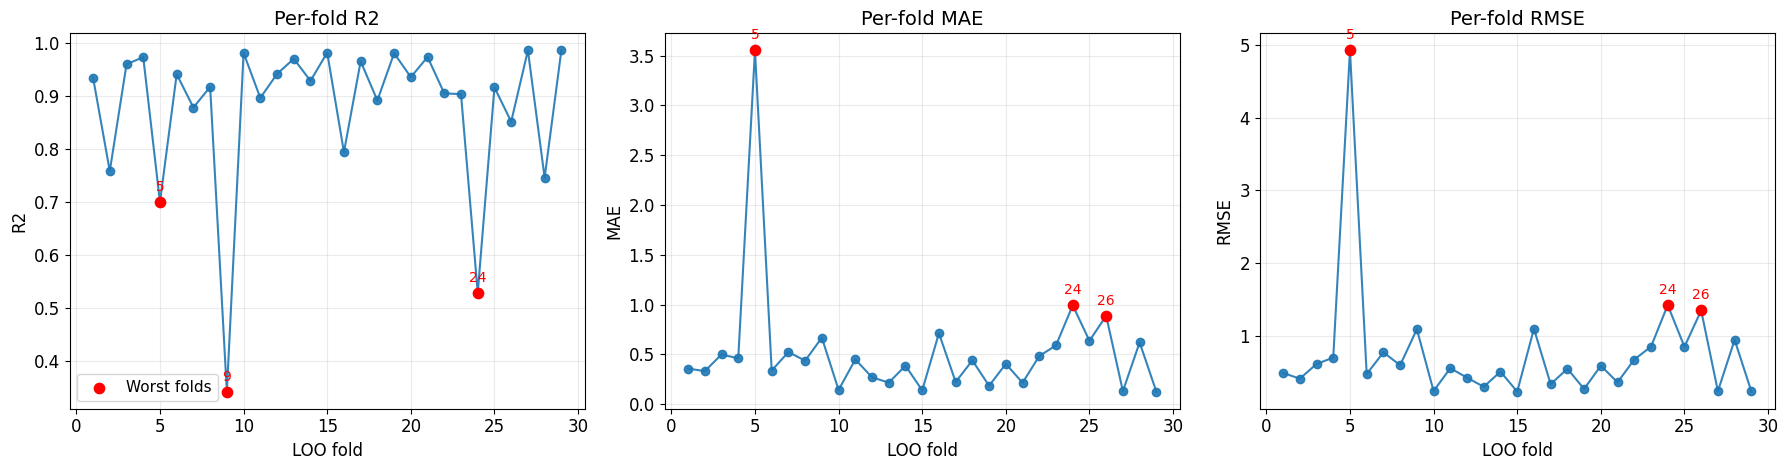


Compact HPO trials (top 10 by inner-CV loss) for selected/anchor aux weight


,trial,value,mean_val_loss,std_val_loss,aux_weight,drop_rate,learning_rate,weight_decay,state
0,24,0.242755,NaN,NaN,0.0,0.00,0.005035,1.923260e-06,TrialState.PRUNED
1,22,0.243091,NaN,NaN,0.0,0.30,0.006473,3.945229e-05,TrialState.PRUNED
2,21,0.243153,NaN,NaN,0.0,0.00,0.005737,4.363802e-05,TrialState.PRUNED
3,15,0.243426,NaN,NaN,0.0,0.30,0.005725,2.458051e-04,TrialState.PRUNED
4,34,0.243648,NaN,NaN,0.0,0.30,0.005741,1.582565e-05,TrialState.PRUNED
5,37,0.243748,NaN,NaN,0.0,0.05,0.006288,5.298843e-06,TrialState.PRUNED
6,33,0.267256,NaN,NaN,0.0,0.30,0.004411,1.357952e-05,TrialState.PRUNED
7,29,0.271500,NaN,NaN,0.0,0.05,0.002867,3.978977e-05,TrialState.PRUNED
8,11,0.271628,NaN,NaN,0.0,0.30,0.003133,1.065527e-08,TrialState.PRUNED
9,18,0.271829,NaN,NaN,0.0,0.10,0.003139,2.732316e-06,TrialState.PRUNED


Pruning/state counts:
state
TrialState.COMPLETE    22
TrialState.PRUNED      18
Name: count, dtype: int64

Context/cap diagnostics (true context magnitude vs c0 value handed to FluxTransformer/pFBA)
  cap supervision mode: latent
  glucose/O2 transformer context mode: measured
   R_EX_glc__D_e_rev (sign=-1) | true med/mean=2.990000/3.570345 | c0/cap med/mean=2.990000/3.570345
       R_EX_o2_e_rev (sign=-1) | true med/mean=7.170000/8.162414 | c0/cap med/mean=7.170000/8.162414
      R_EX_co2_e_fwd (sign=+1) | true med/mean=5.760000/5.546552 | c0/cap med/mean=19.125000/20.102606
         R_EX_etoh_e (sign=+1) | true med/mean=0.000000/0.012759 | c0/cap med/mean=6.232435/43.852810
           R_EX_ac_e (sign=+1) | true med/mean=0.000000/0.083793 | c0/cap med/mean=0.137192/0.197148


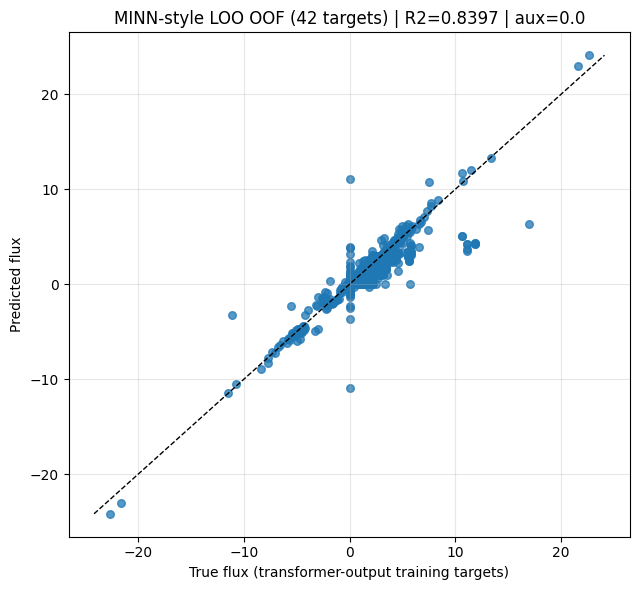

Running FluxTransformer-to-pFBA with glucose/O2 context mode='measured' and extra_constraint_mode='etoh_ac_cap'
pFBA glucose/O2 source: measured uptake columns
pFBA extra predicted constraints: ['R_EX_etoh_e', 'R_EX_ac_e']
FluxTransformer pFBA extra-constraint mode: etoh_ac_cap
Predicted pFBA extra constraints vs baseline pFBA solution:
  ethanol: 29/29 predicted values differ from baseline pFBA flux; max abs delta=147.25
  acetate: 26/29 predicted values differ from baseline pFBA flux; max abs delta=13.2105
Max abs prediction difference vs baseline pFBA: 13.2105
=== Cap-binding diagnostics summary ===


,result_key,context_mode,extra_constraint_mode,cap_rows,binding_rows,binding_low_cap_rows,binding_high_cap_rows,nonbinding_bad_final_rows,cap_helped_rows,cap_worsened_rows,mean_abs_cap_error,mean_abs_final_cap_error,mean_abs_baseline_cap_error
0,better_etoh_ac_cap,measured,etoh_ac_cap,58,21,2,9,6,18,0,22.055186,0.093666,0.771653


=== FluxTransformer to pFBA summary (measured, etoh_ac_cap) ===
Samples evaluated: 29/29


,avg,std
R2,0.830315,0.116005
MAE,0.567478,0.554028
RMSE,0.955034,0.771304
NE,0.316553,0.106938


,experiment,R_EX_etoh_e_pred,R_EX_ac_e_pred
0,REF,1.167600,1.456908e-01
1,WT_0.1h-1,0.981693,3.460095e-01
2,WT_0.4h-1,5.780436,3.950873e-01
3,WT_0.5h-1,128.500000,1.979208e-06
4,WT_0.7h-1,9.531322,1.439791e-01
5,galM,4.832220,3.344633e-01
6,glk,127.500000,1.020345e-09
7,pgm,134.000000,1.029282e-16
8,pgi,0.523521,6.521241e-01
9,pfkA,1.474710,9.909508e-02


=== Average metric comparison ===


,pFBA,"FluxTransformer to pFBA (measured, etoh_ac_cap)"
R2,0.758239 +/- 0.199449,0.830315 +/- 0.116005
MAE,0.672460 +/- 0.652862,0.567478 +/- 0.554028
RMSE,1.130943 +/- 1.012816,0.955034 +/- 0.771304
NE,0.374178 +/- 0.166116,0.316553 +/- 0.106938


In [30]:
# Retrain with the better glucose/O2 context mode, then evaluate etoh_ac_cap.
# CO2 remains a FluxTransformer context/input channel; only its downstream pFBA cap is omitted.

import inspect

CO2_ETOH_AC_MODE = "co2_etoh_ac_cap"
ETOH_AC_ONLY_MODE = "etoh_ac_cap"
CO2_SOURCE = "R_EX_co2_e_fwd"

reference_keys = {
    "measured": f"measured_{CO2_ETOH_AC_MODE}",
    "predicted": f"predicted_{CO2_ETOH_AC_MODE}",
}

if "MINN_CONTEXT_MODE_RESULTS" not in globals():
    raise RuntimeError("Run the measured and predicted reservoir evaluation cells before this cell.")

if "MINN_FLUXTRANSFORMER_PFBA_RESULTS" not in globals():
    MINN_FLUXTRANSFORMER_PFBA_RESULTS = {}

def _run_fluxtransformer_to_pfba_with_context_result(
    context_mode,
    *,
    extra_constraint_mode,
    result_key,
    context_result_key,
    make_canonical,
):
    """Compatibility wrapper for kernels with the older pFBA evaluator signature."""
    context_mode = str(context_mode).lower().strip()
    context_result_key = str(context_result_key).lower().strip()
    params = inspect.signature(run_fluxtransformer_to_pfba_context_mode).parameters
    if "context_result_key" in params:
        return run_fluxtransformer_to_pfba_context_mode(
            context_mode,
            extra_constraint_mode=extra_constraint_mode,
            result_key=result_key,
            context_result_key=context_result_key,
            make_canonical=make_canonical,
        )

    old_context_result = MINN_CONTEXT_MODE_RESULTS.get(context_mode)
    MINN_CONTEXT_MODE_RESULTS[context_mode] = MINN_CONTEXT_MODE_RESULTS[context_result_key]
    try:
        pfba_result = run_fluxtransformer_to_pfba_context_mode(
            context_mode,
            extra_constraint_mode=extra_constraint_mode,
            result_key=result_key,
            make_canonical=make_canonical,
        )
        pfba_result["context_result_key"] = context_result_key
        return pfba_result
    finally:
        if old_context_result is None:
            MINN_CONTEXT_MODE_RESULTS.pop(context_mode, None)
        else:
            MINN_CONTEXT_MODE_RESULTS[context_mode] = old_context_result

for mode, key in reference_keys.items():
    if key not in MINN_FLUXTRANSFORMER_PFBA_RESULTS:
        if mode not in MINN_CONTEXT_MODE_RESULTS:
            raise RuntimeError(f"Missing stored reservoir result for {mode!r}. Run that reservoir cell first.")
        _run_fluxtransformer_to_pfba_with_context_result(
            mode,
            extra_constraint_mode=CO2_ETOH_AC_MODE,
            result_key=key,
            context_result_key=mode,
            make_canonical=False,
        )

reference_rows = []
for mode, key in reference_keys.items():
    summary = MINN_FLUXTRANSFORMER_PFBA_RESULTS[key]["minn_pfba_summary_df"]
    reference_rows.append({
        "context_mode": mode,
        "result_key": key,
        "R2_avg": float(summary.loc["R2", "avg"]),
        "MAE_avg": float(summary.loc["MAE", "avg"]),
        "RMSE_avg": float(summary.loc["RMSE", "avg"]),
        "NE_avg": float(summary.loc["NE", "avg"]),
    })

MINN_CO2_CAP_CONTEXT_MODE_SELECTION_DF = pd.DataFrame(reference_rows).sort_values(
    ["R2_avg", "MAE_avg", "RMSE_avg", "NE_avg"],
    ascending=[False, True, True, True],
).reset_index(drop=True)

print("=== CO2/ethanol/acetate-cap context-mode selection ===")
display(MINN_CO2_CAP_CONTEXT_MODE_SELECTION_DF)

MINN_BETTER_GLC_O2_CONTEXT_MODE_FOR_ETOH_AC = str(MINN_CO2_CAP_CONTEXT_MODE_SELECTION_DF.iloc[0]["context_mode"])
MINN_ETOH_AC_CONTEXT_RESULT_KEY = f"{MINN_BETTER_GLC_O2_CONTEXT_MODE_FOR_ETOH_AC}_{ETOH_AC_ONLY_MODE}_training"
MINN_ETOH_AC_PFBA_RESULT_KEY = "better_etoh_ac_cap"

print("Best glucose/O2 context mode:", MINN_BETTER_GLC_O2_CONTEXT_MODE_FOR_ETOH_AC)
print("Retraining result key:", MINN_ETOH_AC_CONTEXT_RESULT_KEY)

_previous_pfba_extra_mode = MINN_PFBA_EXTRA_CONSTRAINT_MODE
_previous_pfba_extra_source = list(MINN_PFBA_EXTRA_CONSTRAINT_SOURCE)
_etoh_ac_cap_run_completed = False

try:
    MINN_PFBA_EXTRA_CONSTRAINT_MODE = ETOH_AC_ONLY_MODE
    MINN_PFBA_EXTRA_CONSTRAINT_SOURCE = list(MINN_PFBA_EXTRA_CONSTRAINTS_BY_MODE[MINN_PFBA_EXTRA_CONSTRAINT_MODE])

    # Keep the full 5-channel reservoir context. This mirrors simulated data:
    # CO2/ethanol/acetate are secretion-context inputs filled from solved pFBA fluxes.
    assert CO2_SOURCE in MINN_LEARNED_CONSTRAINT_SOURCE
    assert CO2_SOURCE in MINN_RESERVOIR_CONTEXT_SOURCE
    configure_minn_glc_o2_context_mode(MINN_BETTER_GLC_O2_CONTEXT_MODE_FOR_ETOH_AC)
    assert CO2_SOURCE in MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE
    assert CO2_SOURCE not in MINN_PFBA_EXTRA_CONSTRAINT_SOURCE

    print("EtOH/Ac-cap retraining configuration")
    print("  FluxTransformer glucose/O2 context mode:", MINN_GLC_O2_CONTEXT_MODE)
    print("  Reservoir context source order:", MINN_RESERVOIR_CONTEXT_SOURCE)
    print("  Context predicted by front MLP:", MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE)
    print("  Downstream pFBA cap sources:", MINN_PFBA_EXTRA_CONSTRAINT_SOURCE)
    print("  CO2 stays in FluxTransformer input:", CO2_SOURCE in MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE)
    print("  CO2 used as downstream pFBA cap:", CO2_SOURCE in MINN_PFBA_EXTRA_CONSTRAINT_SOURCE)

    minn_etoh_ac_context_result = run_minn_context_mode_experiment(
        MINN_BETTER_GLC_O2_CONTEXT_MODE_FOR_ETOH_AC,
        result_key=MINN_ETOH_AC_CONTEXT_RESULT_KEY,
        make_canonical=True,
    )

    minn_pfba_better_etoh_ac_result = _run_fluxtransformer_to_pfba_with_context_result(
        MINN_BETTER_GLC_O2_CONTEXT_MODE_FOR_ETOH_AC,
        extra_constraint_mode=ETOH_AC_ONLY_MODE,
        result_key=MINN_ETOH_AC_PFBA_RESULT_KEY,
        context_result_key=MINN_ETOH_AC_CONTEXT_RESULT_KEY,
        make_canonical=True,
    )
    _etoh_ac_cap_run_completed = True
finally:
    # Keep the selected etoh_ac run canonical if it completed; otherwise restore the old cap-mode globals.
    if not _etoh_ac_cap_run_completed:
        MINN_PFBA_EXTRA_CONSTRAINT_MODE = _previous_pfba_extra_mode
        MINN_PFBA_EXTRA_CONSTRAINT_SOURCE = _previous_pfba_extra_source


### FluxTransformer to pFBA: Final Cap-Mode Comparison

Compare baseline pFBA, both CO2/ethanol/acetate-cap FluxTransformer-to-pFBA variants, and the retrained best-context ethanol/acetate-cap variant.


In [31]:
required_final_pfba_keys = {
    "FluxTransformer to pFBA (measured co2_etoh_ac_cap)": "measured_co2_etoh_ac_cap",
    "FluxTransformer to pFBA (predicted co2_etoh_ac_cap)": "predicted_co2_etoh_ac_cap",
    "FluxTransformer to pFBA (better method, etoh_ac_cap)": "better_etoh_ac_cap",
}

if "pfba_baseline_summary_df" not in globals():
    raise RuntimeError("Run the baseline pFBA cell before the final comparison.")
if "MINN_FLUXTRANSFORMER_PFBA_RESULTS" not in globals():
    raise RuntimeError("Run the FluxTransformer-to-pFBA cells before the final comparison.")

missing_final = [key for key in required_final_pfba_keys.values() if key not in MINN_FLUXTRANSFORMER_PFBA_RESULTS]
if missing_final:
    raise RuntimeError(f"Missing final FluxTransformer-to-pFBA result(s): {missing_final}")

metric_order = ["R2", "MAE", "RMSE", "NE"]
final_average_cols = {
    "pFBA": [
        f"{float(pfba_baseline_summary_df.loc[m, 'avg']):.6f} +/- {float(pfba_baseline_summary_df.loc[m, 'std']):.6f}"
        for m in metric_order
    ],
}

for label, key in required_final_pfba_keys.items():
    summary = MINN_FLUXTRANSFORMER_PFBA_RESULTS[key]["minn_pfba_summary_df"]
    final_average_cols[label] = [
        f"{float(summary.loc[m, 'avg']):.6f} +/- {float(summary.loc[m, 'std']):.6f}"
        for m in metric_order
    ]

MINN_FINAL_PFBA_AVERAGE_COMPARISON_DF = pd.DataFrame(final_average_cols, index=metric_order)
print("=== Final average metric comparison ===")
display(MINN_FINAL_PFBA_AVERAGE_COMPARISON_DF)

final_rows = []
for label, key in required_final_pfba_keys.items():
    res = MINN_FLUXTRANSFORMER_PFBA_RESULTS[key]
    summary = res["minn_pfba_summary_df"]
    final_rows.append({
        "label": label,
        "result_key": key,
        "context_mode": res["context_mode"],
        "context_result_key": res.get("context_result_key", res["context_mode"]),
        "extra_constraint_mode": res["extra_constraint_mode"],
        "extra_constraints": ", ".join(res["extra_constraint_sources"]),
        "R2_avg": float(summary.loc["R2", "avg"]),
        "MAE_avg": float(summary.loc["MAE", "avg"]),
        "RMSE_avg": float(summary.loc["RMSE", "avg"]),
        "NE_avg": float(summary.loc["NE", "avg"]),
        "failed_samples": len(res["failed_samples_minn_pfba"]),
    })

MINN_FINAL_PFBA_RESULT_SUMMARY_DF = pd.DataFrame(final_rows).sort_values(
    ["R2_avg", "MAE_avg", "RMSE_avg", "NE_avg"],
    ascending=[False, True, True, True],
).reset_index(drop=True)
display(MINN_FINAL_PFBA_RESULT_SUMMARY_DF)


=== Final average metric comparison ===


,pFBA,FluxTransformer to pFBA (measured co2_etoh_ac_cap),FluxTransformer to pFBA (predicted co2_etoh_ac_cap),"FluxTransformer to pFBA (better method, etoh_ac_cap)"
R2,0.758239 +/- 0.199449,0.829120 +/- 0.116689,0.820169 +/- 0.127675,0.830315 +/- 0.116005
MAE,0.672460 +/- 0.652862,0.569896 +/- 0.551575,0.581289 +/- 0.548852,0.567478 +/- 0.554028
RMSE,1.130943 +/- 1.012816,0.956793 +/- 0.770025,0.974831 +/- 0.771906,0.955034 +/- 0.771304
NE,0.374178 +/- 0.166116,0.317502 +/- 0.107336,0.324841 +/- 0.116234,0.316553 +/- 0.106938


,label,result_key,context_mode,context_result_key,extra_constraint_mode,extra_constraints,R2_avg,MAE_avg,RMSE_avg,NE_avg,failed_samples
0,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,measured,measured_etoh_ac_cap_training,etoh_ac_cap,"R_EX_etoh_e, R_EX_ac_e",0.830315,0.567478,0.955034,0.316553,0
1,FluxTransformer to pFBA (measured co2_etoh_ac_...,measured_co2_etoh_ac_cap,measured,measured,co2_etoh_ac_cap,"R_EX_co2_e_fwd, R_EX_etoh_e, R_EX_ac_e",0.829120,0.569896,0.956793,0.317502,0
2,FluxTransformer to pFBA (predicted co2_etoh_ac...,predicted_co2_etoh_ac_cap,predicted,predicted,co2_etoh_ac_cap,"R_EX_co2_e_fwd, R_EX_etoh_e, R_EX_ac_e",0.820169,0.581289,0.974831,0.324841,0


### FluxTransformer to pFBA: Per-Sample Cap-Binding Diagnostics

Inspect whether poor samples are caused by reservoir cap predictions or by the downstream pFBA solve. A cap is marked as binding when the solved secretion flux reaches the predicted upper cap. `binding_low_cap` is the main overconstraint signal: the predicted cap is below the fitted target and pFBA is forced to that cap.

In [32]:
MINN_CAP_BINDING_TOP_N = 12
MINN_CAP_BINDING_WORSENED_TOP_N = 20

if "_build_pfba_cap_binding_diagnostics" not in globals():
    raise RuntimeError("Run the FluxTransformer-to-pFBA reusable evaluator cell before cap-binding diagnostics.")
if "MINN_FLUXTRANSFORMER_PFBA_RESULTS" not in globals():
    raise RuntimeError("Run the FluxTransformer-to-pFBA cells before cap-binding diagnostics.")

if "required_final_pfba_keys" not in globals():
    required_final_pfba_keys = {
        "FluxTransformer to pFBA (measured co2_etoh_ac_cap)": "measured_co2_etoh_ac_cap",
        "FluxTransformer to pFBA (predicted co2_etoh_ac_cap)": "predicted_co2_etoh_ac_cap",
        "FluxTransformer to pFBA (better method, etoh_ac_cap)": "better_etoh_ac_cap",
    }
missing_cap_binding_inputs = [
    key for key in required_final_pfba_keys.values()
    if key not in MINN_FLUXTRANSFORMER_PFBA_RESULTS
]
if missing_cap_binding_inputs:
    raise RuntimeError(f"Missing FluxTransformer-to-pFBA result(s): {missing_cap_binding_inputs}")

cap_binding_long_frames = []
cap_binding_sample_frames = []
cap_binding_result_frames = []

for label, key in required_final_pfba_keys.items():
    res = MINN_FLUXTRANSFORMER_PFBA_RESULTS[key]
    if (
        res.get("pfba_cap_binding_diagnostics_df") is None
        or res.get("pfba_cap_binding_sample_summary_df") is None
        or res.get("pfba_cap_binding_result_summary_df") is None
    ):
        cap_df, sample_df, result_df = _build_pfba_cap_binding_diagnostics(
            result_key=key,
            context_mode=res["context_mode"],
            extra_constraint_mode=res["extra_constraint_mode"],
            extra_sources=res["extra_constraint_sources"],
            pred_vin_df=res["pred_vin_df"],
            flux_df_eval=res["flux_df_eval"],
            minn_pfba_pred_df=res["minn_pfba_pred_df"],
            minn_pfba_metrics_per_sample_df=res["minn_pfba_metrics_per_sample_df"],
            baseline_pred_df=globals().get("pfba_baseline_pred_df"),
            tol=globals().get("PFBA_EXTRA_CONSTRAINT_TOL", 1e-6),
        )
        res["pfba_cap_binding_diagnostics_df"] = cap_df
        res["pfba_cap_binding_sample_summary_df"] = sample_df
        res["pfba_cap_binding_result_summary_df"] = result_df

    cap_df = res["pfba_cap_binding_diagnostics_df"].copy()
    sample_df = res["pfba_cap_binding_sample_summary_df"].copy()
    result_df = res["pfba_cap_binding_result_summary_df"].copy()
    cap_df.insert(0, "label", label)
    sample_df.insert(0, "label", label)
    result_df.insert(0, "label", label)
    cap_binding_long_frames.append(cap_df)
    cap_binding_sample_frames.append(sample_df)
    cap_binding_result_frames.append(result_df)

MINN_CAP_BINDING_DIAGNOSTICS_DF = pd.concat(cap_binding_long_frames, ignore_index=True)
MINN_CAP_BINDING_SAMPLE_SUMMARY_DF = pd.concat(cap_binding_sample_frames, ignore_index=True)
MINN_CAP_BINDING_RESULT_SUMMARY_DF = pd.concat(cap_binding_result_frames, ignore_index=True)

print("=== Cap-binding summary by FluxTransformer-to-pFBA result ===")
display_cols = [
    "label", "result_key", "context_mode", "extra_constraint_mode", "cap_rows",
    "binding_rows", "binding_low_cap_rows", "binding_high_cap_rows",
    "nonbinding_bad_final_rows", "cap_helped_rows", "cap_worsened_rows",
    "mean_abs_cap_error", "mean_abs_final_cap_error", "mean_abs_baseline_cap_error",
]
display(MINN_CAP_BINDING_RESULT_SUMMARY_DF[[c for c in display_cols if c in MINN_CAP_BINDING_RESULT_SUMMARY_DF.columns]])

print(f"=== Worst {MINN_CAP_BINDING_TOP_N} samples with cap-binding diagnostics ===")
sample_display_cols = [
    "label", "result_key", "experiment", "R2", "MAE", "RMSE", "NE",
    "n_caps", "cap_binding_count", "binding_low_cap_count", "binding_high_cap_count",
    "nonbinding_bad_final_count", "cap_helped_count", "cap_worsened_count",
    "max_abs_cap_error", "max_abs_final_cap_error", "mean_abs_cap_slack",
    "cap_binding_diagnosis",
]
MINN_CAP_BINDING_WORST_SAMPLE_DF = (
    MINN_CAP_BINDING_SAMPLE_SUMMARY_DF
    .sort_values(
        ["RMSE", "NE", "binding_low_cap_count", "max_abs_final_cap_error"],
        ascending=[False, False, False, False],
    )
    .head(MINN_CAP_BINDING_TOP_N)
    .reset_index(drop=True)
)
display(MINN_CAP_BINDING_WORST_SAMPLE_DF[[c for c in sample_display_cols if c in MINN_CAP_BINDING_WORST_SAMPLE_DF.columns]])

print("=== Cap-level rows for the worst samples above ===")
focus_pairs = MINN_CAP_BINDING_WORST_SAMPLE_DF[["result_key", "experiment"]].drop_duplicates()
MINN_CAP_BINDING_WORST_CAP_ROWS_DF = (
    MINN_CAP_BINDING_DIAGNOSTICS_DF
    .merge(focus_pairs, on=["result_key", "experiment"], how="inner")
    .sort_values(["result_key", "experiment", "abs_final_error"], ascending=[True, True, False])
    .reset_index(drop=True)
)
cap_display_cols = [
    "label", "result_key", "experiment", "source_label",
    "target_flux", "cap_pred", "pfba_flux", "baseline_flux",
    "cap_error", "final_error", "baseline_error", "cap_slack",
    "cap_binding", "binding_low_cap", "binding_high_cap",
    "cap_helped_vs_baseline", "cap_worsened_vs_baseline", "diagnosis",
]
display(MINN_CAP_BINDING_WORST_CAP_ROWS_DF[[c for c in cap_display_cols if c in MINN_CAP_BINDING_WORST_CAP_ROWS_DF.columns]])

print(f"=== Largest cap-induced degradations vs baseline pFBA (top {MINN_CAP_BINDING_WORSENED_TOP_N}) ===")
MINN_CAP_BINDING_WORSENED_CAPS_DF = (
    MINN_CAP_BINDING_DIAGNOSTICS_DF[MINN_CAP_BINDING_DIAGNOSTICS_DF["cap_worsened_vs_baseline"]]
    .sort_values("cap_worsening_abs_delta", ascending=False)
    .head(MINN_CAP_BINDING_WORSENED_TOP_N)
    .reset_index(drop=True)
)
display(MINN_CAP_BINDING_WORSENED_CAPS_DF[[c for c in cap_display_cols + ["cap_worsening_abs_delta"] if c in MINN_CAP_BINDING_WORSENED_CAPS_DF.columns]])


=== Cap-binding summary by FluxTransformer-to-pFBA result ===


,label,result_key,context_mode,extra_constraint_mode,cap_rows,binding_rows,binding_low_cap_rows,binding_high_cap_rows,nonbinding_bad_final_rows,cap_helped_rows,cap_worsened_rows,mean_abs_cap_error,mean_abs_final_cap_error,mean_abs_baseline_cap_error
0,FluxTransformer to pFBA (measured co2_etoh_ac_...,measured_co2_etoh_ac_cap,measured,co2_etoh_ac_cap,87,20,2,15,34,33,3,11.300779,0.867854,1.293856
1,FluxTransformer to pFBA (predicted co2_etoh_ac...,predicted_co2_etoh_ac_cap,predicted,co2_etoh_ac_cap,87,17,3,14,36,31,3,4.973126,0.911104,1.293856
2,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,measured,etoh_ac_cap,58,21,2,9,6,18,0,22.055186,0.093666,0.771653


=== Worst 12 samples with cap-binding diagnostics ===


,label,result_key,experiment,R2,MAE,RMSE,NE,n_caps,cap_binding_count,binding_low_cap_count,binding_high_cap_count,nonbinding_bad_final_count,cap_helped_count,cap_worsened_count,max_abs_cap_error,max_abs_final_cap_error,mean_abs_cap_slack,cap_binding_diagnosis
0,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,WT_0.7h-1,0.632564,3.324732,4.767464,0.477462,2,1,1,0,1,1,0,9.381322,1.786021e+00,4.765661,cap overconstraint possible
1,FluxTransformer to pFBA (measured co2_etoh_ac_...,measured_co2_etoh_ac_cap,WT_0.7h-1,0.632635,3.312753,4.762633,0.476978,3,1,1,0,2,1,1,34.795000,5.521307e+00,13.268323,cap overconstraint possible
2,FluxTransformer to pFBA (predicted co2_etoh_ac...,predicted_co2_etoh_ac_cap,WT_0.7h-1,0.632180,3.271556,4.752286,0.475942,3,1,1,0,2,1,1,41.013750,5.530865e+00,16.145338,cap overconstraint possible
3,FluxTransformer to pFBA (predicted co2_etoh_ac...,predicted_co2_etoh_ac_cap,tktA,0.769162,0.937849,1.545885,0.376689,3,1,0,1,1,2,0,8.359610,2.139177e+00,4.162124,bad cap-target error is nonbinding
4,FluxTransformer to pFBA (measured co2_etoh_ac_...,measured_co2_etoh_ac_cap,tktA,0.796363,0.896201,1.464155,0.356774,3,1,0,0,1,2,0,14.226875,2.127335e+00,5.834164,bad cap-target error is nonbinding
5,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,rpiA,0.482124,0.970510,1.460993,0.595728,2,1,0,0,0,1,0,54.593750,4.765040e-08,27.296875,reservoir cap prediction differs
6,FluxTransformer to pFBA (predicted co2_etoh_ac...,predicted_co2_etoh_ac_cap,rpiA,0.482796,0.968730,1.459243,0.595014,3,1,0,1,1,2,0,20.274375,2.980058e+00,8.907227,bad cap-target error is nonbinding
7,FluxTransformer to pFBA (measured co2_etoh_ac_...,measured_co2_etoh_ac_cap,rpiA,0.482196,0.967247,1.457551,0.594324,3,1,0,1,1,2,0,22.665000,2.979064e+00,11.206990,bad cap-target error is nonbinding
8,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,tktA,0.798881,0.878944,1.449693,0.353250,2,1,0,0,0,1,0,147.250000,4.679973e-24,73.625000,reservoir cap prediction differs
9,FluxTransformer to pFBA (measured co2_etoh_ac_...,measured_co2_etoh_ac_cap,galM,0.766412,0.524979,1.300765,0.402536,3,0,0,0,1,0,0,12.099375,2.274191e+00,6.036327,bad cap-target error is nonbinding


=== Cap-level rows for the worst samples above ===


,label,result_key,experiment,source_label,target_flux,cap_pred,pfba_flux,baseline_flux,cap_error,final_error,baseline_error,cap_slack,cap_binding,binding_low_cap,binding_high_cap,cap_helped_vs_baseline,cap_worsened_vs_baseline,diagnosis
0,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,WT_0.7h-1,acetate,1.93,1.439791e-01,1.439791e-01,13.354463,-1.786021e+00,-1.786021e+00,11.424463,0.000000,True,True,False,True,False,binding low cap: possible overconstraint
1,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,WT_0.7h-1,ethanol,0.15,9.531322e+00,0.000000e+00,0.000000,9.381322e+00,-1.500000e-01,-0.150000,9.531322,False,False,False,False,False,nonbinding: pFBA/objective or other constraints
2,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,galM,ethanol,0.00,4.832220e+00,0.000000e+00,0.000000,4.832220e+00,0.000000e+00,0.000000,4.832220,False,False,False,False,False,cap prediction off but nonbinding
3,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,galM,acetate,0.00,3.344633e-01,0.000000e+00,0.000000,3.344633e-01,0.000000e+00,0.000000,0.334463,False,False,False,False,False,cap prediction off but nonbinding
4,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,rpiA,acetate,0.00,4.765040e-08,4.765040e-08,4.418382,4.765040e-08,4.765040e-08,4.418382,0.000000,True,False,False,True,False,cap target matched
5,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,rpiA,ethanol,0.00,5.459375e+01,0.000000e+00,0.000000,5.459375e+01,0.000000e+00,0.000000,54.593750,False,False,False,False,False,cap prediction off but nonbinding
6,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,tktA,acetate,0.00,4.679973e-24,4.679973e-24,1.642378,4.679973e-24,4.679973e-24,1.642378,0.000000,True,False,False,True,False,cap target matched
7,"FluxTransformer to pFBA (better method, etoh_a...",better_etoh_ac_cap,tktA,ethanol,0.00,1.472500e+02,0.000000e+00,0.000000,1.472500e+02,0.000000e+00,0.000000,147.250000,False,False,False,False,False,cap prediction off but nonbinding
8,FluxTransformer to pFBA (measured co2_etoh_ac_...,measured_co2_etoh_ac_cap,WT_0.7h-1,CO2,10.83,4.562500e+01,1.635131e+01,11.750112,3.479500e+01,5.521307e+00,0.920112,29.273693,False,False,False,False,True,nonbinding: pFBA/objective or other constraints
9,FluxTransformer to pFBA (measured co2_etoh_ac_...,measured_co2_etoh_ac_cap,WT_0.7h-1,acetate,1.93,3.119509e-01,3.119509e-01,13.354463,-1.618049e+00,-1.618049e+00,11.424463,0.000000,True,True,False,True,False,binding low cap: possible overconstraint


=== Largest cap-induced degradations vs baseline pFBA (top 20) ===


,label,result_key,experiment,source_label,target_flux,cap_pred,pfba_flux,baseline_flux,cap_error,final_error,baseline_error,cap_slack,cap_binding,binding_low_cap,binding_high_cap,cap_helped_vs_baseline,cap_worsened_vs_baseline,diagnosis,cap_worsening_abs_delta
0,FluxTransformer to pFBA (predicted co2_etoh_ac...,predicted_co2_etoh_ac_cap,WT_0.7h-1,CO2,10.83,51.843750,16.360865,11.750112,41.013750,5.530865,0.920112,35.482885,False,False,False,False,True,nonbinding: pFBA/objective or other constraints,4.610753
1,FluxTransformer to pFBA (measured co2_etoh_ac_...,measured_co2_etoh_ac_cap,WT_0.7h-1,CO2,10.83,45.625000,16.351307,11.750112,34.795000,5.521307,0.920112,29.273693,False,False,False,False,True,nonbinding: pFBA/objective or other constraints,4.601195
2,FluxTransformer to pFBA (predicted co2_etoh_ac...,predicted_co2_etoh_ac_cap,pgi,CO2,5.04,14.703125,4.746209,4.788465,9.663125,-0.293791,-0.251535,9.956916,False,False,False,False,True,nonbinding: pFBA/objective or other constraints,0.042256
3,FluxTransformer to pFBA (measured co2_etoh_ac_...,measured_co2_etoh_ac_cap,glk,CO2,6.46,26.406250,5.824540,5.864624,19.946250,-0.635460,-0.595376,20.581710,False,False,False,False,True,nonbinding: pFBA/objective or other constraints,0.040083
4,FluxTransformer to pFBA (predicted co2_etoh_ac...,predicted_co2_etoh_ac_cap,glk,CO2,6.46,12.023443,5.824560,5.864624,5.563443,-0.635440,-0.595376,6.198883,False,False,False,False,True,nonbinding: pFBA/objective or other constraints,0.040063
5,FluxTransformer to pFBA (measured co2_etoh_ac_...,measured_co2_etoh_ac_cap,pgi,CO2,5.04,21.781250,4.752669,4.788465,16.741250,-0.287331,-0.251535,17.028581,False,False,False,False,True,nonbinding: pFBA/objective or other constraints,0.035796


### FluxTransformer to pFBA: Bad-Sample Cap Sensitivity Analysis

For the worst samples in the selected CO2/ethanol/acetate-cap run, rerun downstream pFBA with different predicted cap subsets. This isolates whether a bad sample is driven by CO2, ethanol, acetate, or by pFBA/objective behavior that remains even when caps are removed.


5 reservoir-context channels: context/cap stats and diagnostic comparison to observed magnitudes
Glucose/O2 transformer context mode: measured
Measured-copy context sources: ['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev']
MLP-predicted context sources: ['R_EX_etoh_e', 'R_EX_co2_e_fwd', 'R_EX_ac_e']
Cap supervision mode: latent


,source_flux,mapped_token,vocab_idx,context_source,c0_mean,c0_std,c0_min,c0_max,true_mean,true_min,true_max,prediction_r2,prediction_mae,prediction_rmse,diagnostic_note
0,R_EX_glc__D_e_rev,EX_glc__D_e_flux,180,measured copy,3.570345,2.091031,1.340000e+00,13.340000,3.570345,1.34,13.34,NaN,NaN,NaN,measured value copied into context; identity i...
1,R_EX_o2_e_rev,EX_o2_e_flux,1981,measured copy,8.162414,3.657626,2.200000e+00,15.530000,8.162414,2.20,15.53,NaN,NaN,NaN,measured value copied into context; identity i...
2,R_EX_co2_e_fwd,EX_co2_e_flux,45,MLP predicted,20.102606,8.578531,2.299107e+00,43.343750,5.546552,0.31,10.83,-6.587483e+01,14.745081,16.302677,MLP prediction vs observed context magnitude
3,R_EX_etoh_e,EX_etoh_e_flux,1525,MLP predicted,43.852810,53.680176,5.235212e-01,147.250000,0.012759,0.00,0.15,-3.173866e+06,43.840050,68.584358,MLP prediction vs observed context magnitude
4,R_EX_ac_e,EX_ac_e_flux,106,MLP predicted,0.197148,0.228609,4.679973e-24,0.778143,0.083793,0.00,1.93,-5.929719e-01,0.270322,0.454553,MLP prediction vs observed context magnitude


Note: prediction metrics are intentionally NaN for measured-copy channels (['R_EX_glc__D_e_rev', 'R_EX_o2_e_rev']); plotting R2=1 for those would only confirm that the measured value was copied.


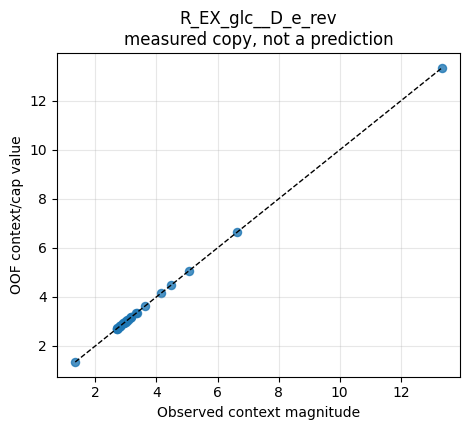

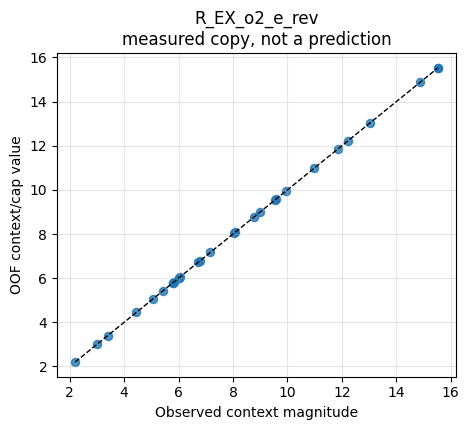

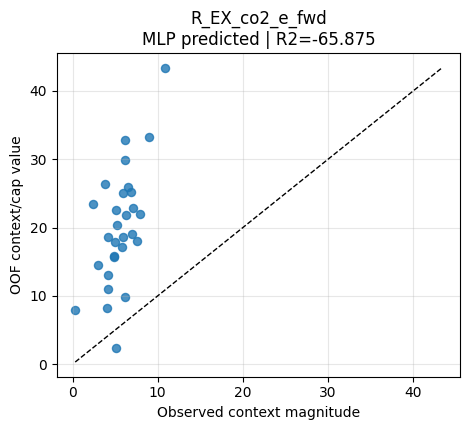

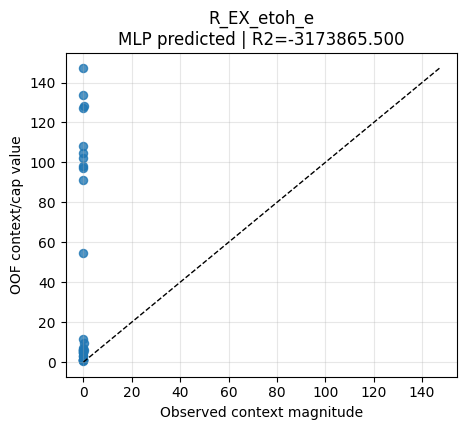

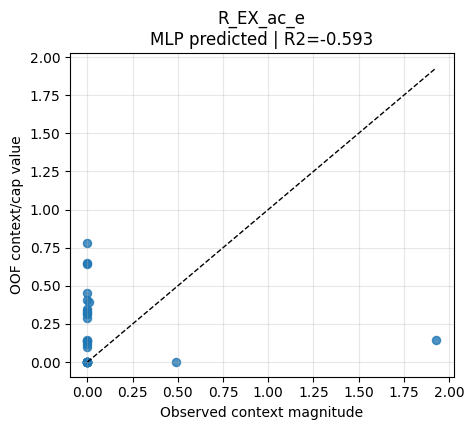

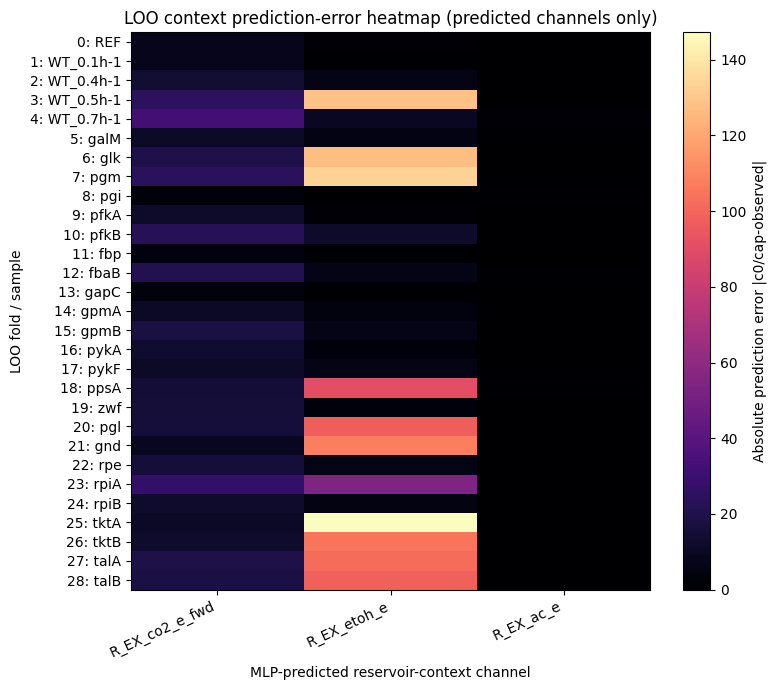

Top 5 folds by mean |predicted context-observed| across predicted context channels:
  1. fold=7 exp=pgm mean_abs_pred_diff=52.579792
  2. fold=25 exp=tktA mean_abs_pred_diff=52.559998
  3. fold=3 exp=WT_0.5h-1 mean_abs_pred_diff=51.025837
  4. fold=6 exp=glk mean_abs_pred_diff=49.008129
  5. fold=27 exp=talA mean_abs_pred_diff=40.514374


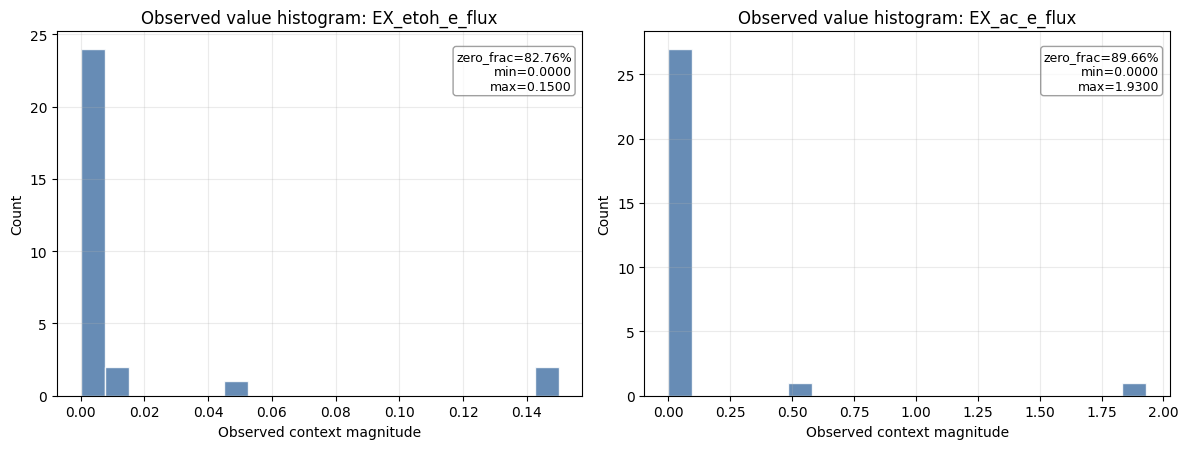

In [33]:
# Investigate the 5 reservoir-context channels in a dedicated cell
# - glucose/O2 are measured context by default (or predicted when MINN_GLC_O2_CONTEXT_MODE="predicted")
# - CO2/ethanol/acetate are latent context/cap values predicted by the front MLP
# - oof_pred_constraints stores the full 5-column context handed to FluxTransformer/pFBA
# - oof_true_constraints stores observed positive context magnitudes for diagnostics only
# Important: measured-copy channels are not predictions, so their identity R2 is not reported.

inspect_fluxes = list(minn_context_token_names)
inspect_sources = list(MINN_RESERVOIR_CONTEXT_SOURCE)

if len(inspect_fluxes) != 5:
    raise ValueError(f"Expected exactly 5 reservoir-context fluxes, got {len(inspect_fluxes)}: {inspect_fluxes}")
if len(inspect_sources) != len(inspect_fluxes):
    raise ValueError(
        f"Context source/token mismatch: {len(inspect_sources)} sources vs {len(inspect_fluxes)} tokens"
    )

# indices in vocabulary
token_to_idx = {tok: i for i, tok in enumerate(outputs)}
inspect_indices = [token_to_idx[f] for f in inspect_fluxes]

predicted_context_sources = set(globals().get("MINN_TRANSFORMER_PREDICTED_CONTEXT_SOURCE", []))
measured_context_sources = set(globals().get("MINN_TRANSFORMER_MEASURED_CONTEXT_SOURCE", []))
context_source_kind = [
    "MLP predicted" if src in predicted_context_sources else "measured copy"
    for src in inspect_sources
]
predicted_col_indices = [i for i, kind in enumerate(context_source_kind) if kind == "MLP predicted"]
copied_col_indices = [i for i, kind in enumerate(context_source_kind) if kind == "measured copy"]

if "oof_pred_constraints" in globals():
    pre_context = np.asarray(oof_pred_constraints, dtype=np.float32)
    context_value_label = "OOF context/cap value"
else:
    # Fallback sanity path using the setup model. This is not a trained OOF estimate.
    X_all_t = torch.tensor(X_minn_np, dtype=torch.float32, device=device)
    context_all_t = torch.tensor(y_minn_context_np, dtype=torch.float32, device=device)
    context_mag_all_t = torch.clamp(context_all_t * minn_context_signs_t.unsqueeze(0), min=0.0)
    measured_context_all = (
        context_mag_all_t.index_select(1, minn_measured_context_positions_t)
        if minn_measured_context_positions_t.numel() > 0
        else None
    )
    minn_model.eval()
    with torch.no_grad():
        c0_all = minn_model.build_full_input_vector(
            X_all_t,
            measured_context_values=measured_context_all,
        ).detach().cpu().numpy()
    pre_context = c0_all[:, inspect_indices]
    context_value_label = "setup-model context/cap value"

if pre_context.shape[1] != len(inspect_fluxes):
    raise ValueError(
        f"Expected {len(inspect_fluxes)} context columns, got {pre_context.shape[1]}"
    )

true_context = None
if "oof_true_constraints" in globals() and oof_true_constraints is not None:
    true_context = np.asarray(oof_true_constraints, dtype=np.float32)
elif "y_minn_context_np" in globals():
    true_context = np.maximum(0.0, y_minn_context_np * minn_context_signs.reshape(1, -1)).astype(np.float32)

if true_context is not None and true_context.shape != pre_context.shape:
    raise ValueError(
        f"Observed context shape {true_context.shape} does not match context value shape {pre_context.shape}"
    )

# summary
rows = []
for col, (flux, source, idx, kind) in enumerate(
    zip(inspect_fluxes, inspect_sources, inspect_indices, context_source_kind)
):
    cvals = pre_context[:, col]
    is_predicted_channel = kind == "MLP predicted"

    row = {
        "source_flux": source,
        "mapped_token": flux,
        "vocab_idx": idx,
        "context_source": kind,
        "c0_mean": float(np.mean(cvals)),
        "c0_std": float(np.std(cvals, ddof=1)) if len(cvals) > 1 else 0.0,
        "c0_min": float(np.min(cvals)),
        "c0_max": float(np.max(cvals)),
    }
    if true_context is not None:
        tvals = true_context[:, col]
        row.update({
            "true_mean": float(np.mean(tvals)),
            "true_min": float(np.min(tvals)),
            "true_max": float(np.max(tvals)),
            "prediction_r2": (
                float(r2_score(tvals, cvals))
                if is_predicted_channel and np.std(tvals) > 0 and np.std(cvals) > 0
                else np.nan
            ),
            "prediction_mae": (
                float(mean_absolute_error(tvals, cvals))
                if is_predicted_channel
                else np.nan
            ),
            "prediction_rmse": (
                float(root_mean_squared_error(tvals, cvals))
                if is_predicted_channel
                else np.nan
            ),
            "diagnostic_note": (
                "MLP prediction vs observed context magnitude"
                if is_predicted_channel
                else "measured value copied into context; identity is expected"
            ),
        })
    rows.append(row)

inspect_df = pd.DataFrame(rows)
print("5 reservoir-context channels: context/cap stats and diagnostic comparison to observed magnitudes")
print(f"Glucose/O2 transformer context mode: {MINN_GLC_O2_CONTEXT_MODE}")
print("Measured-copy context sources:", list(measured_context_sources))
print("MLP-predicted context sources:", list(predicted_context_sources))
print(f"Cap supervision mode: {MINN_CAP_SUPERVISION_MODE if 'MINN_CAP_SUPERVISION_MODE' in globals() else 'not_run'}")
display(inspect_df)

if copied_col_indices:
    copied_names = [inspect_sources[i] for i in copied_col_indices]
    print(
        "Note: prediction metrics are intentionally NaN for measured-copy channels "
        f"({copied_names}); plotting R2=1 for those would only confirm that the measured value was copied."
    )

# one scatter per context channel
if true_context is not None:
    for i, (flux, source, kind) in enumerate(zip(inspect_fluxes, inspect_sources, context_source_kind)):
        y_t = true_context[:, i]
        y_p = pre_context[:, i]

        is_predicted_channel = kind == "MLP predicted"
        r2_val = (
            r2_score(y_t, y_p)
            if is_predicted_channel and np.std(y_t) > 0 and np.std(y_p) > 0
            else np.nan
        )

        plt.figure(figsize=(4.8, 4.4))
        plt.scatter(y_t, y_p, alpha=0.8, s=34)
        lo = float(min(y_t.min(), y_p.min()))
        hi = float(max(y_t.max(), y_p.max()))
        plt.plot([lo, hi], [lo, hi], "k--", lw=1)
        plt.xlabel("Observed context magnitude")
        plt.ylabel(context_value_label)
        if is_predicted_channel:
            title_suffix = f"MLP predicted | R2={r2_val:.3f}"
        else:
            title_suffix = "measured copy, not a prediction"
        plt.title(f"{source}\n{title_suffix}")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    # fold x context absolute-difference heatmap for actually predicted context channels only
    if predicted_col_indices:
        predicted_abs_err = np.abs(pre_context[:, predicted_col_indices] - true_context[:, predicted_col_indices])
        predicted_fold_mean_err = predicted_abs_err.mean(axis=1)
        predicted_flux_labels = [inspect_sources[i] for i in predicted_col_indices]

        # Keep native LOO order by default. Optionally switch to worst-first order.
        sort_worst_first = False
        if sort_worst_first:
            row_order = np.argsort(-predicted_fold_mean_err)
        else:
            row_order = np.arange(predicted_abs_err.shape[0])

        abs_err_plot = predicted_abs_err[row_order]

        plt.figure(figsize=(8.0, 7.0))
        im = plt.imshow(abs_err_plot, aspect="auto", interpolation="nearest", cmap="magma")
        cbar = plt.colorbar(im)
        cbar.set_label("Absolute prediction error |c0/cap-observed|")

        plt.xticks(np.arange(len(predicted_flux_labels)), predicted_flux_labels, rotation=25, ha="right")

        # y-axis labels: fold index (+ experiment when available)
        if "minn_experiments" in globals() and len(minn_experiments) == predicted_abs_err.shape[0]:
            y_labels = [f"{int(i)}: {minn_experiments[i]}" for i in row_order]
        else:
            y_labels = [str(int(i)) for i in row_order]
        plt.yticks(np.arange(abs_err_plot.shape[0]), y_labels)

        plt.xlabel("MLP-predicted reservoir-context channel")
        plt.ylabel("LOO fold / sample")
        plt.title("LOO context prediction-error heatmap (predicted channels only)")
        plt.tight_layout()
        plt.show()

        # Print worst folds by mean absolute prediction error across predicted context channels
        k = min(5, predicted_abs_err.shape[0])
        worst = np.argsort(-predicted_fold_mean_err)[:k]
        print(f"Top {k} folds by mean |predicted context-observed| across predicted context channels:")
        for rank, i in enumerate(worst, start=1):
            exp_name = (
                minn_experiments[i]
                if "minn_experiments" in globals() and i < len(minn_experiments)
                else f"idx_{i}"
            )
            print(f"  {rank}. fold={int(i)} exp={exp_name} mean_abs_pred_diff={float(predicted_fold_mean_err[i]):.6f}")
    else:
        print("No MLP-predicted context channels are available for prediction-error heatmap.")

    # Histograms for ethanol and acetate observed context values
    etoh_idx = next((ii for ii, ff in enumerate(inspect_fluxes) if "etoh" in ff.lower()), None)
    ac_idx = next((ii for ii, ff in enumerate(inspect_fluxes) if "ac_e" in ff.lower() or "_ac_" in ff.lower()), None)

    hist_specs = []
    if etoh_idx is not None:
        hist_specs.append((etoh_idx, inspect_fluxes[etoh_idx]))
    if ac_idx is not None:
        hist_specs.append((ac_idx, inspect_fluxes[ac_idx]))

    if len(hist_specs) > 0:
        fig, axes = plt.subplots(1, len(hist_specs), figsize=(6.0 * len(hist_specs), 4.6), squeeze=False)
        axes = axes.ravel()

        for ax, (col_idx, flux_name) in zip(axes, hist_specs):
            vals = true_context[:, col_idx].astype(float)
            ax.hist(vals, bins=20, alpha=0.85, color="#4c78a8", edgecolor="white")
            ax.set_title(f"Observed value histogram: {flux_name}")
            ax.set_xlabel("Observed context magnitude")
            ax.set_ylabel("Count")
            ax.grid(alpha=0.25)

            zero_frac = float(np.mean(np.isclose(vals, 0.0)))
            ax.text(
                0.98,
                0.95,
                f"zero_frac={zero_frac:.2%}\nmin={vals.min():.4f}\nmax={vals.max():.4f}",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.75, edgecolor="gray"),
            )

        plt.tight_layout()
        plt.show()
    else:
        print("Could not find etoh/ac context columns in inspect_fluxes.")
else:
    print("Run the nested CV training cell first to generate OOF context diagnostics.")
